# Tiền xử lý dữ liệu bất động sản cho bài toán phân loại phân khúc giá

Notebook này làm sạch dữ liệu, điền khuyết, mã hoá đặc trưng và huấn luyện mô hình **phân loại phân khúc giá**. 
Biến mục tiêu được chuyển thành bốn lớp giá dựa trên các tứ phân vị học từ tập huấn luyện.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import warnings
from pathlib import Path
from scipy.stats import chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# ── Hằng số cấu hình ──────────────────────────────────────────────────────────
PLOT_DPI = 120          # Thay đổi 1 chỗ này để đồng bộ toàn notebook
plt.rcParams.update({'figure.dpi': PLOT_DPI, 'savefig.dpi': PLOT_DPI})
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')


def comprehensive_eda(file_path, target_col=None):
    """
    Hàm phân tích khám phá dữ liệu (EDA) chi tiết.
    - file_path: Đường dẫn tới file CSV.
    - target_col (tùy chọn): Tên cột mục tiêu để phân tích mất cân bằng lớp.
    """
    print(f' BÁO CÁO CHẨN ĐOÁN DỮ LIỆU ')
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Lỗi khi đọc file: {e}")
        return None

    print(f"[1] TỔNG QUAN KÍCH THƯỚC: {df.shape[0]} dòng x {df.shape[1]} cột")
    dup = df.duplicated().sum()
    print(f"[!] Dữ liệu trùng lặp hoàn toàn: {dup} dòng ({dup/len(df)*100:.2f}%)\n")

    print("[2] TÌNH TRẠNG KHUYẾT THIẾU (MISSING VALUES):")
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if not miss.empty:
        print(pd.DataFrame({'Số lượng thiếu': miss,
                            'Tỷ lệ (%)': (miss / len(df) * 100).round(2)}))
    else:
        print("-> Tuyệt vời! Bộ dữ liệu không có giá trị khuyết thiếu nào.\n")

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    if num_cols:
        print("\n[3] THỐNG KÊ BIẾN ĐỊNH LƯỢNG (NUMERICAL) & PHÁT HIỆN OUTLIER:")
        s = df[num_cols].describe().T
        s['skewness'] = df[num_cols].skew()
        s['kurtosis'] = df[num_cols].kurtosis()
        print(s[['mean', 'std', 'min', '50%', 'max', 'skewness']].round(3))
        print("  *Skewness > 1 hoặc < -1: phân phối lệch / có outlier lớn.")

    if cat_cols:
        print("\n[4] THỐNG KÊ BIẾN PHÂN LOẠI (CATEGORICAL):")
        cat_s = pd.DataFrame({
            'Số giá trị Unique': df[cat_cols].nunique(),
            'Top value': df[cat_cols].mode().iloc[0],
            'Tỷ lệ Top (%)': [round(df[c].value_counts(normalize=True).max() * 100, 2)
                              for c in cat_cols]
        })
        print(cat_s)
        print("  *Tỷ lệ Top > 95%: cột gần như chỉ chứa 1 giá trị → có thể gây nhiễu.")

    return df


print("✅ Đã nạp toàn bộ thư viện và định nghĩa hàm comprehensive_eda.")


✅ Đã nạp toàn bộ thư viện và định nghĩa hàm comprehensive_eda.


In [ ]:
from pathlib import Path

# ── Tự động tính project root từ vị trí notebook ──
_PROJECT_ROOT = Path.cwd().parent.parent
_RAW_DIR      = _PROJECT_ROOT / "data" / "Raw"

# Gán None để dùng auto-detect, hoặc gán path cụ thể nếu cần override
DATA_PATH = None

candidate_paths = [
    _RAW_DIR / "data_bds _NaNFill.csv",               # ← dynamic (máy nào cũng chạy)
    Path(r"C:\Users\LENOVO\OneDrive\Máy tính\Tiền xử lý\Đồ án\Final_Merged_2605.csv"),
    Path("/content/data_bds _1805_4700.csv"),          # Google Colab
    Path("/kaggle/working/data_bds _1805_4700.csv"),   # Kaggle working
    Path("/mnt/data/data_bds _1805_4700.csv"),         # ChatGPT/Python sandbox
    Path(r"C:\Users\ADMIN\OneDrive\Desktop\PreProcessing_DS108\Data\Raw_data\data_bds _1805_4700.csv"),
]

if DATA_PATH:
    data_path = Path(DATA_PATH)
else:
    data_path = next((p for p in candidate_paths if p.exists()), None)
    if data_path is None:
        search_roots = [Path.cwd(), Path("/content"), Path("/kaggle/input"), Path("/mnt/data")]
        matches = []
        for root in search_roots:
            if root.exists():
                matches.extend(root.rglob("data_bds*.csv"))
        data_path = matches[0] if matches else None

if data_path is None or not data_path.exists():
    raise FileNotFoundError(
        "Không tìm thấy file CSV. Hãy upload file 'data_bds _1805_4700.csv' "
        "vào cùng thư mục notebook hoặc gán DATA_PATH ở cell này."
    )

print(f"✅ Đang đọc dữ liệu từ: {data_path}")
df = comprehensive_eda(str(data_path))
if df is None:
    raise RuntimeError("Không thể tải dữ liệu CSV.")

✅ Đang đọc dữ liệu từ: c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Raw\data_bds _NaNFill.csv
 BÁO CÁO CHẨN ĐOÁN DỮ LIỆU 
[1] TỔNG QUAN KÍCH THƯỚC: 4719 dòng x 15 cột
[!] Dữ liệu trùng lặp hoàn toàn: 1082 dòng (22.93%)

[2] TÌNH TRẠNG KHUYẾT THIẾU (MISSING VALUES):
                       Số lượng thiếu  Tỷ lệ (%)
Hướng ban công                   4040      85.61
Hướng nhà                        3649      77.33
Nội thất                         2034      43.10
Đường vào                        1893      40.11
Số phòng tắm, vệ sinh            1254      26.57
Số phòng ngủ                     1101      23.33
Số tầng                           762      16.15
Pháp lý                           300       6.36
Địa chỉ                           183       3.88
Khoảng giá                        183       3.88
Diện tích                         183       3.88
Latitude                          183       3.88
Longitude                         183       3.88
Mô tả                             183       3.88



## Xử lý định dạng, thống nhất về các kiểu giá trị (trong các thuộc tính categorical) và đơn vị

Tỉ lệ missing của thuộc tính 'Hướng ban công' và 'Hướng nhà' quá cáo. Xoá bỏ 2 thuộc tính này.

### Xử lý miền giá trị của các thuộc tính categorical

Chuyển tất cả kiểu chữ thành Unicode để các bước xử lý sau dễ dàng trong xử lý chuỗi.

In [ ]:
# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền tất cả các cột dạng chữ (Text/Categorical) bạn muốn chuẩn hóa Unicode
columns_to_normalize = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất', 'Quan_Huyen', 'Phuong_Xa'] 
# ========================================================

print(f"{'='*10} CHUẨN HÓA UNICODE & KHÔNG GIAN DỮ LIỆU {'='*10}\n")
print(f"Đang tiến hành làm sạch {len(columns_to_normalize)} cột...")

for col in columns_to_normalize:
    if col in df.columns:
        # 1. Ép kiểu về dạng chuỗi (Object/String), nhưng giữ nguyên các giá trị NaN thực sự
        # Sử dụng .notnull() để tránh việc biến giá trị khuyết thiếu thành chữ 'nan'
        mask = df[col].notnull()
        
        # 2. Áp dụng chuẩn hóa Unicode NFC và cắt khoảng trắng thừa hai đầu (Strip)
        df.loc[mask, col] = df.loc[mask, col].astype(str).apply(
            lambda x: unicodedata.normalize('NFC', x).strip()
        )
        
        # 3. Tiện tay xử lý luôn lỗi: nếu dòng nào sau khi strip() chỉ còn là chuỗi rỗng '' 
        # thì chuyển nó về NaN chuẩn để dễ quản lý khuyết thiếu
        df[col] = df[col].replace('', np.nan)
        
        print(f" ✅ Đã dọn dẹp xong cột: [{col}]")
    else:
        print(f" ❌ Bỏ qua: Không tìm thấy cột '{col}' trong DataFrame.")

print("\n🎉 HOÀN THÀNH! Tất cả các cột cấu hình đã về cùng một chuẩn mã hóa.")

========== CHUẨN HÓA UNICODE & KHÔNG GIAN DỮ LIỆU ==========

Đang tiến hành làm sạch 6 cột...
 ✅ Đã dọn dẹp xong cột: [Hướng nhà]
 ✅ Đã dọn dẹp xong cột: [Hướng ban công]
 ✅ Đã dọn dẹp xong cột: [Pháp lý]
 ✅ Đã dọn dẹp xong cột: [Nội thất]
 ❌ Bỏ qua: Không tìm thấy cột 'Quan_Huyen' trong DataFrame.
 ❌ Bỏ qua: Không tìm thấy cột 'Phuong_Xa' trong DataFrame.

🎉 HOÀN THÀNH! Tất cả các cột cấu hình đã về cùng một chuẩn mã hóa.


Xoá dấu chấm cuối câu cho các cột để dễ so sánh cuối ở các bước xử lý sau.

In [ ]:
# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền các cột chữ bạn muốn xóa dấu chấm ở cuối câu
columns_to_remove_dot = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất', 'Quan_Huyen', 'Phuong_Xa'] 
# ========================================================

print(f"{'='*10} XÓA DẤU CHẤM CUỐI CÂU ĐỒNG LOẠT {'='*10}\n")

for col in columns_to_remove_dot:
    if col in df.columns:
        # Tạo bộ lọc tránh các ô bị khuyết (NaN)
        mask = df[col].notnull()
        
        # .str.rstrip('.') sẽ chỉ xóa dấu chấm nếu nó nằm ở cuối chuỗi
        # Sau khi xóa dấu chấm, ta tiện tay .str.strip() một lần nữa để phòng hờ khoảng trắng thừa
        df.loc[mask, col] = df.loc[mask, col].astype(str).str.rstrip('.').str.strip()
        
        print(f" ✅ Đã xóa dấu chấm cuối câu cho cột: [{col}]")
    else:
        print(f" ❌ Bỏ qua: Không tìm thấy cột '{col}'")

print("\n🎉 HOÀN THÀNH! Thử thống kê lại, bạn sẽ thấy các nhóm tự động gom về với nhau.")

========== XÓA DẤU CHẤM CUỐI CÂU ĐỒNG LOẠT ==========

 ✅ Đã xóa dấu chấm cuối câu cho cột: [Hướng nhà]
 ✅ Đã xóa dấu chấm cuối câu cho cột: [Hướng ban công]
 ✅ Đã xóa dấu chấm cuối câu cho cột: [Pháp lý]
 ✅ Đã xóa dấu chấm cuối câu cho cột: [Nội thất]
 ❌ Bỏ qua: Không tìm thấy cột 'Quan_Huyen'
 ❌ Bỏ qua: Không tìm thấy cột 'Phuong_Xa'

🎉 HOÀN THÀNH! Thử thống kê lại, bạn sẽ thấy các nhóm tự động gom về với nhau.


Chuyển các giá trị trong các cột xác định thành chữ viết thường.

In [ ]:
# 1. Khai báo danh sách các cột bạn muốn chuyển thành chữ thường
# (Bạn có thể thêm các cột khác như 'Loại hình', 'Quận/Huyện' vào list này)
cols_to_lower = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất'] 

# 2. Vòng lặp xử lý từng cột
for col in cols_to_lower:
    if col in df.columns:
        # Chuyển toàn bộ text sang chữ thường, NaN tự động được giữ nguyên
        df[col] = df[col].str.lower()

print(f"✅ Đã chuyển đổi chữ thường thành công cho các cột: {cols_to_lower}")

✅ Đã chuyển đổi chữ thường thành công cho các cột: ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất']


Thống kê miền giá trị trên các thuộc tính categotical

In [ ]:
# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền tên các cột bạn muốn kiểm tra vào danh sách dưới đây
columns_to_check = ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất', 'Quan_Huyen', 'Phuong_Xa'] 
# ========================================================

print(f"{'='*15} THỐNG KÊ GIÁ TRỊ ĐỂ CHUẨN HÓA {'='*15}\n")

for col in columns_to_check:
    if col in df.columns:
        print(f"🔷 CỘT: [{col}]")
        print(f"-> Tổng số lượng giá trị khác nhau: {df[col].nunique(dropna=False)}")
        print("-" * 40)
        
        # value_counts(dropna=False) sẽ in ra từng giá trị kèm số lần xuất hiện, tính cả giá trị trống (NaN)
        stats = df[col].value_counts(dropna=False)
        
        # In kết quả định dạng bảng đẹp mắt
        for value, count in stats.items():
            # Sử dụng repr() để hiển thị rõ nếu giá trị có khoảng trắng thừa ở đầu/cuối (ví dụ: ' Hà Nội ')
            print(f"   • {repr(value):<30} xuất hiện {count:>5} lần")
        print("\n" + "="*50 + "\n")
    else:
        print(f"❌ Cảnh báo: Không tìm thấy cột '{col}' trong dữ liệu hiện tại.\n")

=============== THỐNG KÊ GIÁ TRỊ ĐỂ CHUẨN HÓA ===============

🔷 CỘT: [Hướng nhà]
-> Tổng số lượng giá trị khác nhau: 9
----------------------------------------
   • nan                            xuất hiện  3649 lần
   • 'đông - nam'                   xuất hiện   317 lần
   • 'nam'                          xuất hiện   183 lần
   • 'đông - bắc'                   xuất hiện   163 lần
   • 'tây - nam'                    xuất hiện    96 lần
   • 'đông'                         xuất hiện    81 lần
   • 'tây'                          xuất hiện    79 lần
   • 'tây - bắc'                    xuất hiện    76 lần
   • 'bắc'                          xuất hiện    75 lần


🔷 CỘT: [Hướng ban công]
-> Tổng số lượng giá trị khác nhau: 9
----------------------------------------
   • nan                            xuất hiện  4040 lần
   • 'đông - nam'                   xuất hiện   156 lần
   • 'đông'                         xuất hiện   148 lần
   • 'đông - bắc'                   xuất hiện   134 lần
   • '

1. Xử lý cột ['Pháp lý']

 - Từ ngày 10/12/2009 cho đến nay, Nhà nước đã gộp hai loại sổ trên lại thành một mẫu giấy chung duy nhất do Bộ Tài nguyên và Môi trường phát hành.
 - Cột Pháp lý cần thống nhất miền giá trị: ['Sổ đỏ', 'Sổ hồng']

In [ ]:
print(f"{'='*15} BẮT ĐẦU MAP LUẬT MỚI (GIỮ 3 NHÓM) {'='*15}\n")

def map_phap_ly_3_classes(val):
    if pd.isna(val):
        return np.nan
    
    text = str(val).strip() # Chỉ strip khoảng trắng, không lower nữa
    
    # 1. CHƯA/KHÔNG CÓ SỔ -> Bắt buộc ra NaN
    tai_san_chua_so = ['chờ sổ', 'hợp đồng', 'hdmb', 'hđmb']
    if any(k in text for k in tai_san_chua_so):
        return np.nan
        
    # 2. CÓ SỔ HỒNG -> Vào Sổ hồng
    hong_keys = ['hồng', 'hong', 'shr']
    if any(k in text for k in hong_keys):
        return 'Sổ hồng'
        
    # 3. ĐIỀU CHỈNH: Cứ có chữ "sổ", "đỏ", hoặc "sdc" (Sổ chung) thì vào Sổ đỏ
    # (Hốt sạch đám 'có sổ', 'sổ riêng', 'sổ sẵn', 'sổ vuông đẹp'...)
    if 'sổ' in text or 'đỏ' in text or 'sdc' in text or text == 'sh':
        return 'Sổ đỏ'
        
    return np.nan

# Áp dụng hàm map
df['Pháp lý'] = df['Pháp lý'].apply(map_phap_ly_3_classes)

print("✅ Đã cập nhật luật map mới thành công!\n")

# Thống kê đối chiếu
stats_after = df['Pháp lý'].value_counts(dropna=False)
for value, count in stats_after.items():
    print(f"   • {repr(value):<20} xuất hiện {count:>5} lần")

=============== BẮT ĐẦU MAP LUẬT MỚI (GIỮ 3 NHÓM) ===============

✅ Đã cập nhật luật map mới thành công!

   • 'Sổ hồng'            xuất hiện  4031 lần
   • nan                  xuất hiện   414 lần
   • 'Sổ đỏ'              xuất hiện   274 lần


2. Xử lý cột [Nội thất]

- Chuyển các giá trị về ['Đầy đủ', 'Cơ bản', 'Không nội thất]
- Quét nhóm 'Cao cấp' trước nhóm 'Đầy đủ'. Vì nếu quét chữ "đầy đủ" hay "full" trước, giá trị như "full nội thất cao cấp" sẽ bị rơi nhầm vào nhóm 'Đầy đủ' và làm mất đi thuộc tính xa xỉ ('Cao cấp') của bất động sản.

In [ ]:
print(f"{'='*15} BẮT ĐẦU CHUẨN HÓA CỘT [Nội thất] {'='*15}\n")

def map_noi_that(val):
    if pd.isna(val):
        return np.nan
    
    # Gọt khoảng trắng (Không dùng .lower() vì đã xử lý ở cell trước)
    text = str(val).strip()
    
    # 0. Xử lý dữ liệu rác lỗi hệ thống (ví dụ lọt chữ 'tỷ', 'triệu' của cột giá)
    if 'tỷ' in text or 'triệu' in text:
        return np.nan
        
    # 1. Nhóm TRỐNG / NHÀ THÔ
    tho_keys = ['thô', 'trống', 'không nội thất', 'không nt', 'nhà trống']
    if any(k in text for k in tho_keys):
        return 'Trống / Nhà thô'
        
    # 2. Nhóm CAO CẤP (Phải check trước nhóm Đầy đủ)
    cao_cap_keys = ['cao cấp', 'luxury', 'vip', 'xịn', 'sang']
    if any(k in text for k in cao_cap_keys):
        return 'Cao cấp'
        
    # 3. Nhóm ĐẦY ĐỦ
    full_keys = ['đầy đủ', 'full', 'đủ nội thất', 'đủ nt', 'ful', 'tặng toàn bộ', 'để lại nội thất']
    if any(k in text for k in full_keys):
        return 'Đầy đủ'
        
    # 4. Nhóm CƠ BẢN
    if 'cơ bản' in text:
        return 'Cơ bản'
        
    # Tất cả các trường hợp văn bản mô tả quá dài dòng hoặc mơ hồ (ví dụ: 'khách sạn', 'nội thất')
    return np.nan

# Áp dụng bộ lọc vào DataFrame
df['Nội thất'] = df['Nội thất'].apply(map_noi_that)

print("✅ Đã gom nhóm thành công về 4 miền giá trị sạch!\n")

# Thống kê kết quả sau khi làm sạch
print(f"{'-'*15} KẾT QUẢ SAU KHI CHUẨN HÓA {'-'*15}")
print(f"-> Tổng số lượng giá trị khác nhau: {df['Nội thất'].nunique(dropna=False)}")
print("-" * 40)

stats_after = df['Nội thất'].value_counts(dropna=False)
for value, count in stats_after.items():
    print(f"   • {repr(value):<20} xuất hiện {count:>5} lần")

=============== BẮT ĐẦU CHUẨN HÓA CỘT [Nội thất] ===============

✅ Đã gom nhóm thành công về 4 miền giá trị sạch!

--------------- KẾT QUẢ SAU KHI CHUẨN HÓA ---------------
-> Tổng số lượng giá trị khác nhau: 5
----------------------------------------
   • nan                  xuất hiện  2052 lần
   • 'Đầy đủ'             xuất hiện  1555 lần
   • 'Cơ bản'             xuất hiện   750 lần
   • 'Trống / Nhà thô'    xuất hiện   221 lần
   • 'Cao cấp'            xuất hiện   141 lần


### Xử lý đơn vị đo cho các thuộc tính số học.

Thống kê các đơn vị trong các cột.

In [ ]:
# ==================== CẤU HÌNH Ở ĐÂY ====================
# Điền các cột chứa số bị dính đơn vị chữ của bạn
columns_with_units = ['Khoảng giá', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào'] 
# ========================================================

print(f"{'='*15} THỐNG KÊ ĐƠN VỊ THUỘC TÍNH SỐ (ĐÃ SỬA LỖI) {'='*15}\n")

for col in columns_with_units:
    if col in df.columns:
        print(f"🔷 CỘT: [{col}]")
        all_units = []
        
        # Lọc bỏ NaN, chuyển về chuỗi và gọt khoảng trắng
        valid_series = df[col].dropna().astype(str).str.strip()
        
        for value in valid_series:
            # REGEX MỚI: 
            # ^\s*[\d.,]+ -> Tìm và khớp toàn bộ cụm số đứng ở đầu dòng (chấp nhận cả dấu chấm, dấu phẩy thập phân)
            # \s* -> Bỏ qua khoảng trắng ở giữa số và đơn vị
            # (.*)$       -> Chỉ capture (bóc tách) phần ký tự còn lại ở phía sau cùng
            match = re.search(r'^\s*[\d.,]+\s*(.*)$', value)
            
            if match:
                unit = match.group(1).strip()
                # Nếu phần đuôi trống rỗng, chứng tỏ đây là số thuần túy
                if unit == '':
                    all_units.append("[Số thuần - Không đơn vị]")
                else:
                    all_units.append(unit)
            else:
                # Trường hợp ô dữ liệu không bắt đầu bằng số (ví dụ: "Thỏa thuận", "Chưa rõ")
                all_units.append(f"[Dữ liệu chữ/Ký tự lạ: {value}]")
                    
        # Thống kê tần suất
        unit_series = pd.Series(all_units)
        unit_counts = unit_series.value_counts()
        
        print(f"-> Phát hiện {len(unit_counts)} kiểu đơn vị thực tế:")
        for unit_name, count in unit_counts.items():
            print(f"   • {repr(unit_name):<25} xuất hiện {count:>5} lần")
        print("\n" + "="*50 + "\n")
    else:
        print(f"❌ Không tìm thấy cột '{col}' trong DataFrame.\n")

=============== THỐNG KÊ ĐƠN VỊ THUỘC TÍNH SỐ (ĐÃ SỬA LỖI) ===============

🔷 CỘT: [Khoảng giá]
-> Phát hiện 3 kiểu đơn vị thực tế:
   • 'tỷ'                      xuất hiện  4526 lần
   • 'triệu/m²'                xuất hiện     9 lần
   • '[Dữ liệu chữ/Ký tự lạ: Thỏa thuận]' xuất hiện     1 lần


🔷 CỘT: [Diện tích]
-> Phát hiện 1 kiểu đơn vị thực tế:
   • 'm²'                      xuất hiện  4536 lần


🔷 CỘT: [Số phòng ngủ]
-> Phát hiện 1 kiểu đơn vị thực tế:
   • 'phòng'                   xuất hiện  3618 lần


🔷 CỘT: [Số phòng tắm, vệ sinh]
-> Phát hiện 1 kiểu đơn vị thực tế:
   • 'phòng'                   xuất hiện  3465 lần


🔷 CỘT: [Số tầng]
-> Phát hiện 1 kiểu đơn vị thực tế:
   • 'tầng'                    xuất hiện  3957 lần


🔷 CỘT: [Đường vào]
-> Phát hiện 1 kiểu đơn vị thực tế:
   • 'm'                       xuất hiện  2826 lần




1. Xử lý cột 'Khoảng giá'

Khoảng_giá(tỷ) = [Khoảng_giá(triệu/m²) * Diện_tích(m²)] / 1000
Dữ liệu chữ/Ký tự lạ hiếm khi xuât hiện: Đổi thành nan

In [ ]:
print(f"{'='*15} BẮT ĐẦU CHUẨN HÓA CỘT [Khoảng giá] VỀ ĐƠN VỊ TỶ {'='*15}\n")

def convert_price_to_billion(row):
    price_val = str(row['Khoảng giá']).strip()
    
    # Kiểm tra NaN
    if pd.isna(row['Khoảng giá']) or price_val in ['nan', '', 'thỏa thuận']:
        return np.nan
        
    # Hàm phụ để trích xuất số và xử lý dấu phẩy thập phân (ví dụ: 50,5 -> 50.5)
    def extract_float(text):
        # Tìm cụm số chứa dấu chấm hoặc dấu phẩy
        match = re.search(r'[\d.,]+', text)
        if match:
            num_str = match.group(0)
            # Nếu có cả dấu chấm và dấu phẩy (như 1,234.5 hoặc 1.234,5)
            if ',' in num_str and '.' in num_str:
                # Giả định dấu phẩy là phân cách phần nghìn nếu nó đứng trước
                if num_str.find(',') < num_str.find('.'):
                    num_str = num_str.replace(',', '')
                else:
                    num_str = num_str.replace('.', '').replace(',', '.')
            # Nếu chỉ có dấu phẩy (kiểu VN: 50,5)
            elif ',' in num_str:
                num_str = num_str.replace(',', '.')
            return float(num_str)
        return None

    # Trường hợp 1: Đơn vị là 'tỷ'
    if 'tỷ' in price_val:
        return extract_float(price_val)
        
    # Trường hợp 2: Đơn vị là 'triệu/m²' (hoặc các biến thể viết thường 'triệu/m2')
    elif 'triệu' in price_val:
        price_per_m2 = extract_float(price_val)
        if price_per_m2 is None:
            return np.nan
            
        # Lấy diện tích từ cùng một dòng
        area_val = str(row['Diện tích']).strip()
        area_num = extract_float(area_val)
        
        if area_num and area_num > 0:
            # Công thức: (Triệu/m2 * m2) / 1000 = Tỷ
            total_billion = (price_per_m2 * area_num) / 1000
            print(f"💡 Quy đổi thành công dòng 'triệu/m²':")
            print(f"   Giá gốc: {price_val} | Diện tích: {area_num} m² ➔ {total_billion:.3f} tỷ\n")
            return total_billion

    return np.nan

# Áp dụng quy đổi trên từng dòng
df['Khoảng giá'] = df.apply(convert_price_to_billion, axis=1)

print("🎉 ĐÃ HOÀN THÀNH: Cột 'Khoảng giá' đã được dọn sạch về dạng số thuần túy (float), đơn vị tính: Tỷ VNĐ.")
print(f"-> Số lượng giá trị khuyết (NaN) hiện tại: {df['Khoảng giá'].isna().sum()} dòng")

=============== BẮT ĐẦU CHUẨN HÓA CỘT [Khoảng giá] VỀ ĐƠN VỊ TỶ ===============

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 120 triệu/m² | Diện tích: 483.8 m² ➔ 58.056 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 161 triệu/m² | Diện tích: 139.0 m² ➔ 22.379 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 72 triệu/m² | Diện tích: 110.0 m² ➔ 7.920 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 32 triệu/m² | Diện tích: 156.0 m² ➔ 4.992 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 50 triệu/m² | Diện tích: 80.6 m² ➔ 4.030 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 220 triệu/m² | Diện tích: 180.0 m² ➔ 39.600 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 85 triệu/m² | Diện tích: 97.0 m² ➔ 8.245 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 85 triệu/m² | Diện tích: 163.0 m² ➔ 13.855 tỷ

💡 Quy đổi thành công dòng 'triệu/m²':
   Giá gốc: 140 triệu/m² | Diện tích: 490.0 m² ➔ 68.600 tỷ

🎉 ĐÃ HOÀN THÀNH: Cột 'Khoảng giá' đã được dọn sạ

2. Xử lý các thuộc tính khác đã đồng nhất về đơn vị

In [ ]:
columns_to_clean = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào']

for col in columns_to_clean:
    if col in df.columns:
        # Trích xuất cụm số và dấu thập phân
        extracted_str = df[col].astype(str).str.extract(r'([\d.]+)')[0]
        
        # Dùng pd.to_numeric để ép kiểu an toàn. Những chuỗi như '.' sẽ bị ép thành NaN
        df[col] = pd.to_numeric(extracted_str, errors='coerce')
        
        print(f"✅ Đã chuyển đổi cột [{col}] về dạng số thuần túy.")

✅ Đã chuyển đổi cột [Diện tích] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Số phòng ngủ] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Số phòng tắm, vệ sinh] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Số tầng] về dạng số thuần túy.
✅ Đã chuyển đổi cột [Đường vào] về dạng số thuần túy.


# Xử lý các bản ghi trùng lặp

Thống kê số lượng bản ghi bị trùng

- Không lấy cột link để xét vì một ngôi nhà có thể được đăng bởi nhiều môi gơi, nhiều thời điểm, đăng lại,...

In [ ]:
DEDUP_COLS = ['Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']

num_duplicates = df.duplicated(subset=DEDUP_COLS).sum()
total_rows     = len(df)
pct_duplicates = (num_duplicates / total_rows) * 100

print(f"{'='*10} KIỂM TRA DỮ LIỆU TRÙNG LẶP {'='*10}\n")
print(f"-> Tổng số dòng trong tập dữ liệu : {total_rows:,} dòng")
print(f"-> Số dòng bị trùng lặp           : {num_duplicates:,} dòng")
print(f"-> Tỷ lệ trùng lặp                : {pct_duplicates:.2f}%\n")

if num_duplicates > 0:
    # ── FIX: dùng cùng DEDUP_COLS khi hiển thị, không chỉ 'Địa chỉ' ──
    df_duplicates = df[df.duplicated(subset=DEDUP_COLS, keep='first')]
    print(f"{'─'*10} HIỂN THỊ 5 DÒNG BỊ TRÙNG {'─'*10}")
    display(df_duplicates[DEDUP_COLS].head(5))
else:
    print("🎉 Tuyệt vời! Không có dòng nào bị trùng lặp.")

========== KIỂM TRA DỮ LIỆU TRÙNG LẶP ==========

-> Tổng số dòng trong tập dữ liệu : 4,719 dòng
-> Số dòng bị trùng lặp           : 1,199 dòng
-> Tỷ lệ trùng lặp                : 25.41%

────────── HIỂN THỊ 5 DÒNG BỊ TRÙNG ──────────


,Địa chỉ,Khoảng giá,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng
2,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...",5.95,48.0,2.0,2.0,2.0
12,"The Manhattan Glory - Vinhomes Grand Park, Đườ...",23.90,144.0,NaN,NaN,5.0
15,"Đường Phú Thuận, Phường Phú Thuận, Quận 7, Hồ ...",15.80,75.0,4.0,5.0,4.0
33,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...",5.95,48.0,2.0,2.0,2.0
34,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",12.00,155.0,NaN,NaN,NaN


Xoá các bản ghi bị trùng

In [ ]:
rows_before = df.shape[0]

# Dùng cùng DEDUP_COLS đã định nghĩa ở cell kiểm tra trên
df = df.drop_duplicates(subset=DEDUP_COLS, keep='first').reset_index(drop=True)

rows_after  = df.shape[0]
print(f"{'='*10} KẾT QUẢ XỬ LÝ TRÙNG LẶP {'='*10}")
print(f"-> Số dòng ban đầu     : {rows_before:,}")
print(f"-> Số dòng sau khi xóa : {rows_after:,}")
print(f"-> Đã xóa              : {rows_before - rows_after:,} dòng trùng lặp")


========== KẾT QUẢ XỬ LÝ TRÙNG LẶP ==========
-> Số dòng ban đầu     : 4,719
-> Số dòng sau khi xóa : 3,520
-> Đã xóa              : 1,199 dòng trùng lặp


# Xử lý các bản ghi trống

Thống kê số lượng bản ghi trống thông tin. Thực nghiệm cho thấy cứ crawl 31 link thì sẽ có môt link trống dữ liệu vì link đó là link QUẢNG CÁO cuả trang web.

In [ ]:
# Giả sử DataFrame của bạn là 'df'

# 1. Xác định các cột cốt lõi khác (tất cả các cột TRỪ cột 'Link' và 'Trạng thái')
cols_to_check = [col for col in df.columns if col not in {'Link', 'Trang_Thai', 'Trạng thái'}]

# 2. Lọc ra các dòng mà TẤT CẢ các cột cốt lõi này đều bị khuyết (isnull)
# .all(axis=1) nghĩa là tất cả các cột được kiểm tra trên dòng đó đều phải là True (trống)
cond_empty_records = df[cols_to_check].isnull().all(axis=1)

# 3. Đếm số lượng
num_empty_records = cond_empty_records.sum()
total_rows = len(df)

print(f"{'='*10} THỐNG KÊ BẢN GHI RỖNG THÔNG TIN {'='*10}\n")
print(f"-> Tổng số dòng trong tập dữ liệu : {total_rows:,} dòng")
print(f"-> Số bản ghi chỉ có Link & Trạng thái (còn lại trống): {num_empty_records:,} dòng")
print(f"-> Tỷ lệ bản ghi rỗng              : {(num_empty_records/total_rows)*100:.2f}%\n")

# 4. Hiển thị thử các dòng này và đưa ra giải pháp
if num_empty_records > 0:
    print(f"{'-'*10} HIỂN THỊ CÁC BẢN GHI RỖNG (Tối đa 5 dòng) {'-'*10}")
    display(df[cond_empty_records].head(5))
    
    print("\n[GỢI Ý]: Những bản ghi này không mang giá trị phân tích vì thiếu sạch thuộc tính số/phân loại.")
    print("Bạn nên loại bỏ chúng bằng lệnh dưới đây để làm sạch dữ liệu:")
    print("df = df[~cond_empty_records].reset_index(drop=True)")
else:
    print("🎉 Tuyệt vời! Không có bản ghi nào bị tình trạng chỉ có Link và Trạng thái.")

========== THỐNG KÊ BẢN GHI RỖNG THÔNG TIN ==========

-> Tổng số dòng trong tập dữ liệu : 3,520 dòng
-> Số bản ghi chỉ có Link & Trạng thái (còn lại trống): 1 dòng
-> Tỷ lệ bản ghi rỗng              : 0.03%

---------- HIỂN THỊ CÁC BẢN GHI RỖNG (Tối đa 5 dòng) ----------


,Link,Địa chỉ,Khoảng giá,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng,Hướng nhà,Hướng ban công,Đường vào,Pháp lý,Nội thất,Latitude,Longitude,Mô tả
27,https://thepeakgarden.vn/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



[GỢI Ý]: Những bản ghi này không mang giá trị phân tích vì thiếu sạch thuộc tính số/phân loại.
Bạn nên loại bỏ chúng bằng lệnh dưới đây để làm sạch dữ liệu:
df = df[~cond_empty_records].reset_index(drop=True)


Xoá các bản ghi trống

In [ ]:
# Giả sử DataFrame của bạn đang là 'df'

# 1. Lấy số lượng dòng trước khi xóa để đối chiếu
rows_before = df.shape[0]

# 2. Xác định các cột cốt lõi cần kiểm tra (tất cả các cột TRỪ 'Link' và 'Trạng thái')
cols_to_check = [col for col in df.columns if col not in {'Link', 'Trang_Thai', 'Trạng thái'}]

# 3. Tạo điều kiện lọc: Lấy những dòng KHÔNG BỊ TRỐNG HOÀN TOÀN (dấu ~ đại diện cho phủ định)
cond_empty_records = df[cols_to_check].isnull().all(axis=1)
df = df[~cond_empty_records].reset_index(drop=True)

# 4. Kiểm tra và in kết quả nghiệm thu
rows_after = df.shape[0]
rows_removed = rows_before - rows_after

print(f"{'='*10} KẾT QUẢ LOẠI BỎ BẢN GHI RỖNG {'='*10}\n")
print(f"-> Số dòng trước khi xử lý : {rows_before:,} dòng")
print(f"-> Số dòng sau khi xóa     : {rows_after:,} dòng")
print(f"🎉 Thành công! Đã xóa sạch {rows_removed:,} bản ghi vô giá trị.")

========== KẾT QUẢ LOẠI BỎ BẢN GHI RỖNG ==========

-> Số dòng trước khi xử lý : 3,520 dòng
-> Số dòng sau khi xóa     : 3,519 dòng
🎉 Thành công! Đã xóa sạch 1 bản ghi vô giá trị.


In [ ]:
print(df.columns)

Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả'],
      dtype='str')


==================== KHÁM PHÁ DỮ LIỆU SAU KHI CHUẨN HOÁ KIỂU GIÁ TRỊ ====================



,count,mean,std,min,25%,50%,75%,max
Khoảng giá,3518.0,17.478063,35.187814,1.05,6.5,9.15,16.9,700.0
Diện tích,3519.0,86.656876,74.833610,1.00,50.0,67.00,97.0,943.0
Số phòng ngủ,2974.0,4.652993,5.021042,1.00,3.0,4.00,5.0,100.0
"Số phòng tắm, vệ sinh",2825.0,4.450619,4.019841,1.00,2.0,4.00,5.0,80.0
Số tầng,3303.0,3.400848,1.425441,1.00,2.0,3.00,4.0,14.0
Đường vào,2327.0,8.583584,6.941702,1.00,5.0,6.00,10.0,90.0


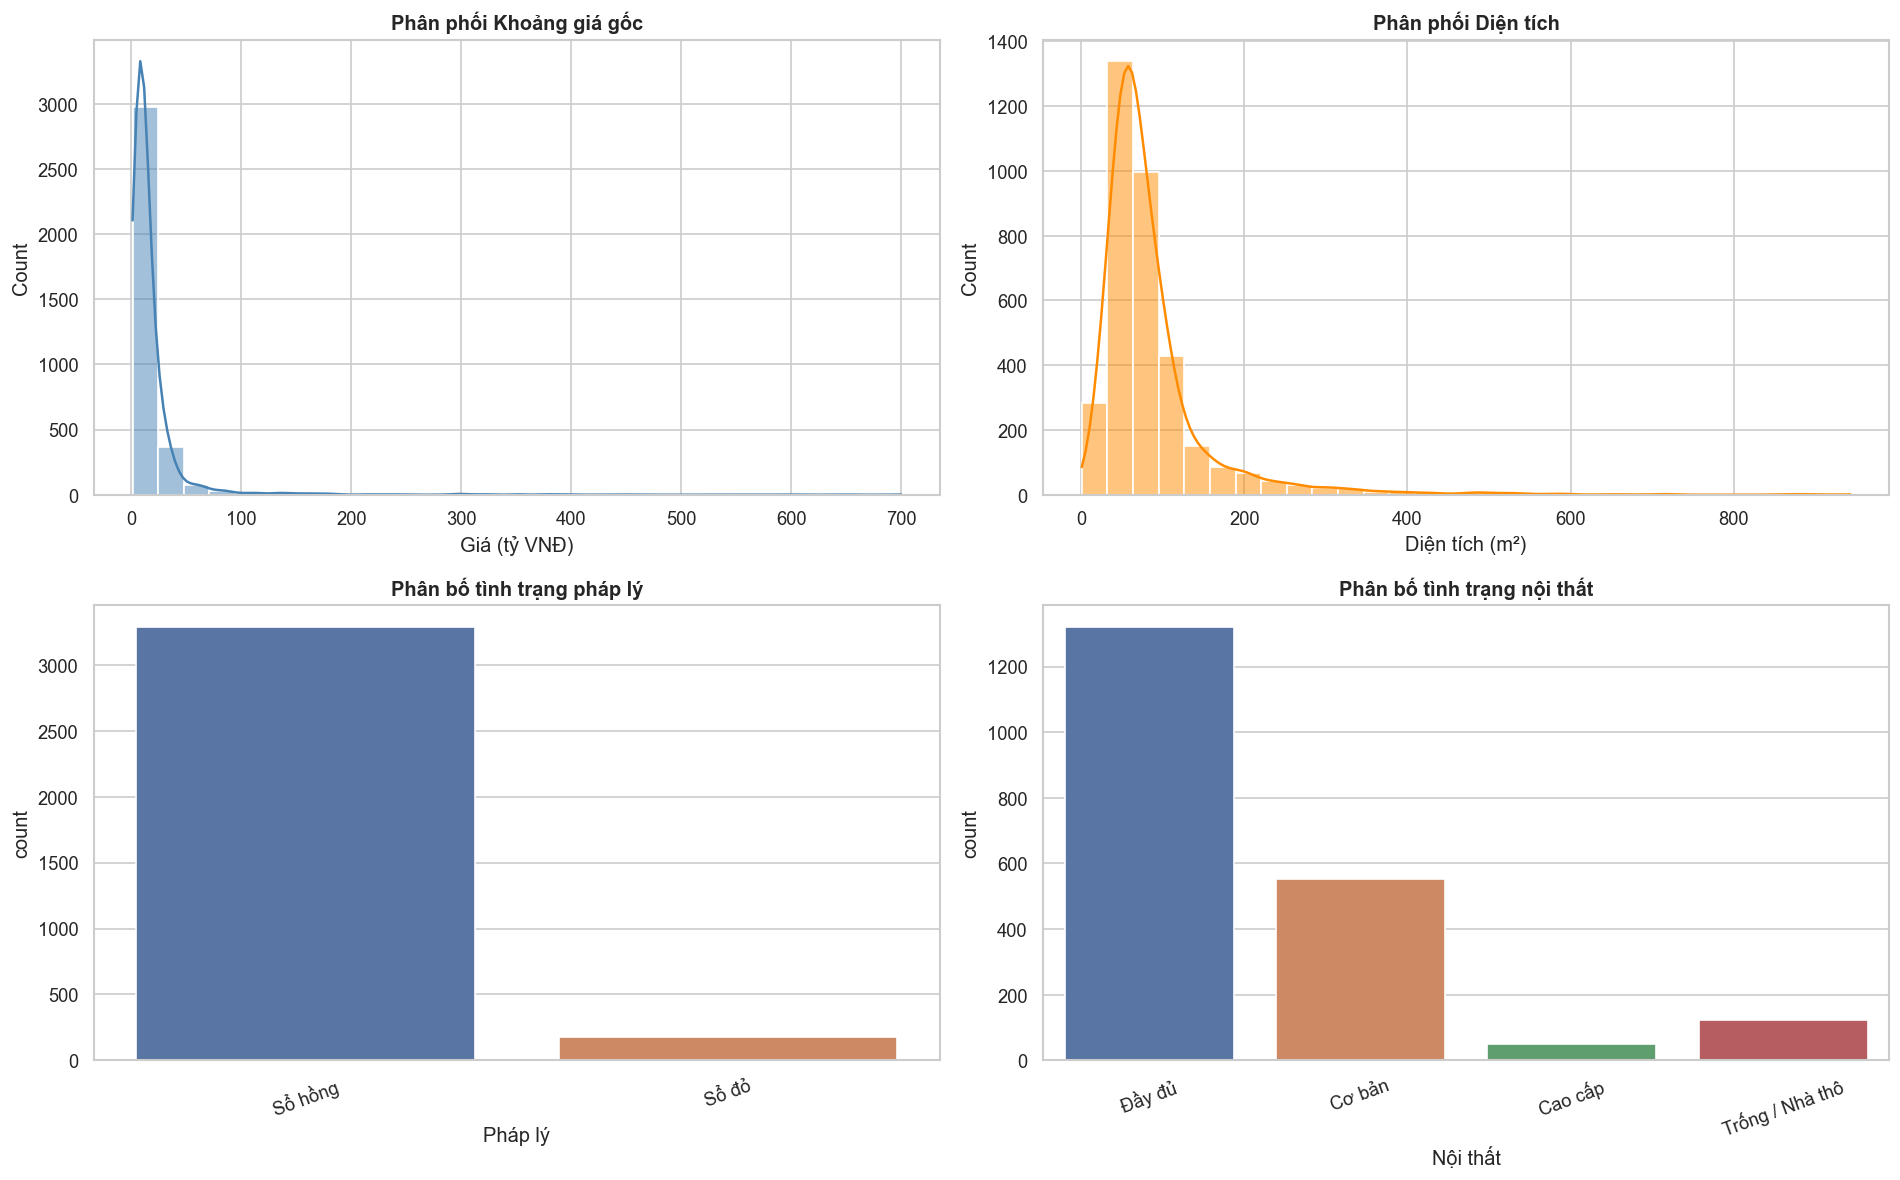


--- Quan hệ giữa thuộc tính số và giá gốc ---


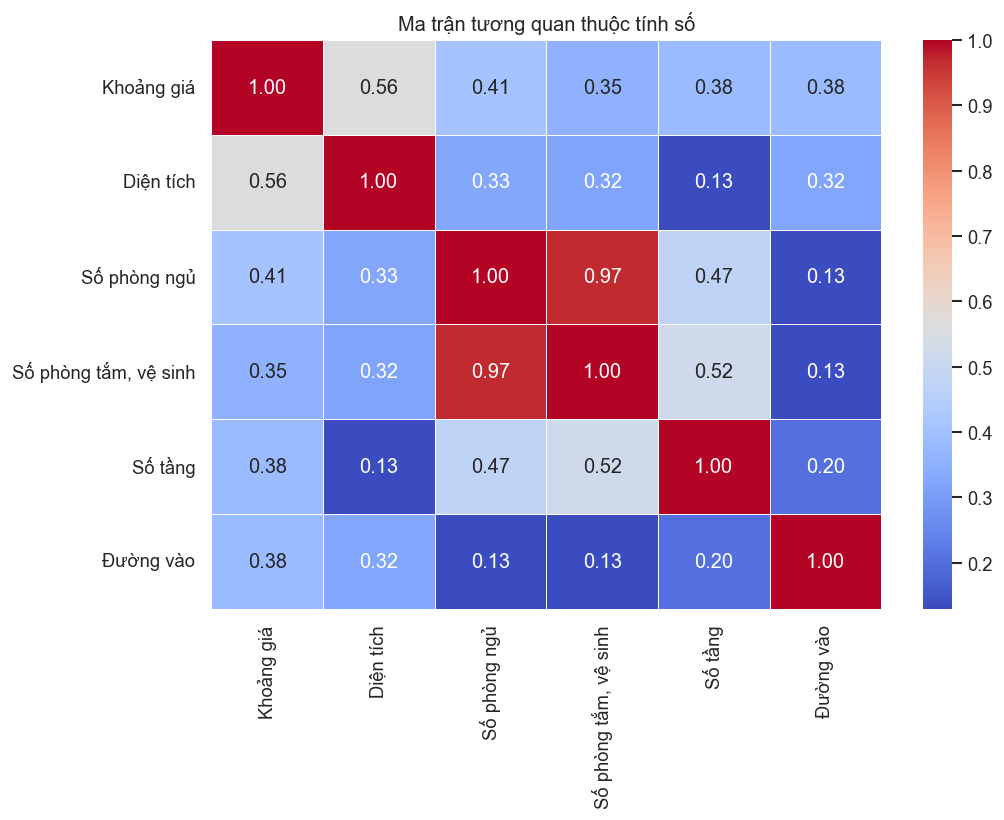

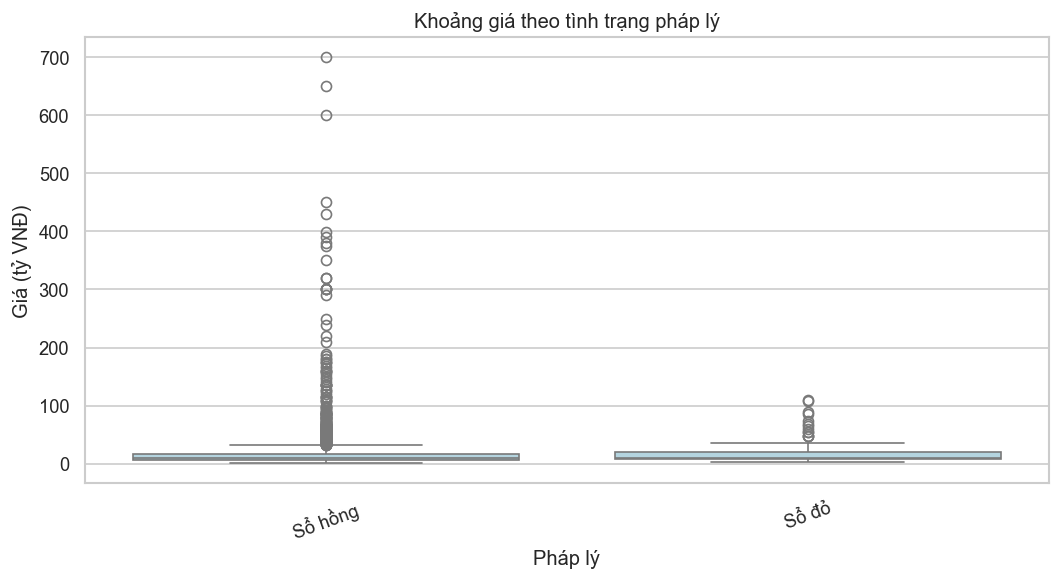

In [ ]:
print(f"{'='*20} KHÁM PHÁ DỮ LIỆU SAU KHI CHUẨN HOÁ KIỂU GIÁ TRỊ {'='*20}\n")

num_cols = ['Khoảng giá', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào']
num_cols = [c for c in num_cols if c in df.columns]
display(df[num_cols].describe().T)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(data=df, x='Khoảng giá', kde=True, ax=axes[0, 0], bins=30, color='steelblue')
axes[0, 0].set_title('Phân phối Khoảng giá gốc', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Giá (tỷ VNĐ)')

sns.histplot(data=df, x='Diện tích', kde=True, ax=axes[0, 1], bins=30, color='darkorange')
axes[0, 1].set_title('Phân phối Diện tích', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Diện tích (m²)')

if 'Pháp lý' in df.columns:
    sns.countplot(data=df, x='Pháp lý', ax=axes[1, 0], hue='Pháp lý', legend=False)
    axes[1, 0].set_title('Phân bố tình trạng pháp lý', fontsize=12, fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=20)
else:
    axes[1, 0].axis('off')

if 'Nội thất' in df.columns:
    sns.countplot(data=df, x='Nội thất', ax=axes[1, 1], hue='Nội thất', legend=False)
    axes[1, 1].set_title('Phân bố tình trạng nội thất', fontsize=12, fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=20)
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n--- Quan hệ giữa thuộc tính số và giá gốc ---")
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan thuộc tính số')
plt.tight_layout()
plt.show()

if 'Pháp lý' in df.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x='Pháp lý', y='Khoảng giá', color='lightblue')
    plt.title('Khoảng giá theo tình trạng pháp lý')
    plt.xlabel('Pháp lý')
    plt.ylabel('Giá (tỷ VNĐ)')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


- Biểu đồ dùng trực tiếp giá theo đơn vị **tỷ VNĐ**, vì mục tiêu sau cùng là chia dữ liệu thành các phân khúc giá.
- Việc giữ nguyên giá giúp các ngưỡng lớp sau này dễ giải thích: mỗi lớp tương ứng với một khoảng giá thật.
- Trạng thái pháp lý và nội thất có thể giữ riêng nếu phân bố giá giữa các nhóm khác nhau rõ rệt.


## Trích xuất "Loại đường vào" từ "Mô tả"

In [ ]:
def extract_loai_duong_vao(txt):
    """
    Hàm trích xuất Loại đường vào từ đoạn văn bản (mô tả bất động sản).
    Input: txt (string)
    Output: 'Mặt tiền', 'Hẻm ô tô', 'Hẻm xe máy' hoặc np.nan
    """
    # Xử lý trường hợp dữ liệu bị NaN hoặc không phải chuỗi
    if not isinstance(txt, str):
        return np.nan

    # Đưa về chữ thường để match regex chính xác hơn (tuỳ chọn nhưng rất khuyến nghị)
    txt = txt.lower()

    loai = np.nan
    
    # Kiểm tra mặt tiền / mặt phố
    if re.search(r'm[aặ]t ti[eề]n|nhà m[aặ]t ph[oố]|m[aặ]t ph[oố]', txt):
        loai = 'Mặt tiền'
        
    # Kiểm tra hẻm xe hơi / ô tô dựa trên keyword
    elif re.search(
        r'h[eẻ]m\s*(?:xe hơi|ô ?tô|2 xe quay đầu|hai xe|thông xe)'
        r'|ô ?tô\s*vào\s*nhà|xe hơi\s*vào\s*nhà', txt
    ):
        loai = 'Hẻm ô tô'
        
    # Nếu có chữ 'hẻm' nhưng không có keyword xe hơi, thử tìm độ rộng hẻm
    elif re.search(r'h[eẻ]m', txt):
        m_hem = re.search(r'h[eẻ]m(?:\s+\w+)?\s*([\d,\.]+)\s*m', txt)
        if m_hem:
            try:
                w = float(m_hem.group(1).replace(',', '.'))
                # Quy ước: hẻm >= 4m là hẻm ô tô, ngược lại là hẻm xe máy
                loai = 'Hẻm ô tô' if w >= 4 else 'Hẻm xe máy'
            except ValueError:
                pass
                
    return loai

# --- Ví dụ cách sử dụng ---
df['Loại đường vào'] = df['Mô tả'].apply(extract_loai_duong_vao)

# Trích xuất 'Đường', 'Phường', 'Quận' từ "Địa chỉ"

Lý do dùng Rule_base thay vì LLM: Cột địa chỉ trên trang web được viết theo một template cố định (vấn đề chỉ là thiếu thông tin hay không). Nếu sử dụng LLM chỉ khiến dư thừa và giảm hiệu quả.

In [ ]:
# ════════════════════════════════════════════════
# CELL: PHÂN RÃ CỘT ĐỊA CHỈ → Đường / Phường/Xã / Quận
# ════════════════════════════════════════════════

QUAN_KEYWORDS = r'(?:Quận|Huyện|Thành phố)'
PHUONG_KEYWORDS = r'(?:Phường|Xã|Thị trấn)'
DUONG_KEYWORDS = r'(?:Đường|Phố)'

def parse_address(addr):
    if pd.isna(addr):
        return pd.Series({'Đường': np.nan, 'Phường/Xã': np.nan, 'Quận': np.nan})

    segments = [s.strip() for s in addr.split(',')]
    duong = np.nan
    phuong = np.nan
    quan = np.nan

    for seg in segments:
        if re.match(rf'^{QUAN_KEYWORDS}\s+', seg) and quan is np.nan:
            m = re.match(rf'^{QUAN_KEYWORDS}\s+(.+)', seg)
            if m:
                quan = m.group(1).strip()
        elif re.match(rf'^{PHUONG_KEYWORDS}\s+', seg) and phuong is np.nan:
            m = re.match(rf'^{PHUONG_KEYWORDS}\s+(.+)', seg)
            if m:
                phuong = m.group(1).strip()
        elif re.search(rf'{DUONG_KEYWORDS}\s+', seg) and duong is np.nan:
            m = re.search(rf'{DUONG_KEYWORDS}\s+(.+)', seg)
            if m:
                duong = m.group(1).strip()

    return pd.Series({'Đường': duong, 'Phường/Xã': phuong, 'Quận': quan})


# Áp dụng
df[['Đường', 'Phường/Xã', 'Quận']] = df['Địa chỉ'].apply(parse_address)

# Kiểm tra kết quả
print(f"✅ Đã phân rã xong. Tỷ lệ null 3 cột mới:")
for col in ['Đường', 'Phường/Xã', 'Quận']:
    null_pct = df[col].isnull().mean() * 100
    print(f"   {col:8s}: {df[col].isnull().sum()} null ({null_pct:.1f}%)")

display(df[['Địa chỉ', 'Đường', 'Phường/Xã', 'Quận']].head(10))

✅ Đã phân rã xong. Tỷ lệ null 3 cột mới:
   Đường   : 186 null (5.3%)
   Phường/Xã: 0 null (0.0%)
   Quận    : 0 null (0.0%)


,Địa chỉ,Đường,Phường/Xã,Quận
0,"Đường Nguyễn Thượng Hiền, Phường 6, Quận Bình ...",Nguyễn Thượng Hiền,6,Bình Thạnh
1,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...",Đoàn Giỏi,Sơn Kỳ,Tân Phú
2,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",NaN,Long Hòa,Cần Giờ
3,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",NaN,Long Hòa,Cần Giờ
4,"The Manhattan Glory - Vinhomes Grand Park, Đườ...",Nguyễn Xiển,Long Bình,9
5,"Vinhomes Grand Park, Phường Long Thạnh Mỹ, Quậ...",NaN,Long Thạnh Mỹ,9
6,"Hẻm 869 , Đường Hoàng Sa, Phường 11, Quận 3, H...",Hoàng Sa,11,3
7,"Khu đô thị Vạn Phúc City, Đường Nguyễn Thị Nhu...",Nguyễn Thị Nhung,Hiệp Bình Phước,Thủ Đức
8,"Khu đô thị Vạn Phúc City, Đường Quốc Lộ 13, Ph...",Quốc Lộ 13,Hiệp Bình Phước,Thủ Đức
9,"Đường Phú Thuận, Phường Phú Thuận, Quận 7, Hồ ...",Phú Thuận,Phú Thuận,7


In [ ]:
print(df.columns)

Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả',
       'Loại đường vào', 'Đường', 'Phường/Xã', 'Quận'],
      dtype='str')


# 2. Xử lý missing value

## 2.1 Thống kê và xử lý sơ bộ.

Thống kê số lượng missing value ở từng cột.

Thống kê số lượng và tỷ lệ giá trị thiếu trên từng cột:


In [ ]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_stats = pd.concat(
    [missing_count, missing_percent],
    axis=1,
    keys=['Missing Count', 'Missing Percentage (%)']
)
missing_stats = missing_stats[missing_stats['Missing Count'] > 0].sort_values(
    by='Missing Count', ascending=False
)

if not missing_stats.empty:
    print(f"Tổng số cột bị khuyết dữ liệu: {len(missing_stats)} / {df.shape[1]}")
    display(missing_stats.round({'Missing Percentage (%)': 2}))
else:
    print("Dữ liệu không có giá trị khuyết thiếu.")


Tổng số cột bị khuyết dữ liệu: 11 / 19


,Missing Count,Missing Percentage (%)
Hướng ban công,3113,88.46
Hướng nhà,2821,80.16
Nội thất,1470,41.77
Loại đường vào,1272,36.15
Đường vào,1192,33.87
"Số phòng tắm, vệ sinh",694,19.72
Số phòng ngủ,545,15.49
Số tầng,216,6.14
Đường,186,5.29
Pháp lý,49,1.39


Xoá cột 'Hướng ban công' và 'Hướng nhà'

In [ ]:
df = df.drop(columns=['Hướng ban công', 'Hướng nhà'], errors='ignore')
print("✅ Đã loại các cột hướng nếu tồn tại trong dữ liệu.")


✅ Đã loại các cột hướng nếu tồn tại trong dữ liệu.


Xoá các bản ghi có 'Khoảng giá' bị nan

In [ ]:
# 1. In số lượng dòng hiện tại để đối chiếu
print(f"Số dòng trước khi xóa: {len(df)}")

# 2. Thực hiện xóa các dòng bị NaN ở riêng cột 'Khoảng giá'
df.dropna(subset=['Khoảng giá'], inplace=True)

# 3. Khôi phục (reset) lại index cho liền mạch sau khi các dòng bị rút ruột
df.reset_index(drop=True, inplace=True)

# 4. Kiểm tra lại kết quả
print(f"Số dòng sau khi xóa: {len(df)}")
print(f"Số lượng NaN hiện tại trong cột 'Khoảng giá': {df['Khoảng giá'].isnull().sum()}")

Số dòng trước khi xóa: 3519
Số dòng sau khi xóa: 3518
Số lượng NaN hiện tại trong cột 'Khoảng giá': 0


Thống kê trên box plot để tìm outlier.

📊 ĐANG VẼ 8 CỘT DỮ LIỆU DẠNG SỐ (TÌM OUTLIERS)...
------------------------------------------------------------


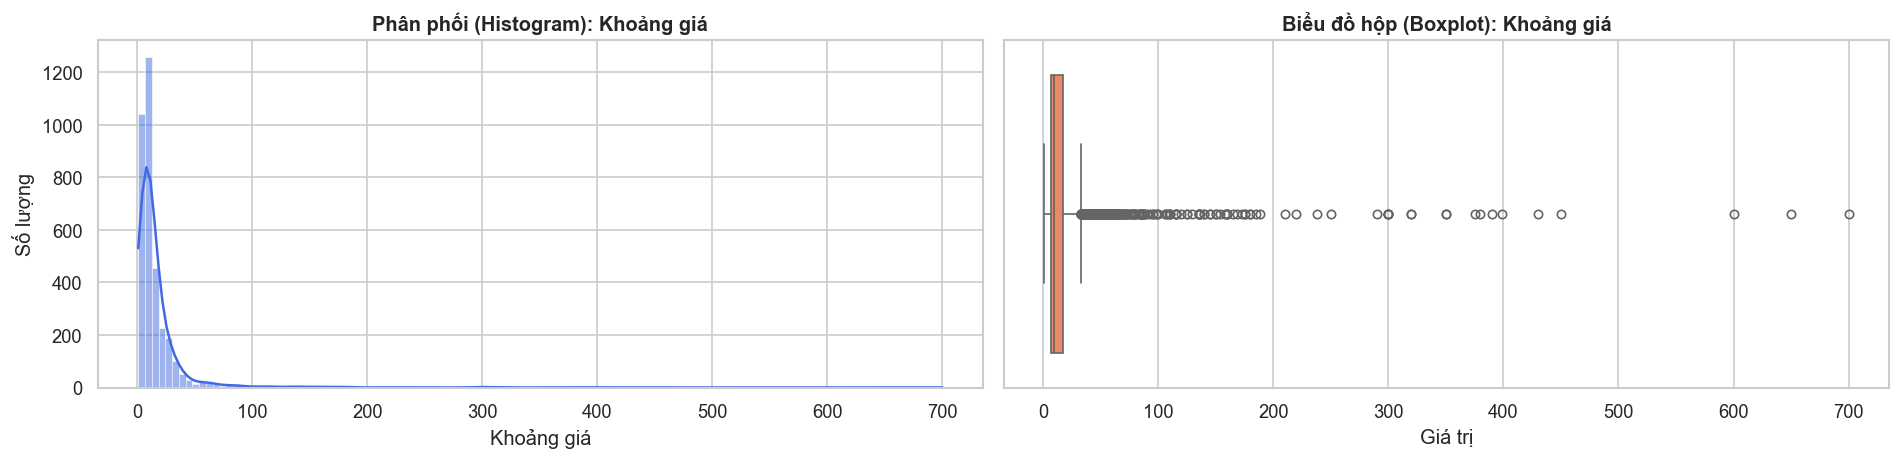

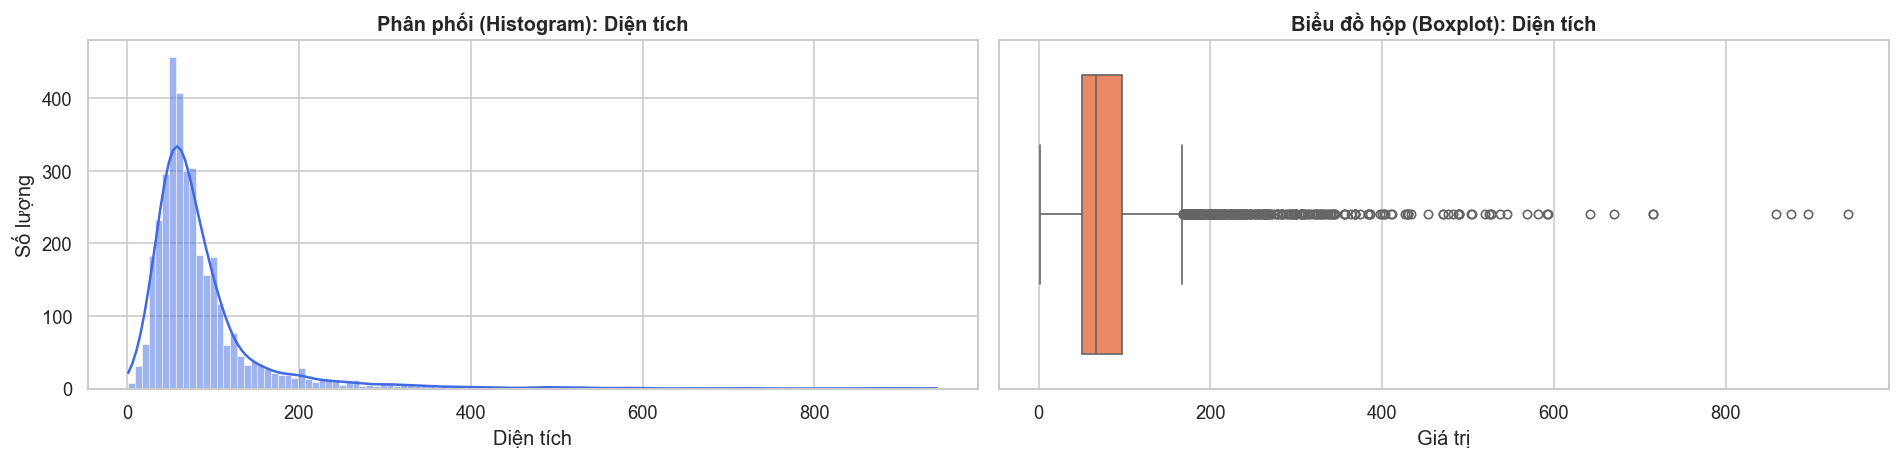

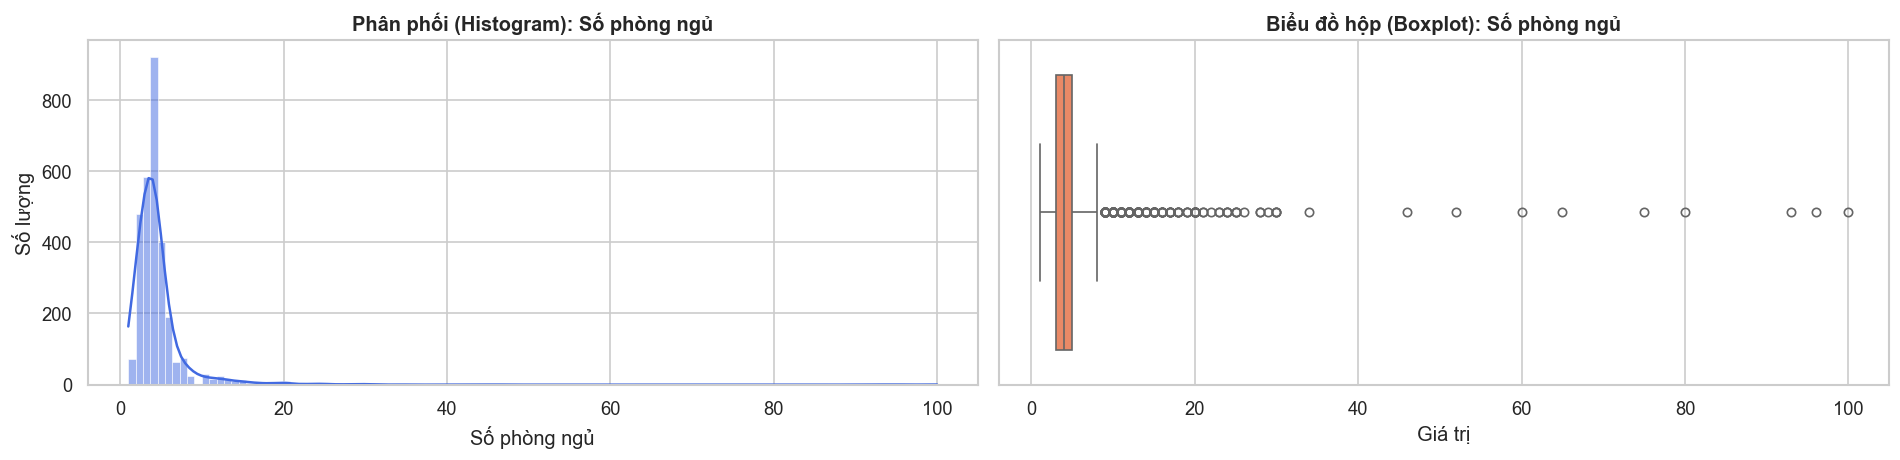

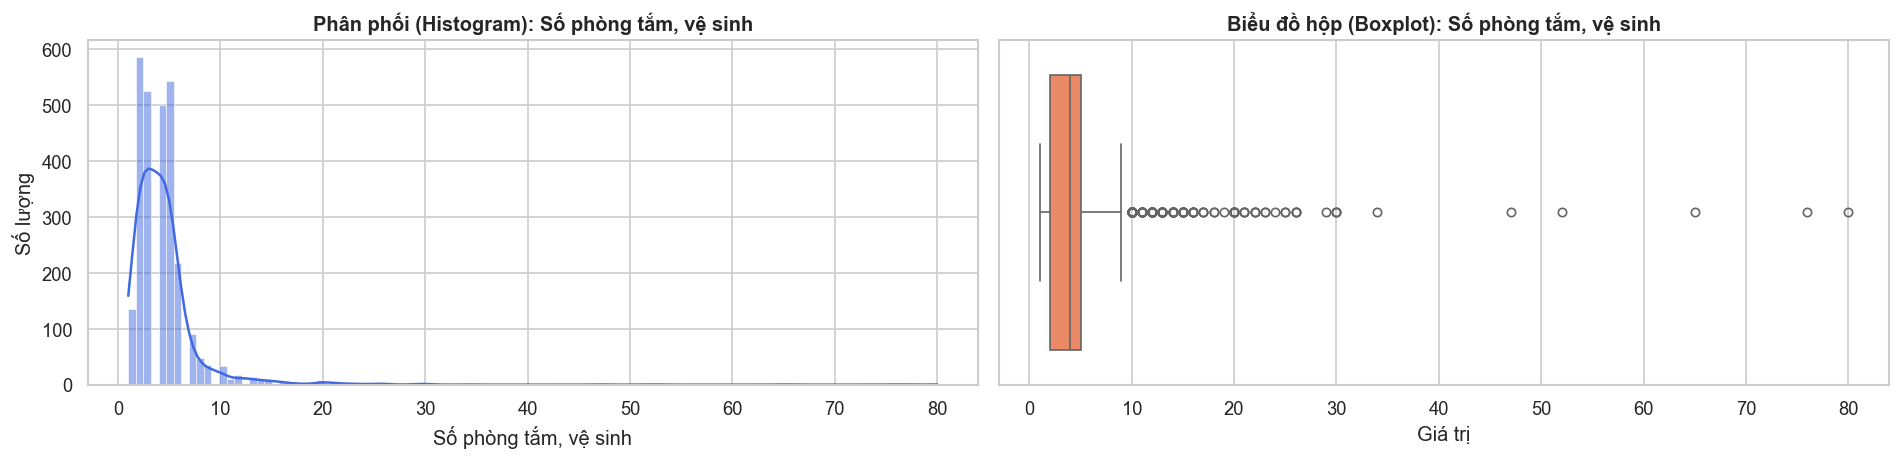

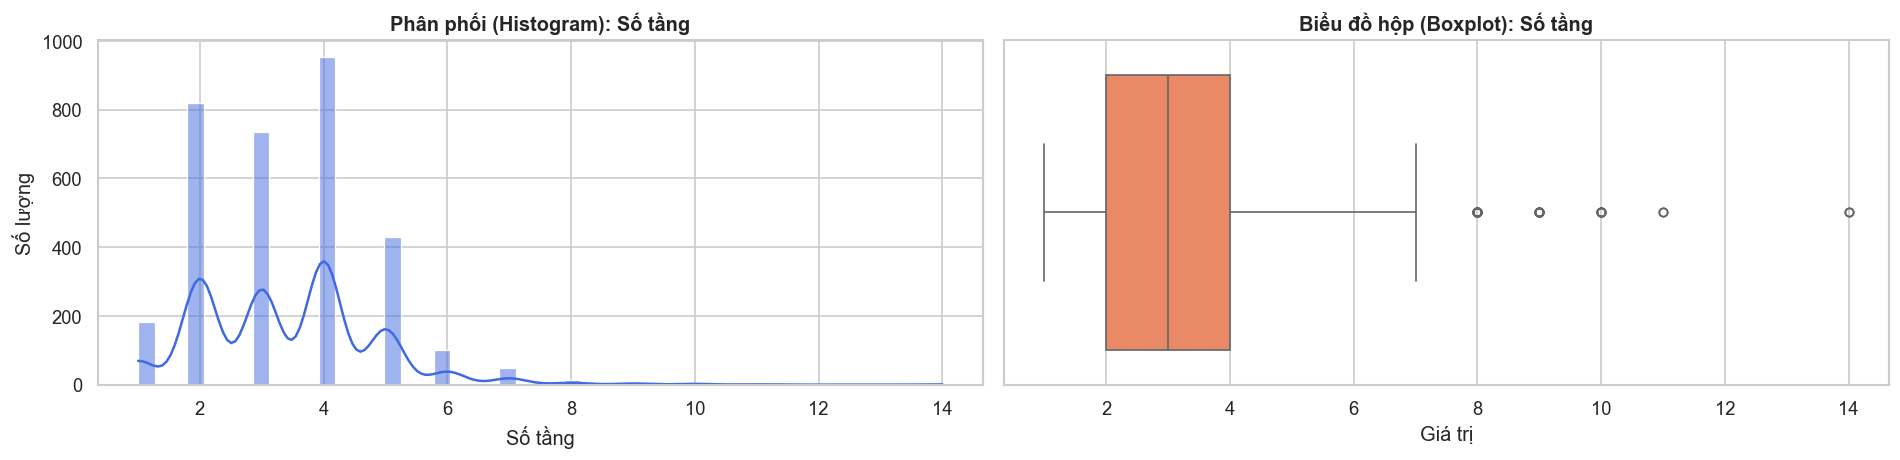

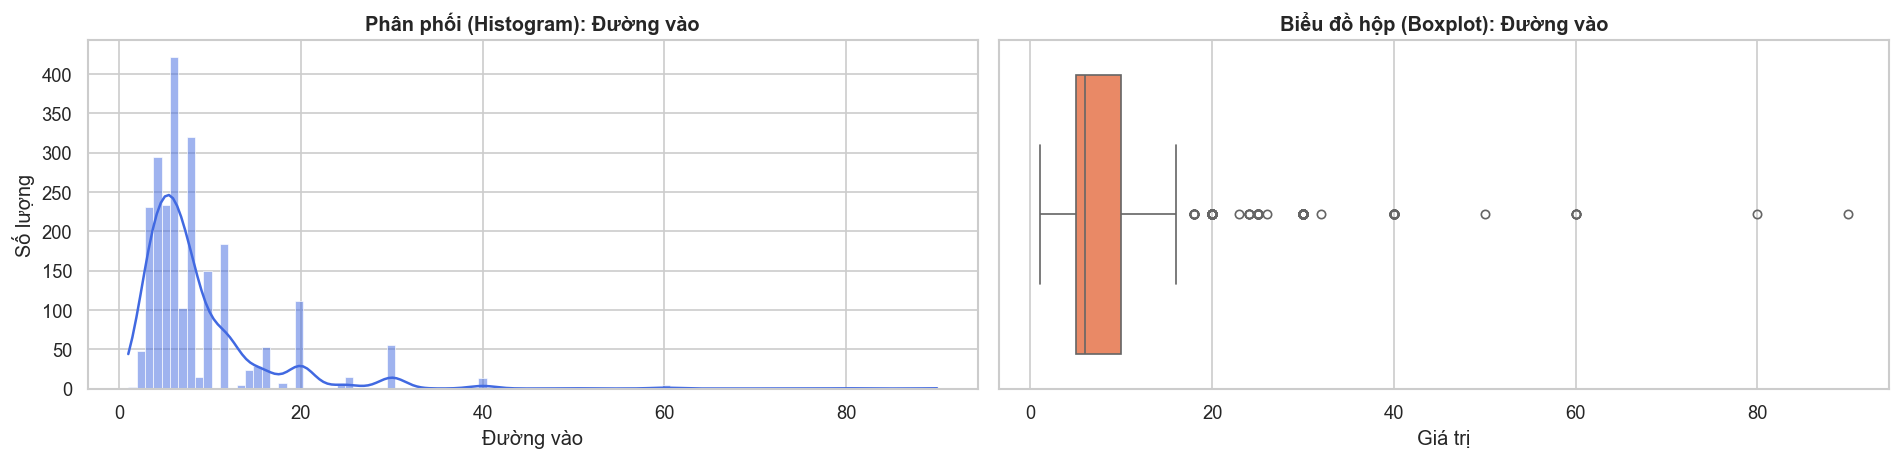

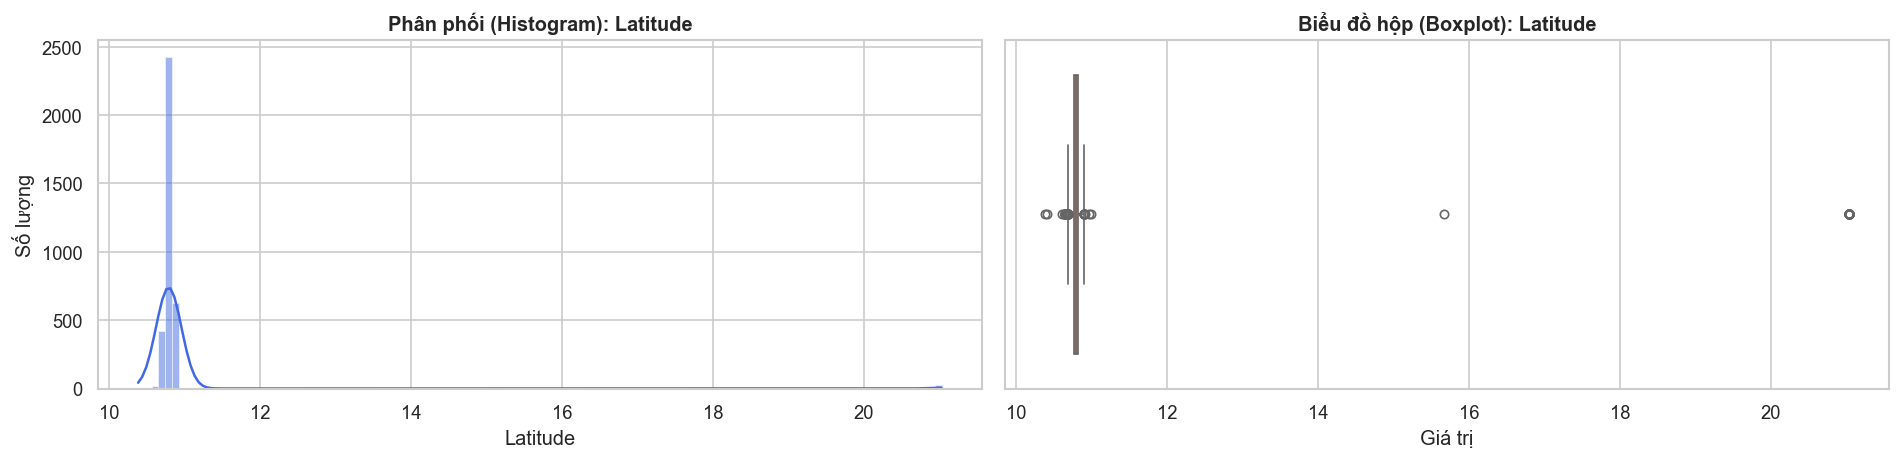

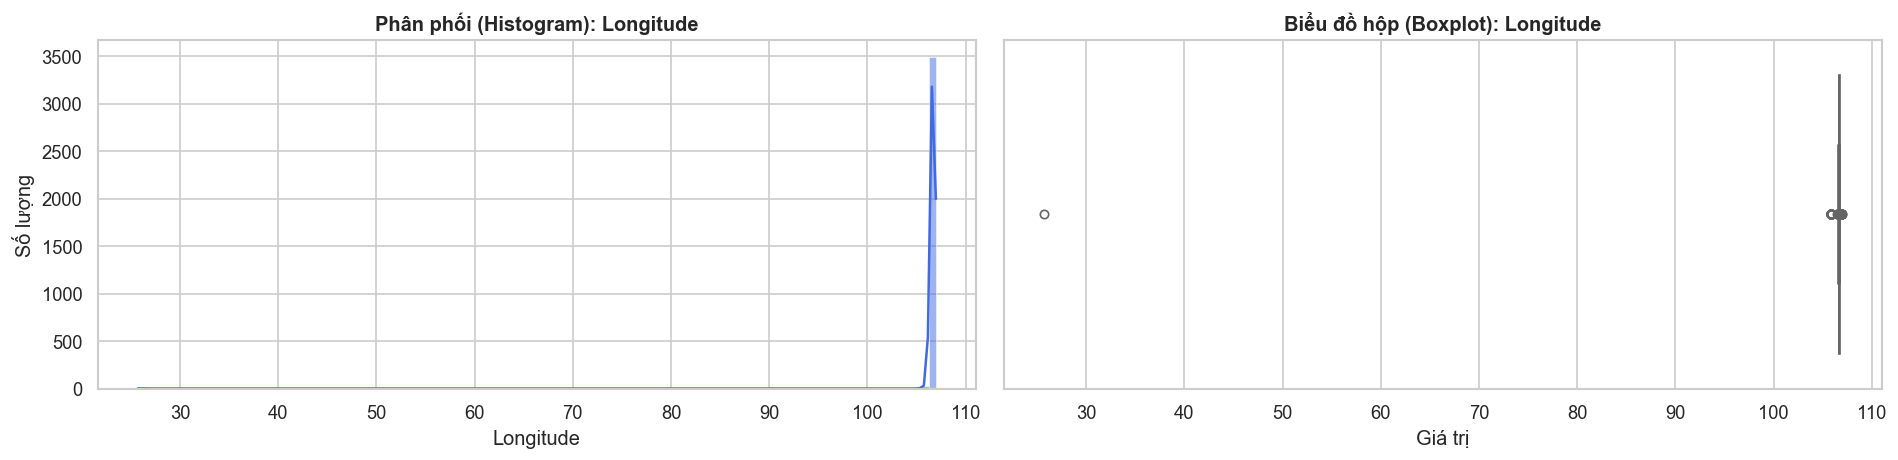

📝 ĐANG VẼ 5 BIẾN PHÂN LOẠI CẦN THIẾT...
------------------------------------------------------------


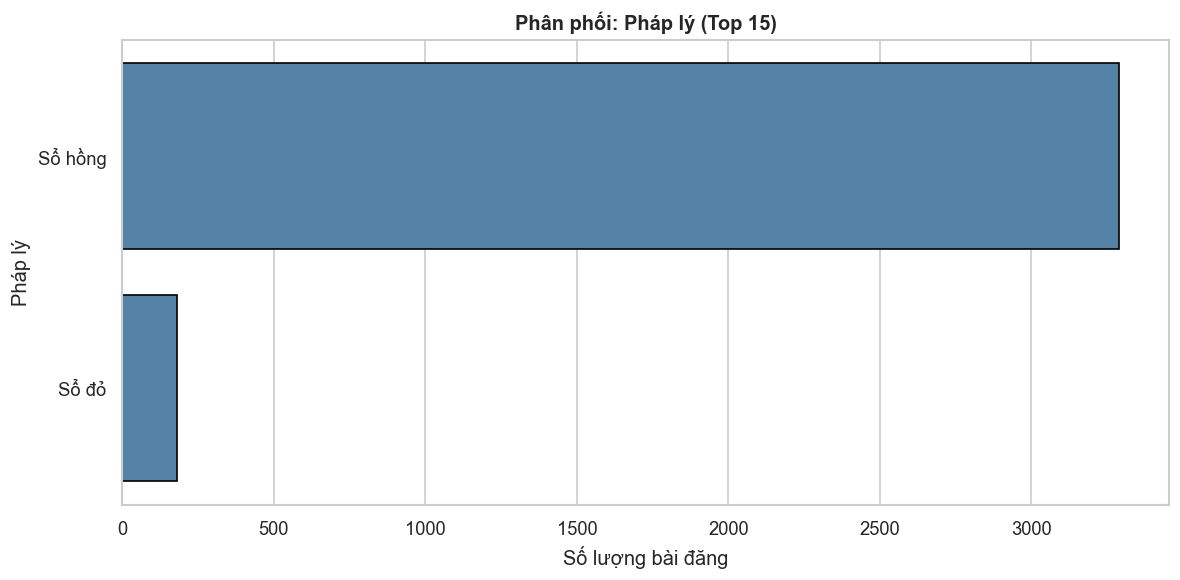

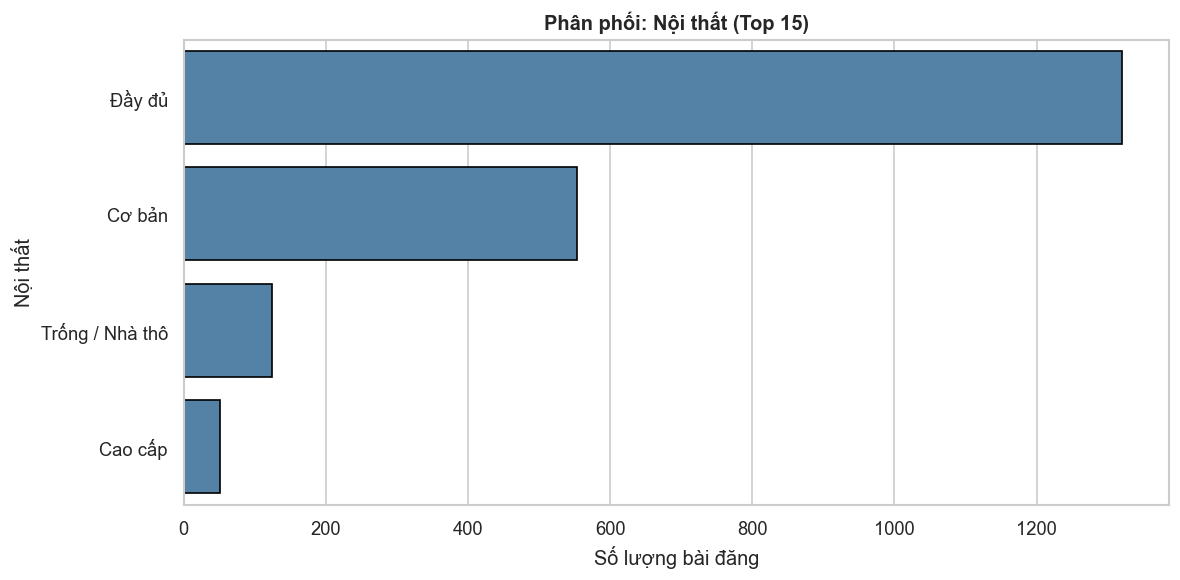

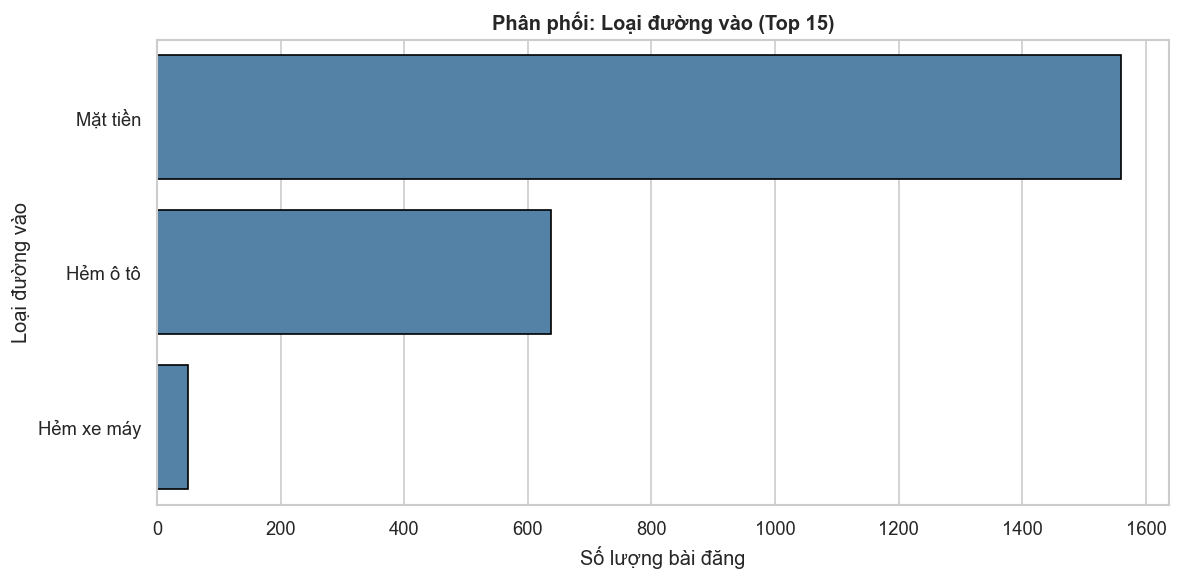

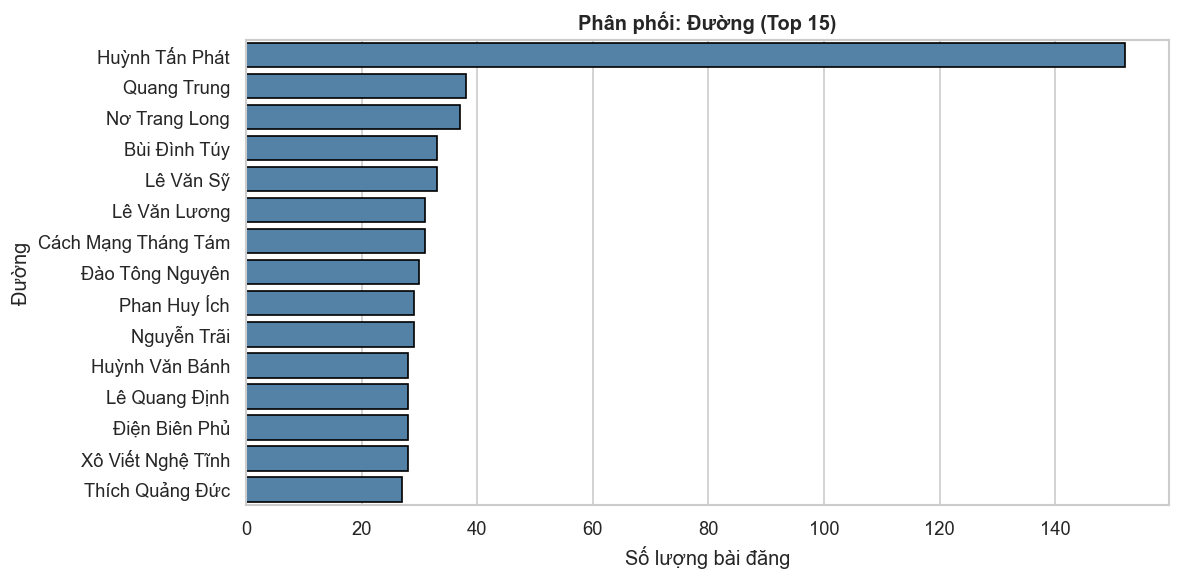

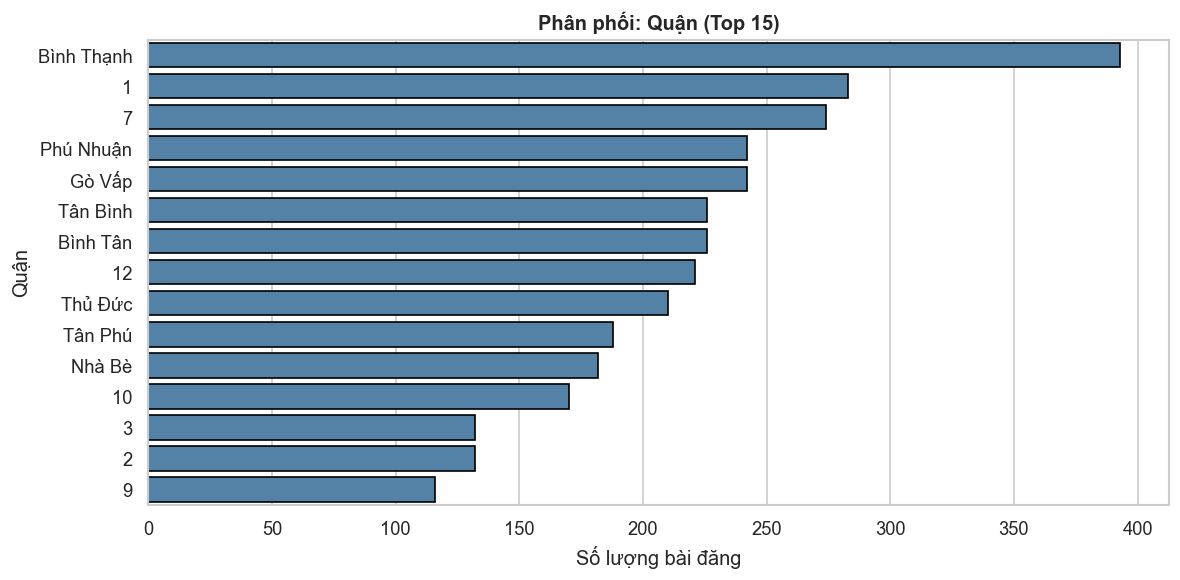

In [ ]:
# 1. Tách riêng các cột dạng Số và dạng Chữ (Phân loại)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# ---------------------------------------------------------
# PHẦN 1: VẼ CỘT DỮ LIỆU SỐ (NUMERICAL) - Tìm Outliers
# ---------------------------------------------------------
print(f"📊 ĐANG VẼ {len(num_cols)} CỘT DỮ LIỆU DẠNG SỐ (TÌM OUTLIERS)...")
print("-" * 60)

for col in num_cols:
    # Bỏ qua các giá trị NaN khi vẽ để tránh lỗi
    data_clean = df[col].dropna()
    
    # Khởi tạo khung hình với 2 biểu đồ cạnh nhau (Histogram bên trái, Boxplot bên phải)
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    
    # Biểu đồ 1: Histogram (Xem hình dáng phân phối)
    sns.histplot(data_clean, kde=True, ax=axes[0], color='royalblue', edgecolor='white')
    axes[0].set_title(f'Phân phối (Histogram): {col}', fontweight='bold')
    axes[0].set_ylabel('Số lượng')
    
    # Biểu đồ 2: Boxplot (Chuyên gia soi Outliers)
    sns.boxplot(x=data_clean, ax=axes[1], color='coral', fliersize=5)
    axes[1].set_title(f'Biểu đồ hộp (Boxplot): {col}', fontweight='bold')
    axes[1].set_xlabel('Giá trị')
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# PHẦN 2: VẼ CỘT DỮ LIỆU CHỮ (CATEGORICAL) - Tìm lỗi nhập liệu
# ---------------------------------------------------------
cat_cols_to_plot = ['Pháp lý', 'Nội thất', 'Loại đường vào', 'Đường', 'Phường/Xã/Thị Trấn', 'Quận']  # Chọn các cột phân loại quan trọng để vẽ

# 2. Kiểm tra xem các cột này có thực sự tồn tại trong DataFrame không để tránh lỗi
cols_exist = [col for col in cat_cols_to_plot if col in df.columns]

if len(cols_exist) > 0:
    print(f"📝 ĐANG VẼ {len(cols_exist)} BIẾN PHÂN LOẠI CẦN THIẾT...")
    print("-" * 60)
    
    for col in cols_exist:
        # Bỏ qua NaN để đếm chính xác, nhưng nếu muốn hiện cả số lượng Missing, hãy thay bằng: df[col].fillna('Missing')
        data_clean = df[col].dropna()
        
        if len(data_clean) > 0:
            plt.figure(figsize=(10, 5))
            
            # Chỉ lấy top 15 giá trị phổ biến nhất để biểu đồ sạch sẽ
            top_categories = data_clean.value_counts().nlargest(15).index
            
            sns.countplot(
                y=data_clean,
                order=top_categories,
                color='steelblue',
                edgecolor='black'
            )
            
            plt.title(f'Phân phối: {col} (Top 15)', fontweight='bold')
            plt.xlabel('Số lượng bài đăng')
            plt.ylabel(col)
            
            # Tinh chỉnh lại layout cho đẹp
            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠️ Cột '{col}' không có dữ liệu hợp lệ để vẽ.")
else:
    print("Không tìm thấy các cột phân loại yêu cầu trong DataFrame.")

In [ ]:
print(df.columns)

Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất',
       'Latitude', 'Longitude', 'Mô tả', 'Loại đường vào', 'Đường',
       'Phường/Xã', 'Quận'],
      dtype='str')


## Chia train/test (Tránh Data Leakage)

In [ ]:
# ── NOTE (Best Practice): Xóa outlier trước khi split để tránh index drift.
# Notebook này đã xử lý outlier trên df ở trên nên split cần dùng df đã clean.
# Từ đây trở đi KHÔNG thực hiện thêm bất kỳ thao tác nào trên df gốc nữa.

target_col = 'Khoảng giá'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("✅ Đã chia tách dữ liệu thành công!")
print("-" * 50)
print(f"Tập Huấn luyện (Train) : X={X_train.shape}, y={y_train.shape}")
print(f"Tập Kiểm thử (Test)    : X={X_test.shape},  y={y_test.shape}")

✅ Đã chia tách dữ liệu thành công!
--------------------------------------------------
Tập Huấn luyện (Train) : X=(2814, 16), y=(2814,)
Tập Kiểm thử (Test)    : X=(704, 16),  y=(704,)


Ma trận tương quan trước khi xử lý

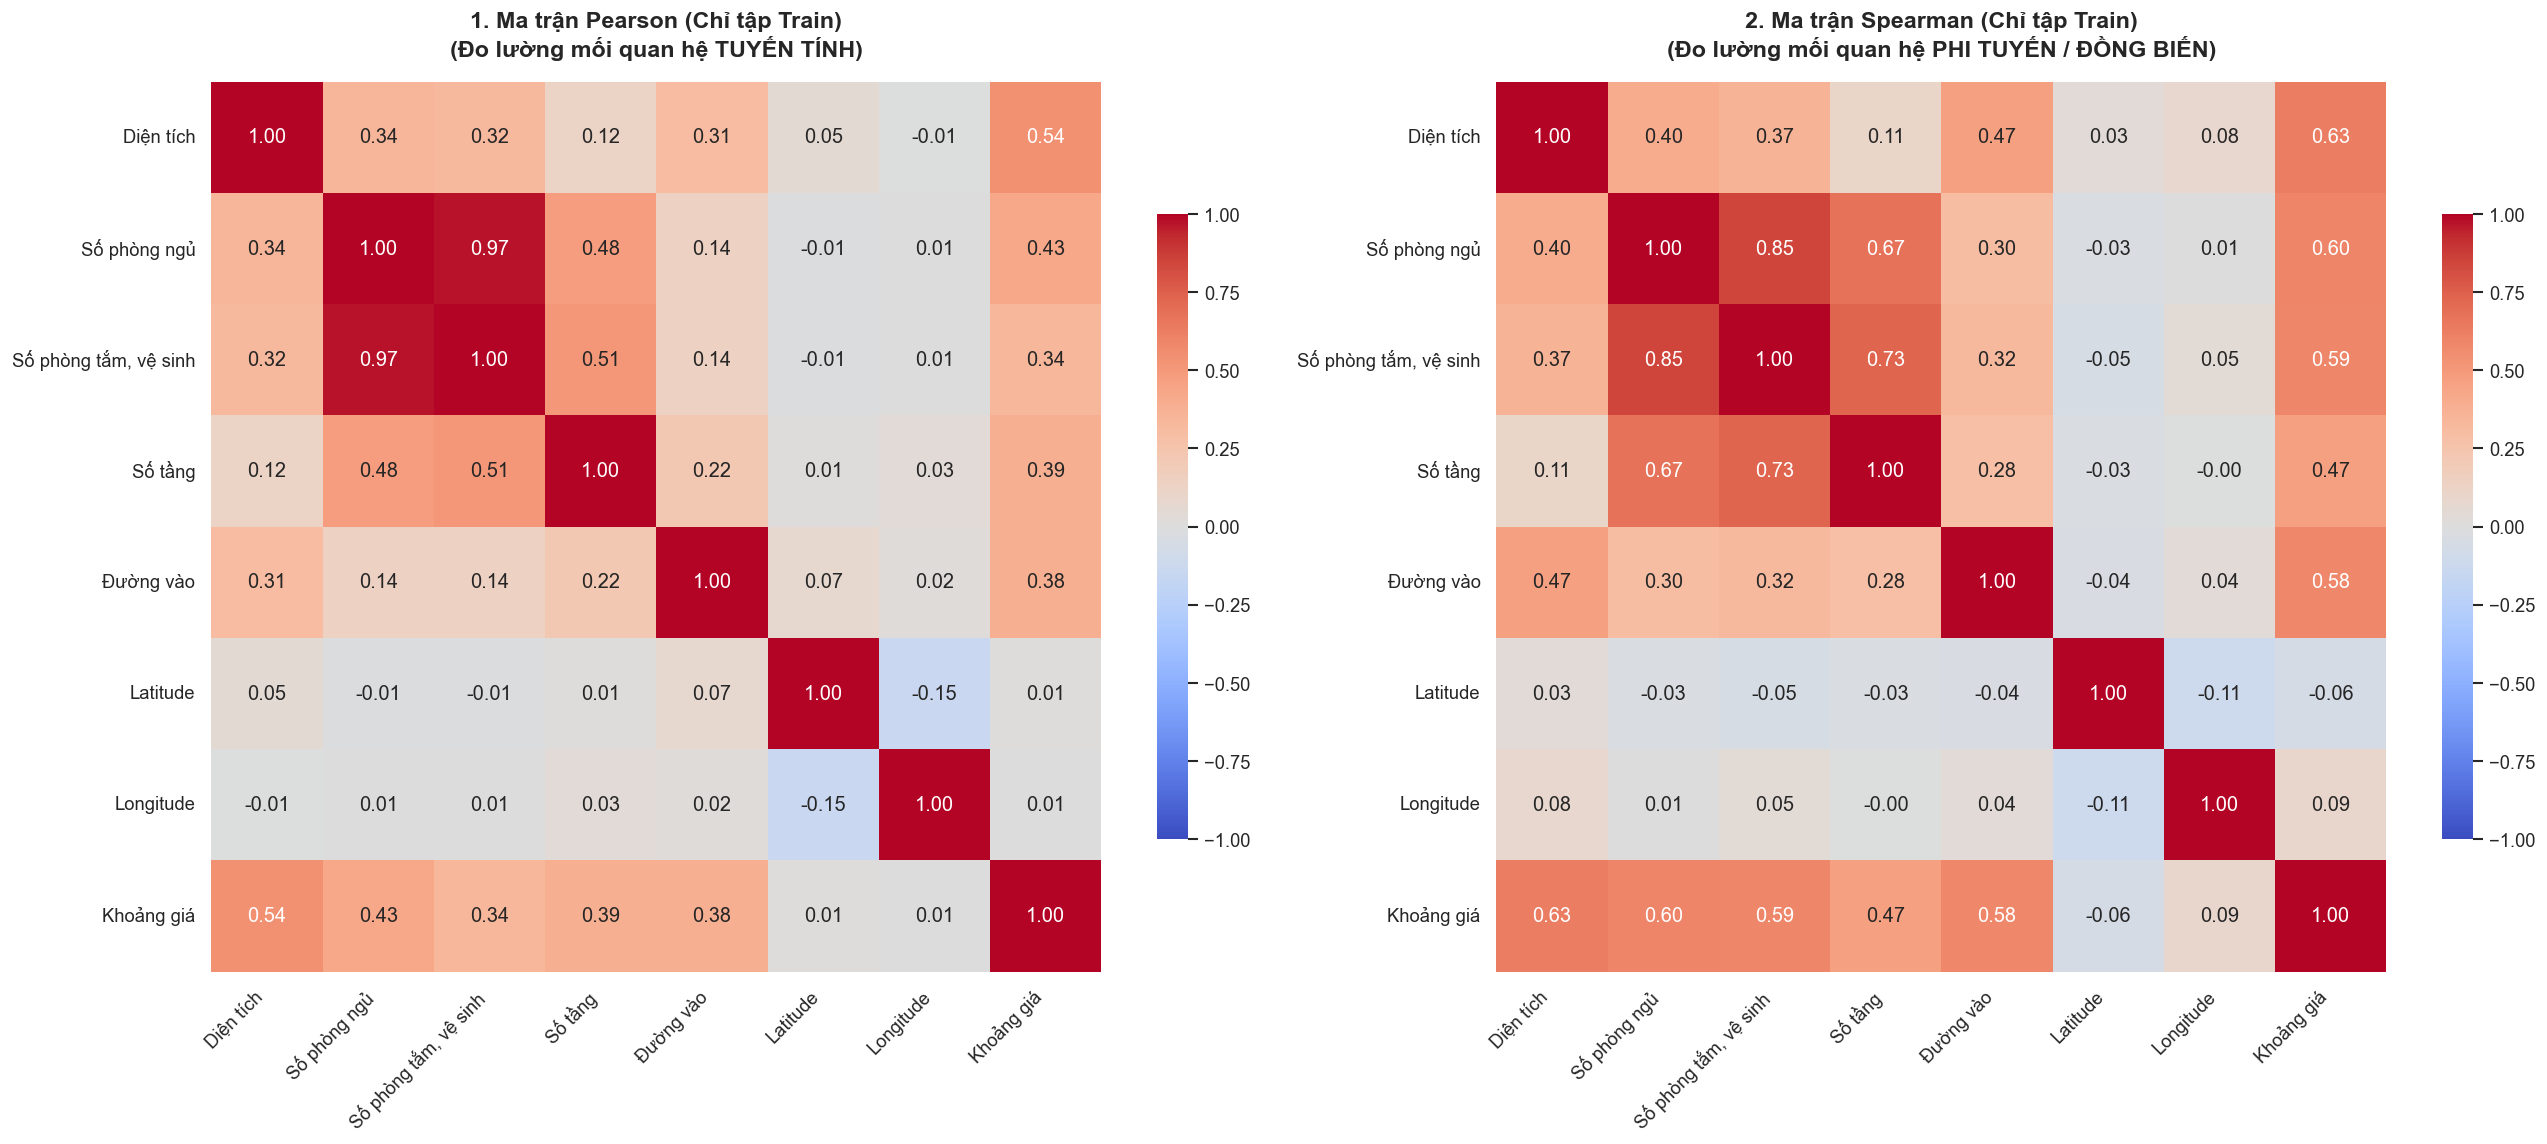

In [ ]:
# 1. Ghép X_train và y_train thành một DataFrame tạm thời để tính tương quan
# axis=1 giúp ghép theo chiều ngang (ghép thêm cột)
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Chỉ chọn các cột dữ liệu số từ tập huấn luyện
train_data_numeric = train_data.select_dtypes(include=[np.number])

# 3. Tính toán 2 loại ma trận tương quan (chỉ trên dữ liệu Train)
pearson_corr = train_data_numeric.corr(method='pearson')
spearman_corr = train_data_numeric.corr(method='spearman')

# 4. Khởi tạo khung hình side-by-side (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# --- BIỂU ĐỒ 1: Ma trận Pearson (Tuyến tính) ---
sns.heatmap(
    pearson_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    ax=axes[0],
    cbar_kws={"shrink": .7}
)
axes[0].set_title('1. Ma trận Pearson (Chỉ tập Train)\n(Đo lường mối quan hệ TUYẾN TÍNH)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# --- BIỂU ĐỒ 2: Ma trận Spearman (Hạng / Phi tuyến) ---
sns.heatmap(
    spearman_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    ax=axes[1],
    cbar_kws={"shrink": .7}
)
axes[1].set_title('2. Ma trận Spearman (Chỉ tập Train)\n(Đo lường mối quan hệ PHI TUYẾN / ĐỒNG BIẾN)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

# Tinh chỉnh khoảng cách và hiển thị
plt.tight_layout()
plt.show()

- Các giá trị trong ma trận Spearman cao hơn hẳn các giá trị Pearson. Do đó dữ liệu này có mối quan hệ phi tuyến. Nếu phải điền khuyết bằng mô hình thì các mô hình hồi quy tuyến tính sẽ không hiệu quả.
- Thay vào đó, các mô hình cây quyết định như Random Forest hoặc XGBoost/LightGBM sẽ phù hợp hơn với bộ dữ liệu này.

Tương quan giữa số lượng missing và các thuộc tính khác.

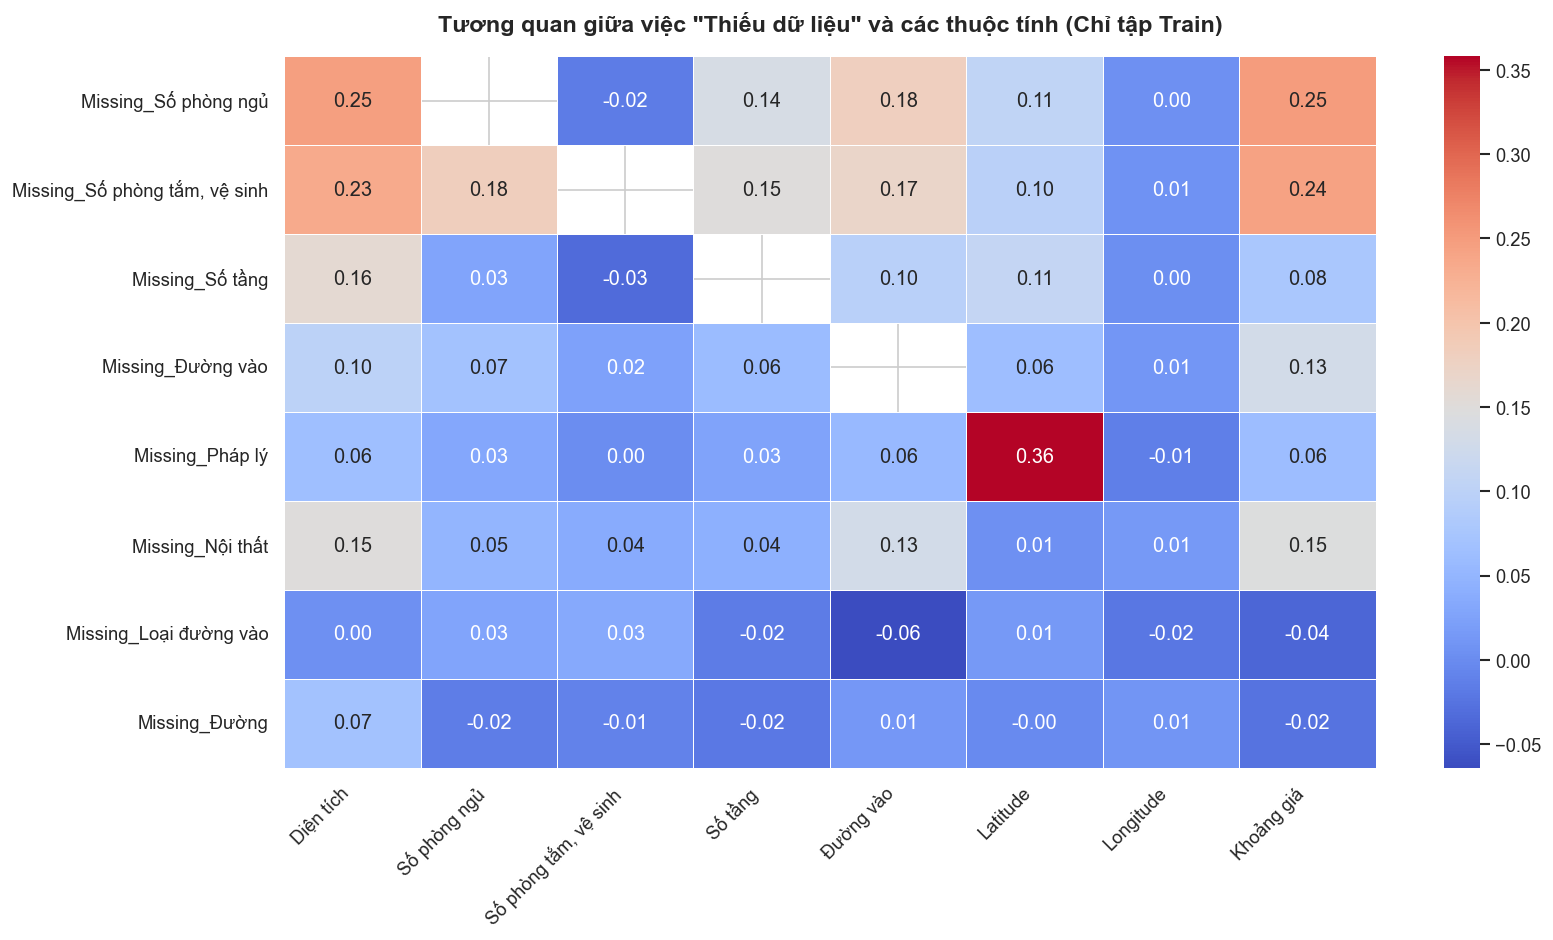

✅ Đã hoàn tất phân tích tương quan Missing Data trên tập Train.


In [ ]:
# ════════════════════════════════════════════════
# CELL: PHÂN TÍCH CƠ CHẾ MISSING DATA (CHỈ TRÊN TẬP TRAIN)
# ════════════════════════════════════════════════

# 1. Ghép X_train và y_train thành bảng tạm thời để phân tích đồng bộ
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Tìm các cột có chứa dữ liệu thiếu trong tập Train
cols_with_missing = [col for col in train_data.columns if train_data[col].isnull().sum() > 0]

if not cols_with_missing:
    print("✅ Tuyệt vời! Tập Train hiện tại không có dữ liệu khuyết thiếu nào.")
else:
    # Tạo các cột Dummy (Missingness Indicator)
    for col in cols_with_missing:
        train_data[f'Missing_{col}'] = train_data[col].isnull().astype(int)

    # 3. Phân tách danh sách cột
    dummy_cols = [f'Missing_{col}' for col in cols_with_missing]
    numeric_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()
    analysis_cols = [c for c in numeric_cols if c not in dummy_cols]

    # 4. Tính toán ma trận tương quan
    corr_matrix = train_data[dummy_cols + analysis_cols].corr()
    corr_subset = corr_matrix.loc[dummy_cols, analysis_cols]

    # 5. Vẽ biểu đồ Heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Tương quan giữa việc "Thiếu dữ liệu" và các thuộc tính (Chỉ tập Train)', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("✅ Đã hoàn tất phân tích tương quan Missing Data trên tập Train.")

In [ ]:
# ════════════════════════════════════════════════
# CELL: KIỂM ĐỊNH LITTLE'S MCAR (CHỈ TRÊN TẬP TRAIN)
# ════════════════════════════════════════════════

def littles_mcar_test(dataset):
    """
    Thực hiện kiểm định Little's MCAR chuẩn xác cho các thuộc tính số học.
    """
    # 1. Chỉ lọc lấy các cột dữ liệu số học và bỏ qua các cột dính NaN hoàn toàn
    data = dataset.select_dtypes(include=[np.number]).copy()
    data = data.dropna(how='all', axis=1)
    
    # 2. Tính toán Vectơ trung bình tổng thể và Ma trận hiệp phương sai tổng thể
    grand_mean = data.mean()
    grand_cov = data.cov()
    
    # Nếu ma trận hiệp phương sai bị khuyết do dữ liệu quá thưa, dùng tạm complete cases
    if grand_cov.isnull().any().any():
        grand_cov = data.dropna().cov()
        grand_mean = data.dropna().mean()

    # 3. Xác định các mô hình khuyết thiếu (Missingness Patterns)
    missing_matrix = data.isnull().astype(int)
    unique_patterns = missing_matrix.drop_duplicates()
    
    chi2_stat = 0
    df_total = 0
    n_var = data.shape[1]
    
    # 4. Duyệt qua từng mô hình khuyết thiếu để tính khoảng cách Mahalanobis
    for _, pattern in unique_patterns.iterrows():
        rows_idx = missing_matrix[(missing_matrix == pattern).all(axis=1)].index
        n_j = len(rows_idx)
        
        # Xác định các cột CÓ dữ liệu (giá trị bằng 0 trong missing_matrix)
        obs_vars = pattern[pattern == 0].index.tolist()
        p_j = len(obs_vars)
        
        if p_j == 0 or p_j == n_var and len(unique_patterns) == 1:
            continue
            
        sample_mean_j = data.loc[rows_idx, obs_vars].mean()
        
        grand_mean_j = grand_mean[obs_vars]
        grand_cov_j = grand_cov.loc[obs_vars, obs_vars]
        
        try:
            inv_cov_j = np.linalg.inv(grand_cov_j)
            diff = sample_mean_j - grand_mean_j
            
            d2 = n_j * np.dot(np.dot(diff, inv_cov_j), diff)
            
            chi2_stat += d2
            df_total += p_j
        except np.linalg.LinAlgError:
            continue
            
    df_total = df_total - n_var
    
    if df_total <= 0:
        return None, None, "Không đủ bậc tự do để tính toán p-value."
        
    p_value = chi2.sf(chi2_stat, df_total)
    
    return chi2_stat, df_total, p_value


# ─── CHẠY KIỂM ĐỊNH TRÊN TẬP TRAIN ───

# 1. Ghép X_train và y_train thành một DataFrame đồng bộ
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Gọi hàm kiểm định trên tập dữ liệu Train vừa tạo
stat, dof, p_val = littles_mcar_test(train_data)

# 3. In kết quả trực quan
print(f"{'='*10} KẾT QUẢ KIỂM ĐỊNH LITTLE'S MCAR (CHỈ TRÊN TẬP TRAIN) {'='*10}\n")
if stat is not None:
    print(f"-> Thống kê Chi-square (độ lệch) : {stat:.4f}")
    print(f"-> Bậc tự do (Degrees of Freedom): {dof}")
    print(f"-> Giá trị P-value               : {p_val:.6f}")
    print("-" * 50)
    print("\n💡 KẾT LUẬN THỐNG KÊ:")
    if p_val > 0.05:
        print("✅ p-value > 0.05: CHẤP NHẬN giả thuyết H0.")
        print("-> Dữ liệu khuyết thiếu của bạn là HOÀN TOÀN NGẪU NHIÊN (MCAR).")
        print("-> Bạn có thể an tâm áp dụng các cách điền khuyết đơn giản như Mean/Median Imputation.")
    else:
        print("⚠️ p-value <= 0.05: BÁO ĐỘNG! BÁO BỎ giả thuyết H0.")
        print("-> Dữ liệu khuyết thiếu KHÔNG NGẪU NHIÊN (MAR hoặc MNAR).")
        print("-> Việc thiếu thông tin tuân theo một quy luật hệ thống nào đó.")
        print("-> CHIẾN LƯỢC: Tuyệt đối không điền bừa bãi bằng Mean/Median tổng thể vì sẽ làm méo mó dữ liệu.")
        print("   Hãy cân nhắc điền khuyết theo phân cụm (Group-by Imputation) hoặc thuật toán dự đoán MICE/KNN.")
else:
    print(f"Không thể thực hiện kiểm định: {p_val}")

========== KẾT QUẢ KIỂM ĐỊNH LITTLE'S MCAR (CHỈ TRÊN TẬP TRAIN) ==========

-> Thống kê Chi-square (độ lệch) : 741.6264
-> Bậc tự do (Degrees of Freedom): 82
-> Giá trị P-value               : 0.000000
--------------------------------------------------

💡 KẾT LUẬN THỐNG KÊ:
⚠️ p-value <= 0.05: BÁO ĐỘNG! BÁO BỎ giả thuyết H0.
-> Dữ liệu khuyết thiếu KHÔNG NGẪU NHIÊN (MAR hoặc MNAR).
-> Việc thiếu thông tin tuân theo một quy luật hệ thống nào đó.
-> CHIẾN LƯỢC: Tuyệt đối không điền bừa bãi bằng Mean/Median tổng thể vì sẽ làm méo mó dữ liệu.
   Hãy cân nhắc điền khuyết theo phân cụm (Group-by Imputation) hoặc thuật toán dự đoán MICE/KNN.


- Ở các phân khúc giá cao và diện tích lớn, thông tin số phòng ngủ hoặc số phòng tắm có thể bị thiếu nhiều hơn. 
  Vì vậy, cần kiểm tra tương quan giữa cờ thiếu dữ liệu với **Khoảng giá gốc** và Diện tích trước khi chọn phương pháp điền khuyết.
- Với `Số tầng`, `Đường vào` và `Nội thất`, cần kết hợp thống kê với hiểu biết nghiệp vụ để nhận diện MCAR, MAR hay MNAR.


## 2.2 Xử lý cột "Nội thất", "Pháp lý"

- Dựa vào thông tin từ ma trận tương quan giữa dữ liệu thiếu và các thuộc tính: việc 3 thuộc tính này thấp có tương quan thấp so với các thuộc tính còn lại. Do đó thuộc loại MCAR hoặc MNAR.
- Dựa vào kiến thức nghiệp vụ thì. Người nhập sẽ cố tình giấu các thuộc tính này nếu căn nhà bán không có vì khi có các thuộc tính này sẽ làm cho giá nhà gia tăng và có thêm lợi nhuận. Do đó các thuộc tính này sẽ thuộc loại MNAR.
- 'Nội thất' và 'Pháp lý' điền 'không có'.

- Thuộc tính Nội thất có tỷ lệ thiếu cao (~43%).
- Ma trận tương quan không cho thấy mối liên hệ mạnh giữa missing mask và các biến còn lại.
- Tuy nhiên, dựa trên kiến thức nghiệp vụ, người đăng tin có xu hướng không khai báo thông tin nội thất khi bất động sản không có hoặc có giá trị nội thất thấp.
- Do đó, missing của thuộc tính này nhiều khả năng thuộc dạng MNAR và bản thân việc thiếu dữ liệu mang ý nghĩa thông tin.
- Vì vậy, các giá trị thiếu được quy ước thành "Không có" trong bước tiền xử lý.

In [ ]:
imputation_rules = {
    'Nội thất': 'Trống / Nhà thô',
    'Pháp lý': 'Không có',
}

# 2. Hàm áp dụng quy tắc điền khuyết để tránh lặp lại code
def apply_imputation(df_target, rules):
    df_copied = df_target.copy()
    for col, value in rules.items():
        if col in df_copied.columns:
            df_copied[col] = df_copied[col].fillna(value)
    return df_copied

# 3. Tiến hành điền khuyết độc lập cho cả 2 tập dữ liệu
X_train = apply_imputation(X_train, imputation_rules)
X_test = apply_imputation(X_test, imputation_rules)

# 4. Kiểm tra lại tỷ lệ Null sau khi xử lý
print("📊 KIỂM TRA SỐ LƯỢNG NULL SAU KHI XỬ LÝ:")
print("-" * 40)
for col in imputation_rules.keys():
    if col in X_train.columns:
        print(f"-> Cột '{col:15s}': Train còn {X_train[col].isnull().sum()} null | Test còn {X_test[col].isnull().sum()} null")

📊 KIỂM TRA SỐ LƯỢNG NULL SAU KHI XỬ LÝ:
----------------------------------------
-> Cột 'Nội thất       ': Train còn 0 null | Test còn 0 null
-> Cột 'Pháp lý        ': Train còn 0 null | Test còn 0 null


## 2.3 Xử lý missing ở cột 'Số phòng ngủ' và 'Số phòng tắm'

1. Bathroom

- Số lượng missing >5%

Vẽ phân phối của 2 cột này.

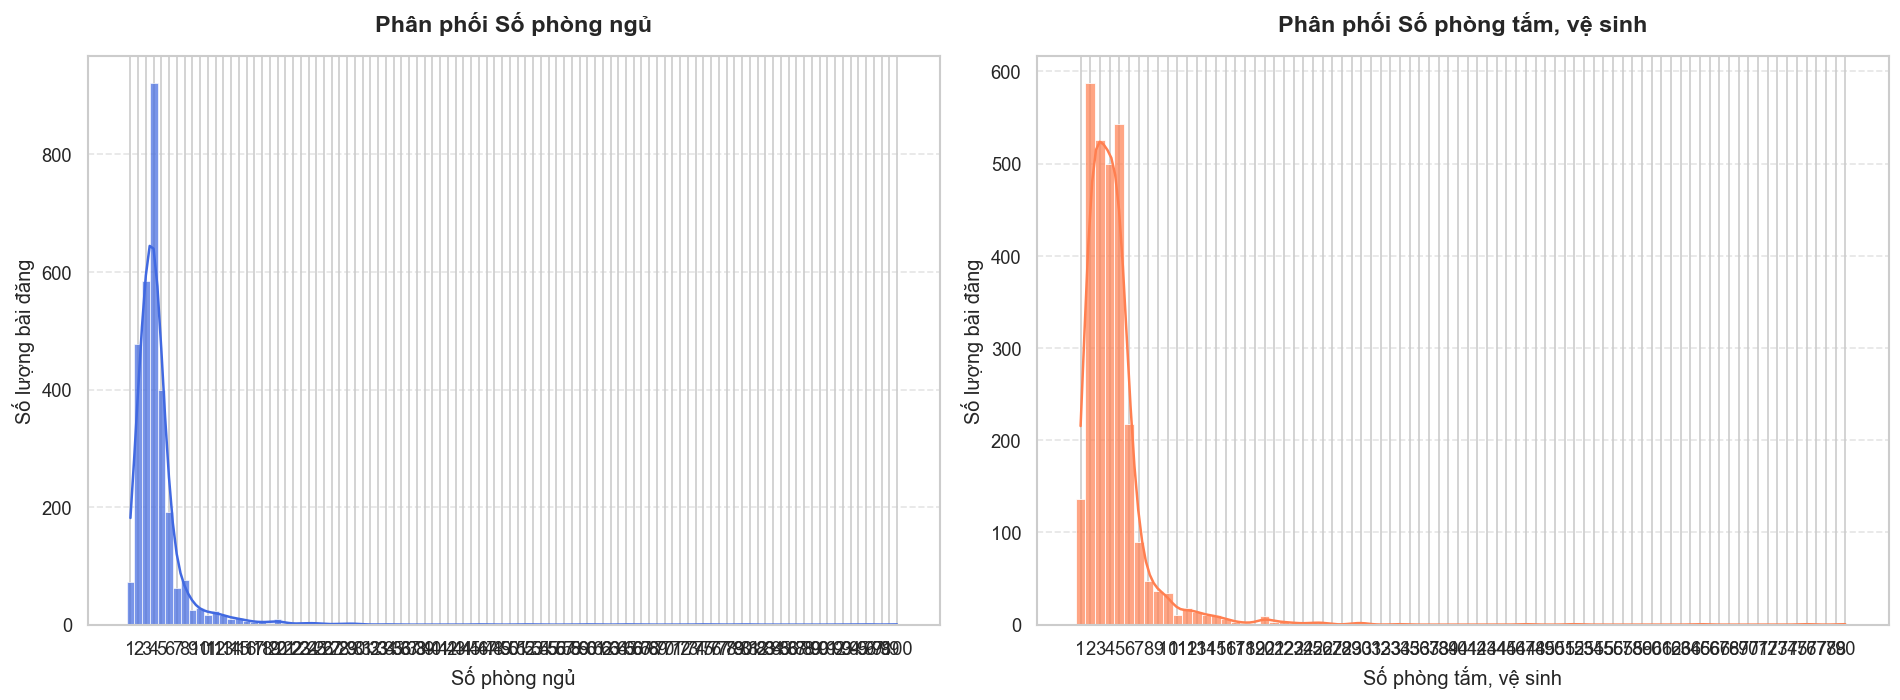

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: Phân phối Số phòng ngủ ---
so_phong_ngu_clean = df['Số phòng ngủ'].dropna()

sns.histplot(
    so_phong_ngu_clean, 
    discrete=True, kde=True, 
    color='royalblue', edgecolor='white', alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Phân phối Số phòng ngủ', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Số phòng ngủ', fontsize=12)
axes[0].set_ylabel('Số lượng bài đăng', fontsize=12)

min_pn, max_pn = int(so_phong_ngu_clean.min()), int(so_phong_ngu_clean.max())
# ✅ Tự động chọn step: mỗi nhãn cách nhau ít nhất ~1.5 đơn vị/inch
step_pn = max(1, (max_pn - min_pn) // 15)
axes[0].set_xticks(range(min_pn, max_pn + 1, step_pn))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: Phân phối Số phòng tắm, vệ sinh ---
so_phong_tam_clean = df['Số phòng tắm, vệ sinh'].dropna()

sns.histplot(
    so_phong_tam_clean, 
    discrete=True, kde=True, 
    color='coral', edgecolor='white', alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Phân phối Số phòng tắm, vệ sinh', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Số phòng tắm, vệ sinh', fontsize=12)
axes[1].set_ylabel('Số lượng bài đăng', fontsize=12)

min_pt, max_pt = int(so_phong_tam_clean.min()), int(so_phong_tam_clean.max())
# ✅ Cùng công thức step tự động
step_pt = max(1, (max_pt - min_pt) // 15)
axes[1].set_xticks(range(min_pt, max_pt + 1, step_pt))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Phát hiện outlier nghiêm trọng

In ra các outlier

In [ ]:
# 1. Đặt lại ngưỡng như lúc nãy (bạn có thể thay đổi số này nếu muốn)
MAX_ROOMS = 15

# 2. Tạo điều kiện lọc (Filter):
# Lấy những dòng có Số phòng ngủ LỚN HƠN 15 HOẶC Số phòng tắm LỚN HƠN 15
condition = (df['Số phòng ngủ'] > MAX_ROOMS) | (df['Số phòng tắm, vệ sinh'] > MAX_ROOMS)

# Lọc ra tập dữ liệu chứa toàn outliers
outliers_df = df[condition]

# 3. Chọn các cột quan trọng để hiển thị cho đỡ rối mắt
# (Chỉ chọn những cột nào thực sự tồn tại trong DataFrame của bạn)
cols_to_show = [
    'Link', 'Diện tích', 'Khoảng giá', 'Số tầng', 
    'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Nội thất', 'Pháp lý'
]
cols_to_show = [col for col in cols_to_show if col in outliers_df.columns]

# 4. Sắp xếp dữ liệu giảm dần theo "Số phòng ngủ" để xem các giá trị cực đoan nhất
outliers_df_sorted = outliers_df.sort_values(by='Số phòng ngủ', ascending=False)

# 5. In kết quả ra màn hình
print(f"🚨 TỔNG SỐ MẪU NGOẠI LAI TÌM THẤY: {len(outliers_df_sorted)} bài đăng\n")
print("-" * 50)

# Dùng display() nếu bạn đang dùng Jupyter Notebook / Google Colab để bảng hiện ra đẹp hơn
# Nếu dùng IDE bình thường (VSCode, PyCharm), bạn có thể đổi thành print()
try:
    display(outliers_df_sorted[cols_to_show].head(50)) # In 50 dòng đầu tiên
except NameError:
    print(outliers_df_sorted[cols_to_show].head(50))

🚨 TỔNG SỐ MẪU NGOẠI LAI TÌM THẤY: 60 bài đăng

--------------------------------------------------


,Link,Diện tích,Khoảng giá,Số tầng,Số phòng ngủ,"Số phòng tắm, vệ sinh",Nội thất,Pháp lý
3316,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,228.000,75.00,10.0,100.0,NaN,Đầy đủ,Sổ hồng
3284,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,1.144,140.00,NaN,96.0,NaN,NaN,Sổ hồng
1844,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,592.000,135.00,8.0,93.0,NaN,Đầy đủ,Sổ hồng
2708,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,300.000,48.00,5.0,80.0,80.0,NaN,Sổ hồng
1793,https://batdongsan.com.vn/ban-nha-rieng-duong-...,198.000,50.00,8.0,75.0,76.0,Đầy đủ,Sổ hồng
1604,https://batdongsan.com.vn/ban-nha-rieng-duong-...,309.000,35.00,7.0,65.0,65.0,NaN,Sổ hồng
115,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,337.000,600.00,11.0,60.0,NaN,NaN,Sổ hồng
1346,https://batdongsan.com.vn/ban-nha-rieng-duong-...,182.000,33.90,7.0,52.0,52.0,NaN,Sổ hồng
210,https://batdongsan.com.vn/ban-nha-mat-pho-phuo...,310.000,49.00,6.0,46.0,47.0,Đầy đủ,Sổ hồng
957,https://batdongsan.com.vn/ban-nha-rieng-duong-...,402.000,32.00,4.0,34.0,34.0,Cơ bản,Sổ hồng


Các outlier này là một giá trị quan trọng chứ không phải lỗi nhập liệu. Đó là các tin đăng rao bán cả toà nhà gần 10 tầng nên có thể lên đến 100 phòng ngủ

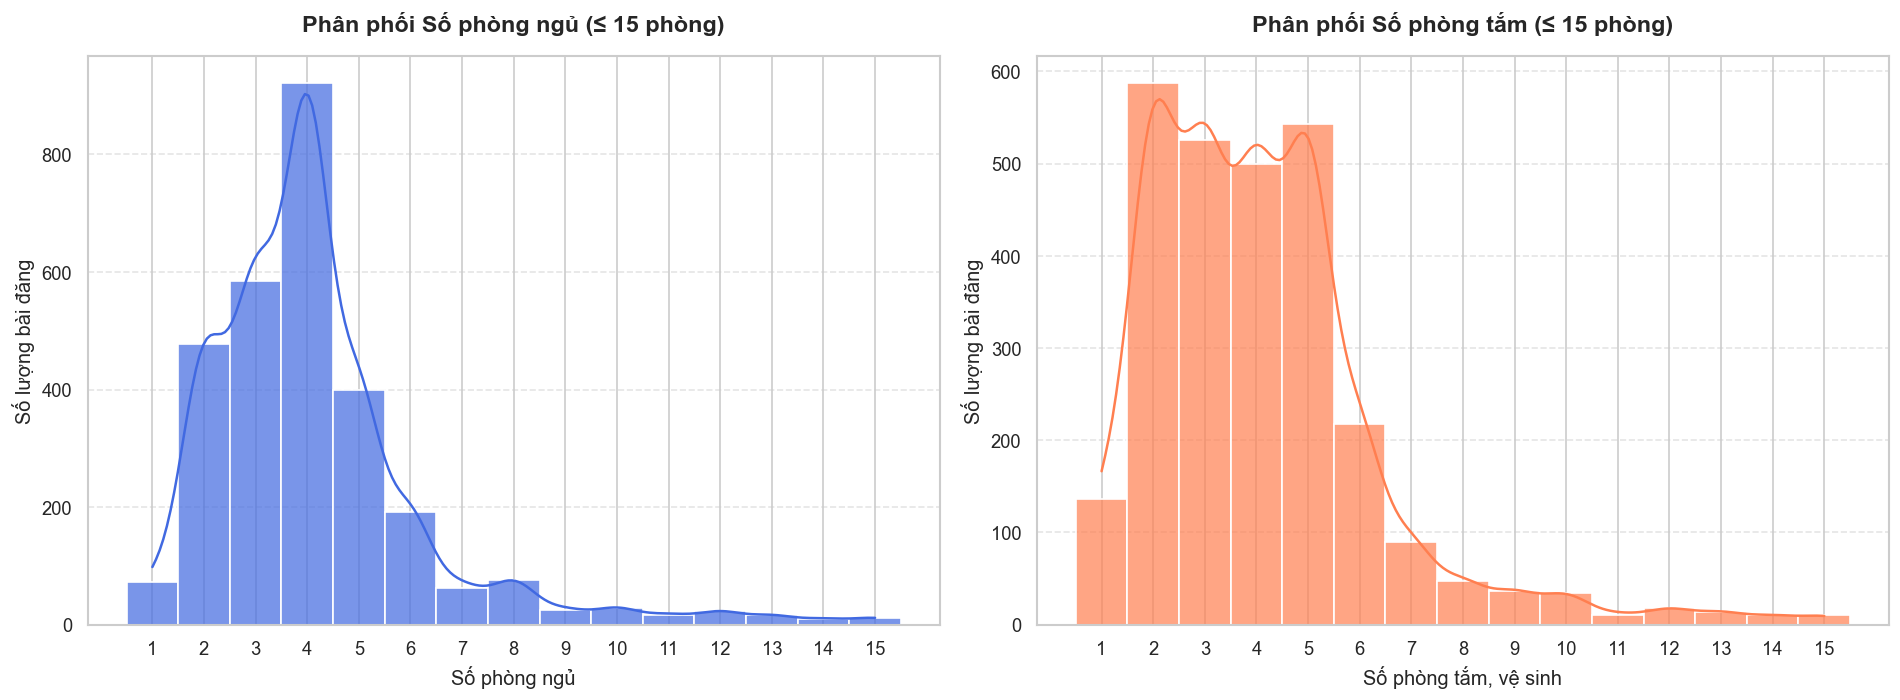

Cảnh báo: Có 56 bài đăng có số phòng ngủ lớn hơn 15.
Cảnh báo: Có 45 bài đăng có số phòng tắm lớn hơn 15.


In [ ]:
# Khởi tạo khung hình
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đặt ngưỡng tối đa để loại bỏ nhiễu hiển thị (outliers) - ví dụ: 15 phòng
MAX_ROOMS = 15

# --- BIỂU ĐỒ 1: Phân phối Số phòng ngủ ---
# Chỉ lấy những căn có số phòng <= MAX_ROOMS để vẽ
so_phong_ngu_clean = df[df['Số phòng ngủ'] <= MAX_ROOMS]['Số phòng ngủ'].dropna()

sns.histplot(
    so_phong_ngu_clean, 
    discrete=True, 
    kde=True, 
    color='royalblue', 
    edgecolor='white',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title(f'Phân phối Số phòng ngủ (≤ {MAX_ROOMS} phòng)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Số phòng ngủ', fontsize=12)
axes[0].set_ylabel('Số lượng bài đăng', fontsize=12)
axes[0].set_xticks(range(int(so_phong_ngu_clean.min()), int(so_phong_ngu_clean.max()) + 1))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: Phân phối Số phòng tắm, vệ sinh ---
# Chỉ lấy những căn có số phòng <= MAX_ROOMS để vẽ
so_phong_tam_clean = df[df['Số phòng tắm, vệ sinh'] <= MAX_ROOMS]['Số phòng tắm, vệ sinh'].dropna()

sns.histplot(
    so_phong_tam_clean, 
    discrete=True, 
    kde=True, 
    color='coral', 
    edgecolor='white',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title(f'Phân phối Số phòng tắm (≤ {MAX_ROOMS} phòng)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Số phòng tắm, vệ sinh', fontsize=12)
axes[1].set_ylabel('Số lượng bài đăng', fontsize=12)
axes[1].set_xticks(range(int(so_phong_tam_clean.min()), int(so_phong_tam_clean.max()) + 1))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# In ra màn hình cảnh báo số lượng các dòng dữ liệu bị nghi ngờ là lỗi
outliers_ngu = df[df['Số phòng ngủ'] > MAX_ROOMS].shape[0]
outliers_tam = df[df['Số phòng tắm, vệ sinh'] > MAX_ROOMS].shape[0]
print(f"Cảnh báo: Có {outliers_ngu} bài đăng có số phòng ngủ lớn hơn {MAX_ROOMS}.")
print(f"Cảnh báo: Có {outliers_tam} bài đăng có số phòng tắm lớn hơn {MAX_ROOMS}.")

In [ ]:
# 1. Chọn 2 cột cần thống kê
cols_to_describe = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh']

# Kiểm tra các cột tồn tại để tránh lỗi
cols_exist = [col for col in cols_to_describe if col in df.columns]

if len(cols_exist) > 0:
    # 2. Sử dụng describe() với các mốc phân vị để xem phần "đuôi" dữ liệu
    stats_df = df[cols_exist].describe(percentiles=[.25, .50, .75, .90, .95, .99])
    
    # 3. Tính Median (Trung vị) tường minh
    median_df = df[cols_exist].median()
    median_df.name = 'median'
    
    # 4. Tính Mode (Giá trị xuất hiện nhiều nhất)
    mode_df = df[cols_exist].mode().iloc[0]
    mode_df.name = 'mode'
    
    # 5. Gộp cả Median và Mode vào cuối bảng thống kê
    stats_df = pd.concat([stats_df, median_df.to_frame().T, mode_df.to_frame().T])
    
    # 6. Hiển thị bảng kết quả
    print("BẢNG THỐNG KÊ MÔ TẢ CHI TIẾT:\n" + "-"*40)
    
    try:
        display(stats_df.round(2))
    except NameError:
        print(stats_df.round(2))
else:
    print("Không tìm thấy các cột yêu cầu trong DataFrame.")

BẢNG THỐNG KÊ MÔ TẢ CHI TIẾT:
----------------------------------------


,Số phòng ngủ,"Số phòng tắm, vệ sinh"
count,2973.00,2824.00
mean,4.65,4.45
std,5.02,4.02
min,1.00,1.00
25%,3.00,2.00
50%,4.00,4.00
75%,5.00,5.00
90%,7.00,7.00
95%,10.00,9.85
99%,20.00,20.00


- Tỉ lệ bản ghi bị thiếu cao (15-20%).

- Tuộc tính này tương quan cao với các thuôc tính như: 'Khoảng giá' và 'Diện tích' -> MAR.

- Số lượng missing ở cột này cũng có tương quan cao với các cột khác.

- Sử dụng các mô hình học máy để điền khuyết. 'Khoảng giá' và 'Diện tích' là 2 biến liên tục nên có thể dùng KNN hoặc MICE để điền.

- Đặc biệt: Việc missing 'Số tầng' không tương quan tới các thuộc tính khác -> MCAR, nhưng giá trị của số tầng lại tương quan mạnh với 'Số phòng ngủ' và 'Số phòng tắm, vệ sinh'. Vì vậy việc dự đoán 2 cột này trước sẽ làm tiền đề để sự đoán cột số tầng về sau.


### 2.2.1 Xử lý thuộc tính 'Số phòng ngủ'

#### 2.2.1.1 Phương án 1: điền khuyết bằng KNN.

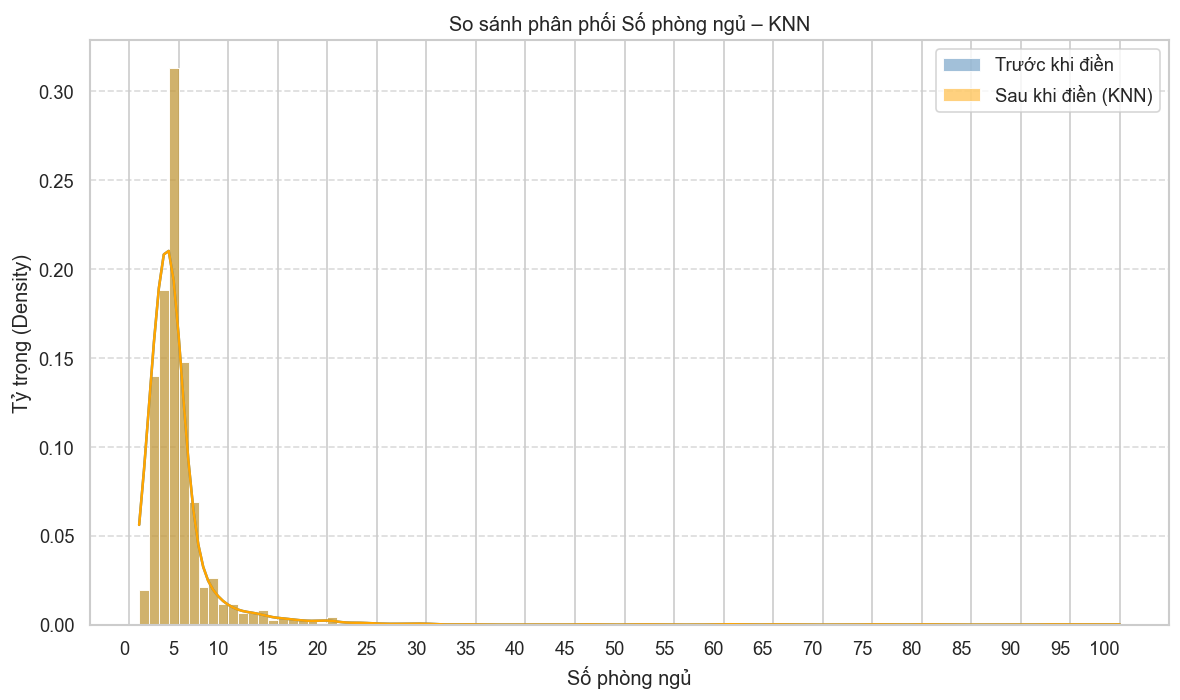

Lưu ý: chưa ghi đè X_train, xem kết quả rồi quyết định ở cell tiếp theo.


In [ ]:
# ── Điền khuyết Số phòng ngủ bằng KNN (index-safe) ──────────────────────────
features_knn_pn = ['Diện tích', 'Số phòng ngủ']

X_train_sub = X_train[features_knn_pn].copy()

scaler_pn = MinMaxScaler()
X_train_scaled_arr = scaler_pn.fit_transform(X_train_sub)
X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=features_knn_pn, index=X_train.index)

knn_imputer_pn = KNNImputer(n_neighbors=5)
X_train_imp_arr = knn_imputer_pn.fit_transform(X_train_scaled)
X_train_imputed = pd.DataFrame(
    scaler_pn.inverse_transform(X_train_imp_arr),
    columns=features_knn_pn,
    index=X_train.index
)

phong_ngu_sau_khi_dien_knn = np.round(X_train_imputed['Số phòng ngủ']).astype(int)

# ── Biểu đồ so sánh phân phối ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.histplot(X_train['Số phòng ngủ'].dropna(), color='steelblue',
             label='Trước khi điền', stat='density', alpha=0.5, binwidth=1, kde=True)
sns.histplot(phong_ngu_sau_khi_dien_knn, color='orange',
             label='Sau khi điền (KNN)', stat='density', alpha=0.5, binwidth=1, kde=True)

plt.title('So sánh phân phối Số phòng ngủ – KNN')
plt.xlabel('Số phòng ngủ')
plt.ylabel('Tỷ trọng (Density)')

max_val = phong_ngu_sau_khi_dien_knn.max()

# ✅ FIX trục X: step=2 nếu nhiều giá trị, xoay 45°
step = 5 if max_val > 20 else 1
plt.xticks(
    ticks=np.arange(0, max_val + 1, step=step),
    rotation=0 if max_val > 20 else 0,
    ha='right' if max_val > 20 else 'center'
)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Lưu ý: chưa ghi đè X_train, xem kết quả rồi quyết định ở cell tiếp theo.")

- Phân phối dữ liệu sau khi dự đoán bằng KNN trùng khớp với phân phối trước khi điền khuyết. Mô hình KNN cho kết qủa tốt.

### 2.2.1.2 Phương án 2: dùng MICE (dùng Random Forest) điền khuyết

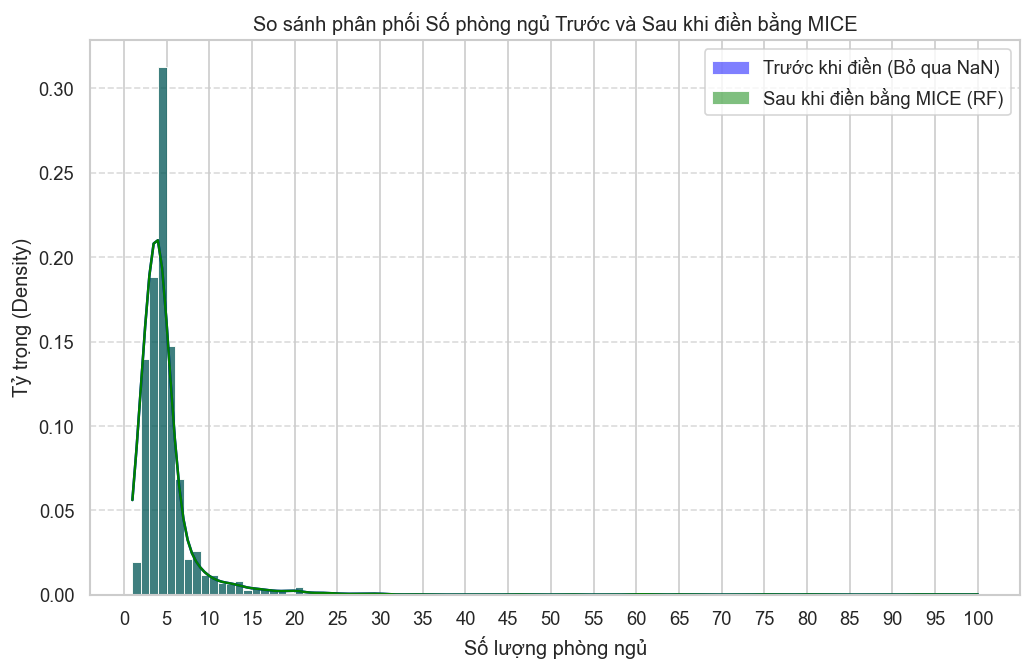

In [ ]:
# Import bắt buộc cho MICE trong sklearn

# 1. Chọn các cột liên quan
features_to_use = ['Diện tích', 'Số phòng ngủ']
X_train_sub = X_train[features_to_use].copy()

# 2. Khởi tạo MICE imputer với Random Forest
# Lưu ý: Chạy Random Forest có thể tốn thời gian hơn KNN một chút nếu tập dữ liệu lớn
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
    max_iter=10,
    random_state=42 # Cố định random_state để kết quả không đổi qua các lần chạy
)

# Điền khuyết (Không cần dùng MinMaxScaler)
X_train_imputed = pd.DataFrame(mice_imputer.fit_transform(X_train_sub), columns=features_to_use, index=X_train.index)

# 3. Làm tròn kết quả về số nguyên và LƯU TẠM
phong_ngu_sau_khi_dien_mice = np.round(X_train_imputed['Số phòng ngủ']).astype(int)

# ==========================================
# 4. VẼ BIỂU ĐỒ SO SÁNH PHÂN PHỐI (MICE)
# ==========================================
plt.figure(figsize=(10, 6))

# Vẽ dữ liệu GỐC (màu xanh dương) - Bỏ qua NaN
sns.histplot(X_train['Số phòng ngủ'].dropna(), color='blue', label='Trước khi điền (Bỏ qua NaN)', 
             stat='density', alpha=0.5, binwidth=1, kde=True)

# Vẽ dữ liệu SAU KHI ĐIỀN bằng MICE (màu xanh lá)
sns.histplot(phong_ngu_sau_khi_dien_mice, color='green', label='Sau khi điền bằng MICE (RF)', 
             stat='density', alpha=0.5, binwidth=1, kde=True)

# Cấu hình biểu đồ
plt.title('So sánh phân phối Số phòng ngủ Trước và Sau khi điền bằng MICE')
plt.xlabel('Số lượng phòng ngủ')
plt.ylabel('Tỷ trọng (Density)')
plt.xticks(np.arange(0, phong_ngu_sau_khi_dien_mice.max() + 1, step=5)) # Rút vạch chia về số nguyên
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 5. QUYẾT ĐỊNH ÁP DỤNG
# ==========================================
# Sau khi chạy cả code KNN và code MICE này, bạn so sánh 2 biểu đồ.
# Phương pháp nào có đường KDE tiệm cận với đường màu xanh dương ban đầu nhất thì chọn.
# Nếu chọn MICE, hãy bỏ comment (#) dòng dưới đây:

# X_train['Số phòng ngủ'] = phong_ngu_sau_khi_dien_mice

- Phân phối dữ liệu sau khi dự đoán bằng MICE(dùng Random Forest) trùng khớp với phân phối trước khi điền khuyết. Mô hình MICE cho kết qủa tốt.

Điền bằng MICE (2 phương pháp có hiệu suất như nhau)

In [ ]:
X_train['Số phòng ngủ'] = phong_ngu_sau_khi_dien_mice

Áp dụng lên test

In [ ]:
# 1. Chọn 3 cột tương ứng trên tập Test
features_to_use_pn = ['Diện tích', 'Số phòng ngủ']
X_test_sub = X_test[features_to_use_pn].copy()

# 2. Dùng TRANSFORM (không dùng fit_transform) với mice_imputer
X_test_imputed = pd.DataFrame(
    mice_imputer.transform(X_test_sub), 
    columns=features_to_use_pn, 
    index=X_test.index
)

# 3. Chốt kết quả vào X_test
X_test['Số phòng ngủ'] = np.round(X_test_imputed['Số phòng ngủ']).astype(int)

In [ ]:
print("=== KIỂM TRA SỐ PHÒNG NGỦ SAU KHI ĐIỀN BẰNG MICE (X_test) ===")
print(f"Số lượng giá trị NaN còn lại trong cột Số phòng ngủ: {X_test['Số phòng ngủ'].isnull().sum()}")

preview_cols = [c for c in ['Diện tích', 'Số phòng ngủ'] if c in X_test.columns]
preview_test = X_test[preview_cols].copy()
preview_test['Khoảng giá'] = y_test
print("\n5 dòng đầu tiên của các biến liên quan trong X_test:")
display(preview_test.head())


=== KIỂM TRA SỐ PHÒNG NGỦ SAU KHI ĐIỀN BẰNG MICE (X_test) ===
Số lượng giá trị NaN còn lại trong cột Số phòng ngủ: 0

5 dòng đầu tiên của các biến liên quan trong X_test:


,Diện tích,Số phòng ngủ,Khoảng giá
2457,65.0,4,6.28
70,33.0,3,4.80
358,41.0,4,8.60
325,68.0,4,15.40
2208,51.0,2,6.10


# 2.2.2.1 Xử lý thuộc tính 'Số phòng tắm/vệ sinh'

Tận dụng thuộc tính 'Số phòng ngủ' đã được dự đoán ở bước trước để nội suy 'Số phòng tắm, vệ sinh'.

#### 2.2.2.1 Phương án 1: điền khuyết bằng KNN.

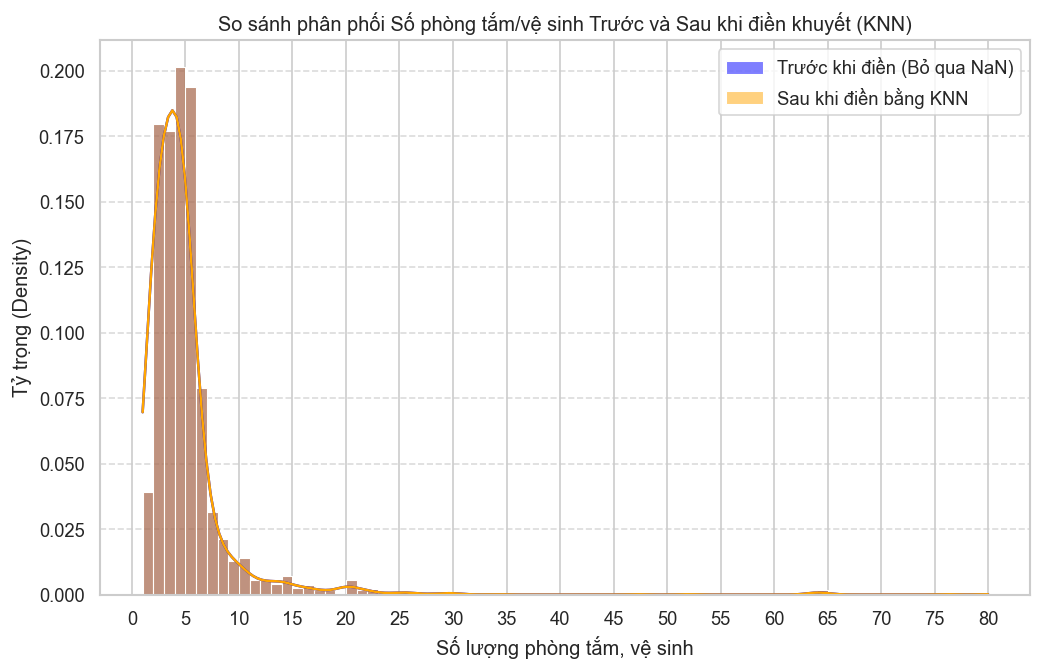

In [ ]:
# 1. Chọn các cột liên quan (Đưa thêm 'Số phòng ngủ' đã lấp đầy vào để tăng độ chính xác)
features_to_use = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_train_sub = X_train[features_to_use].copy()

# 2. Scale dữ liệu
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sub), columns=features_to_use)

# 3. Điền khuyết bằng KNN
knn_imputer = KNNImputer(n_neighbors=5)
X_train_imputed_scaled = knn_imputer.fit_transform(X_train_scaled)

# 4. Nghịch đảo scale để lấy lại đơn vị gốc
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed_scaled), columns=features_to_use, index=X_train.index)

# 5. Làm tròn cột Số phòng tắm, vệ sinh về số nguyên và LƯU TẠM
phong_tam_sau_khi_dien_knn = np.round(X_train_imputed['Số phòng tắm, vệ sinh']).astype(int)

# ==========================================
# 6. VẼ BIỂU ĐỒ SO SÁNH PHÂN PHỐI (KNN)
# ==========================================
plt.figure(figsize=(10, 6))

# Vẽ dữ liệu GỐC (màu xanh dương)
sns.histplot(X_train['Số phòng tắm, vệ sinh'].dropna(), color='blue', label='Trước khi điền (Bỏ qua NaN)', 
             stat='density', alpha=0.5, binwidth=1, kde=True)

# Vẽ dữ liệu SAU KHI ĐIỀN (màu cam)
sns.histplot(phong_tam_sau_khi_dien_knn, color='orange', label='Sau khi điền bằng KNN', 
             stat='density', alpha=0.5, binwidth=1, kde=True)

plt.title('So sánh phân phối Số phòng tắm/vệ sinh Trước và Sau khi điền khuyết (KNN)')
plt.xlabel('Số lượng phòng tắm, vệ sinh')
plt.ylabel('Tỷ trọng (Density)')
plt.xticks(np.arange(0, phong_tam_sau_khi_dien_knn.max() + 1, step=5))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2.2.2.2 Phương án 2: dùng MICE (dùng Random Forest) điền khuyết

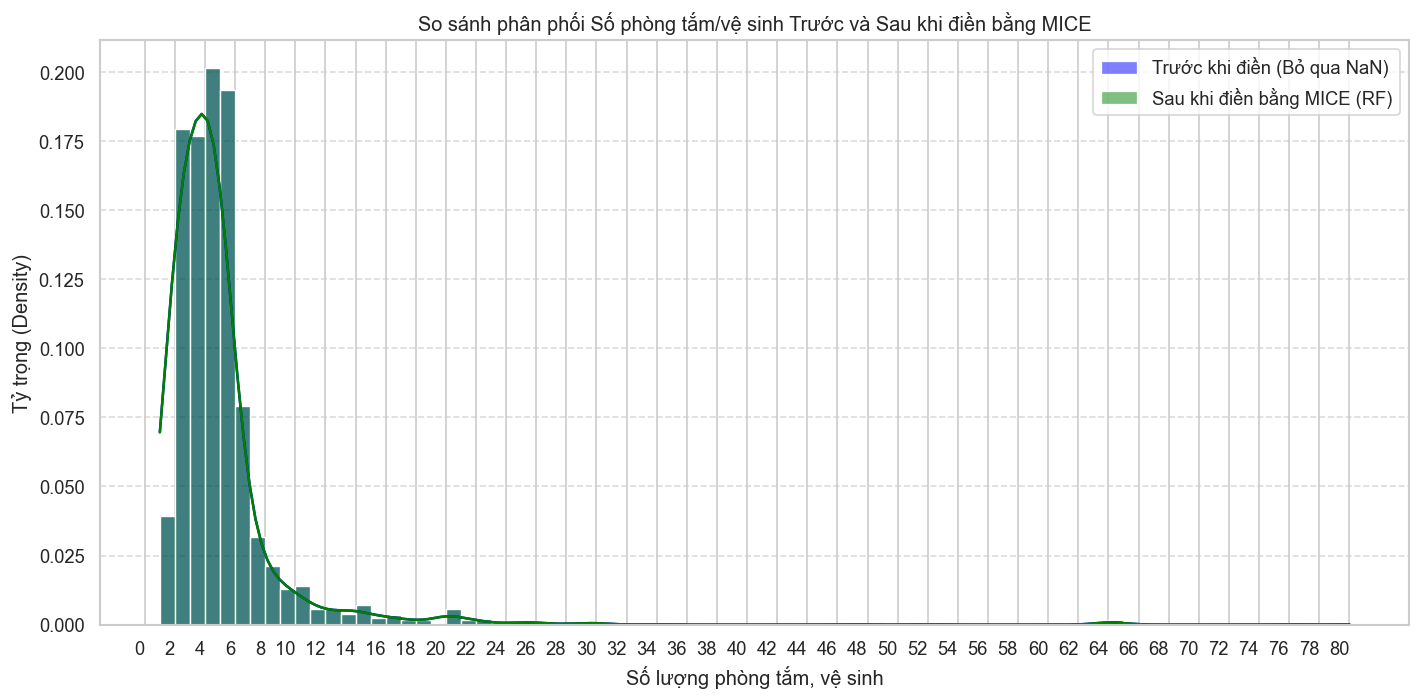

In [ ]:
# 1. Chọn các cột liên quan
features_to_use = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_train_sub = X_train[features_to_use].copy()

# 2. Khởi tạo MICE imputer với Random Forest
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
    max_iter=10,
    random_state=42 
)

X_train_imputed = pd.DataFrame(mice_imputer.fit_transform(X_train_sub), columns=features_to_use, index=X_train.index)

# 3. Làm tròn kết quả về số nguyên
phong_tam_sau_khi_dien_mice = np.round(X_train_imputed['Số phòng tắm, vệ sinh']).astype(int)

# ==========================================
# 4. VẼ BIỂU ĐỒ SO SÁNH PHÂN PHỐI (MICE)
# ==========================================
plt.figure(figsize=(12, 6))

sns.histplot(X_train['Số phòng tắm, vệ sinh'].dropna(), color='blue', label='Trước khi điền (Bỏ qua NaN)', 
             stat='density', alpha=0.5, binwidth=1, kde=True)

sns.histplot(phong_tam_sau_khi_dien_mice, color='green', label='Sau khi điền bằng MICE (RF)', 
             stat='density', alpha=0.5, binwidth=1, kde=True)

plt.title('So sánh phân phối Số phòng tắm/vệ sinh Trước và Sau khi điền bằng MICE')
plt.xlabel('Số lượng phòng tắm, vệ sinh')
plt.ylabel('Tỷ trọng (Density)')

max_val = phong_tam_sau_khi_dien_mice.max()

# ✅ FIX: Tăng step lên 2 (hoặc 5) và xoay nhãn 45°
plt.xticks(
    ticks=np.arange(0, max_val + 1, step=2),   # Bước nhảy = 2
    rotation=0,
    ha='right'
)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Tránh bị cắt nhãn
plt.show()

2 phương pháp điền khuyết có hiệu suất tương đương nhau.

In [ ]:
X_train['Số phòng tắm, vệ sinh'] = phong_tam_sau_khi_dien_knn

Áp dụng lên tập test

In [ ]:
# 1. Chọn 4 cột trên tập Test (Lúc này 'Số phòng ngủ' trên X_test đã được điền đầy đủ từ Cell Mới Số 1)
features_to_use_pt = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_test_sub = X_test[features_to_use_pt].copy()

# Fit scaler riêng cho 3 features (không tái dùng scaler cũ fit trên 2 features)
scaler_pt = MinMaxScaler()
X_train_sub_pt = X_train[features_to_use_pt].copy()
X_train_scaled_pt = pd.DataFrame(
    scaler_pt.fit_transform(X_train_sub_pt),
    columns=features_to_use_pt,
    index=X_train.index
)
knn_imputer_pt = KNNImputer(n_neighbors=5)
knn_imputer_pt.fit(X_train_scaled_pt)

# Áp dụng lên test
X_test_scaled = pd.DataFrame(
    scaler_pt.transform(X_test_sub),
    columns=features_to_use_pt,
    index=X_test.index
)
X_test_imputed_scaled = knn_imputer_pt.transform(X_test_scaled)

# 4. Nghịch đảo scale
X_test_imputed = pd.DataFrame(
    scaler_pt.inverse_transform(X_test_imputed_scaled), 
    columns=features_to_use_pt, 
    index=X_test.index
)

# 5. Chốt kết quả vào X_test
X_test['Số phòng tắm, vệ sinh'] = np.round(X_test_imputed['Số phòng tắm, vệ sinh']).astype(int)

In [ ]:
print("=== KIỂM TRA SỐ PHÒNG TẮM SAU KHI ĐIỀN BẰNG KNN (X_test) ===")
print(f"Số lượng giá trị NaN còn lại trong cột Số phòng tắm, vệ sinh: {X_test['Số phòng tắm, vệ sinh'].isnull().sum()}")
print("\n5 dòng đầu tiên của Số phòng ngủ & Số phòng tắm trong X_test:")
display(X_test[['Số phòng ngủ', 'Số phòng tắm, vệ sinh']].head())

=== KIỂM TRA SỐ PHÒNG TẮM SAU KHI ĐIỀN BẰNG KNN (X_test) ===
Số lượng giá trị NaN còn lại trong cột Số phòng tắm, vệ sinh: 0

5 dòng đầu tiên của Số phòng ngủ & Số phòng tắm trong X_test:


,Số phòng ngủ,"Số phòng tắm, vệ sinh"
2457,4,4
70,3,3
358,4,3
325,4,5
2208,2,2


### 2.2.3 Kiểm tra lại mối quan hệ tương quan sau khi điền khuyết.

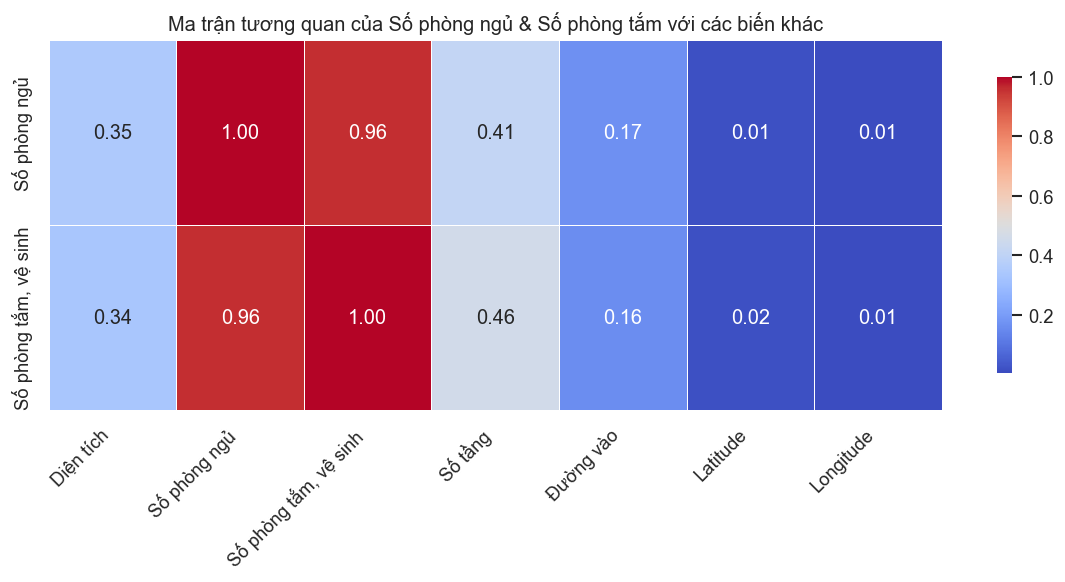

In [ ]:
# 1. Lọc ra các cột dạng số (Numerical) để tính tương quan
# Tránh đưa các cột dạng chữ (Categorical) vào hàm corr() gây lỗi
numeric_cols = X_train.select_dtypes(include=['float64', 'int64', 'int32']).columns

# 2. Tính ma trận tương quan (Pearson) cho các biến số
correlation_matrix = X_train[numeric_cols].corr()

# 3. Lọc riêng phần tương quan của 2 biến quan tâm với các biến còn lại để dễ nhìn
target_vars = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh']
# Kiểm tra xem 2 cột này có nằm trong list numeric_cols không
target_vars = [col for col in target_vars if col in correlation_matrix.columns]

if target_vars:
    target_corr = correlation_matrix.loc[target_vars, :]

    # 4. Vẽ Heatmap
    plt.figure(figsize=(12, 4))
    sns.heatmap(target_corr, 
                annot=True,       # Hiển thị số liệu trên ô
                cmap='coolwarm',  # Dải màu từ lạnh (âm) sang nóng (dương)
                fmt=".2f",        # Làm tròn 2 chữ số thập phân
                linewidths=0.5, 
                cbar_kws={"shrink": .8})
    
    plt.title('Ma trận tương quan của Số phòng ngủ & Số phòng tắm với các biến khác')
    plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X cho dễ đọc
    plt.show()
else:
    print("Vui lòng đảm bảo 'Số phòng ngủ' và 'Số phòng tắm, vệ sinh' đang ở định dạng số (int/float).")

Ma trận tương quan có sự tương đồng lớn với ma trận tương quan ban đầu. Dữ liệu điền khuyết đã không phá hỏng mối quan hệ giữa các thuộc tính. Nhà to hơn đắt tiền hơn thường có nhiều phòng hơn.

- Nhận xét: Sự sụt giảm tỷ trọng tại đỉnh phân phối sau khi điền khuyết không phải là sai số của mô hình, mà phản ánh chính xác bản chất khuyết dữ liệu có quy luật (cơ chế MAR). Do các ô trống tập trung chủ yếu ở phân khúc bất động sản diện tích lớn hoặc tòa nhà nguyên căn, mô hình dự báo đã tính toán và lấp đầy bằng các giá trị lớn tương ứng (nhiều phòng tắm). Việc này làm tăng khối lượng dữ liệu ở phần đuôi đồ thị, dẫn đến hiệu ứng toán học tự nhiên là kéo giảm tỷ trọng tương đối (density) tại phần đỉnh. Kết quả này chứng minh thuật toán đã nắm bắt đúng logic thực tế của thị trường thay vì điền khuyết một cách máy móc theo số đông.

## 2.4 Xử lý missing value ở cột 'Số tầng'

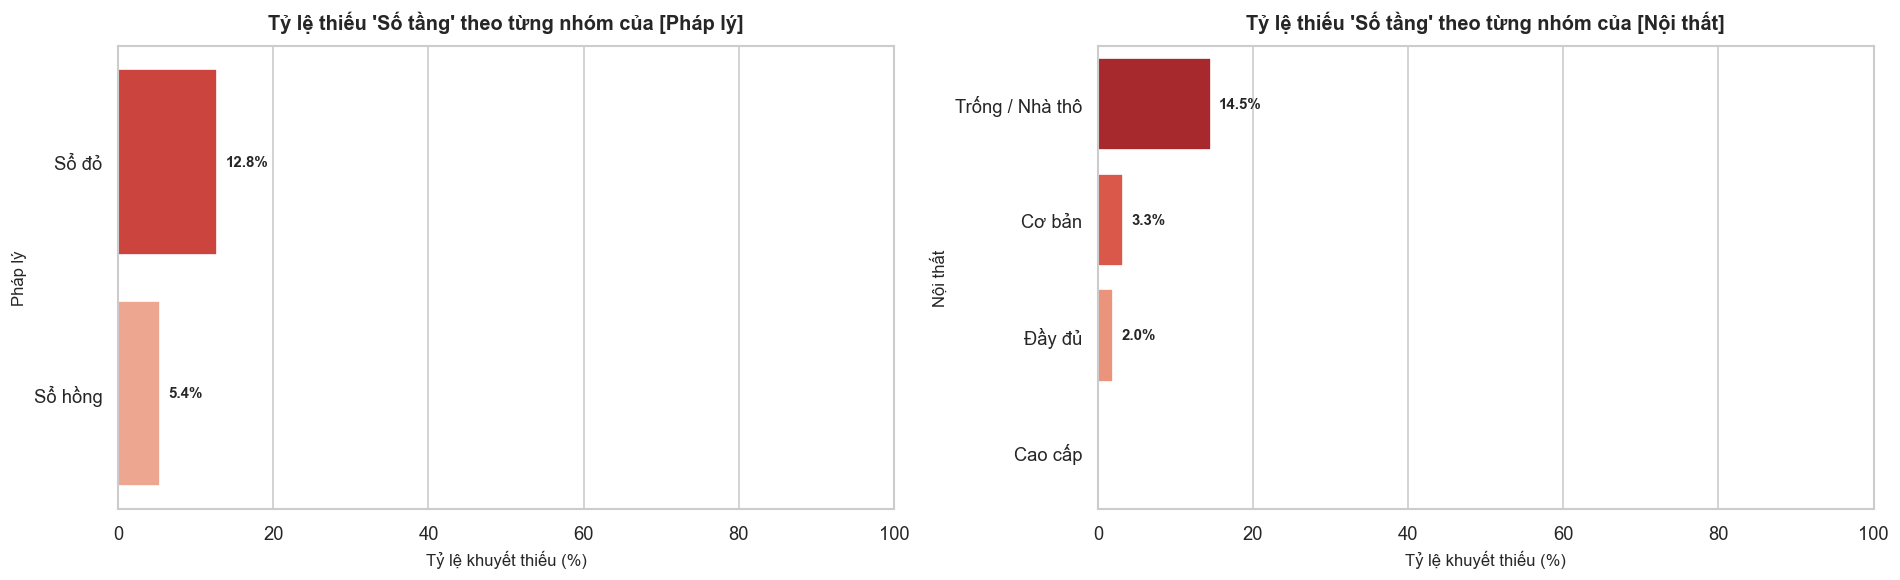

In [ ]:
# Cấu hình đồ họa nét cao và hiển thị lưới nền

# 1. Tạo một cột tạm thời: True nếu 'Số tầng' bị trống (NaN), False nếu có dữ liệu
df['_Is_So_Tang_Missing'] = df['Số tầng'].isnull()

# 2. Lựa chọn các cột danh mục tiêu biểu trong df của bạn để làm trục nhóm
# (Bỏ qua các cột định danh độc nhất như Link, hoặc quá chi tiết như Phường xã để tránh rối biểu đồ)
group_columns = ['Quan_Huyen', 'Pháp lý', 'Nội thất'] # 'Hướng nhà' đã bị drop ở bước 2.1 – bỏ qua
    # (was: 'Hướng nhà')]
group_columns = [col for col in group_columns if col in df.columns]

# 3. Khởi tạo khung lưới chứa các biểu đồ con (Subplots)
n_plots = len(group_columns)
if n_plots > 0:
    # Bố trí tối đa 2 biểu đồ trên một hàng
    nrows = (n_plots + 1) // 2
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(16, 5 * nrows))
    axes = axes.flatten()  # Biến mảng 2 chiều thành 1 chiều để lặp dễ dàng

    for i, col in enumerate(group_columns):
        # Tính tỷ lệ thiếu (%) của 'Số tầng' theo từng nhóm trong cột hiện tại
        # Hàm .mean() trên cột Boolean sẽ tự động tính: (Số lượng True / Tổng số lượng) * 100
        missing_rate = df.groupby(col)['_Is_So_Tang_Missing'].mean().reset_index()
        missing_rate['_Is_So_Tang_Missing'] *= 100  # Đổi sang đơn vị %
        
        # Sắp xếp giảm dần để phân khúc nào thiếu nhiều nhất sẽ nhảy lên đầu
        missing_rate = missing_rate.sort_values(by='_Is_So_Tang_Missing', ascending=False)

        # Vẽ biểu đồ cột ngang (Barplot)
        sns.barplot(
            data=missing_rate,
            y=col,
            x='_Is_So_Tang_Missing',
            ax=axes[i],
            palette='Reds_r',  # Màu đỏ cảnh báo mức độ thiếu dữ liệu
            hue=col,
            legend=False
        )
        
        # Tinh chỉnh tiêu đề và nhãn hiển thị
        axes[i].set_title(f"Tỷ lệ thiếu 'Số tầng' theo từng nhóm của [{col}]", fontsize=12, fontweight='bold', pad=10)
        axes[i].set_xlabel("Tỷ lệ khuyết thiếu (%)", fontsize=10)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].set_xlim(0, 100)  # Thước đo luôn chạy từ 0% đến 100% để hiển thị khách quan

        # Điền số phần trăm trực tiếp lên cạnh mỗi cột cho dễ đọc
        for p in axes[i].patches:
            width = p.get_width()
            if width > 0:  # Chỉ hiển thị nhãn nếu nhóm đó có tỷ lệ thiếu lớn hơn 0%
                axes[i].annotate(f'{width:.1f}%', 
                                 (width, p.get_y() + p.get_height() / 2.),
                                 ha='left', va='center', 
                                 xytext=(5, 0), textcoords='offset points', fontsize=9, fontweight='bold')

    # Nếu số lượng cột là số lẻ, xóa ô đồ thị trống cuối cùng đi cho đẹp đội hình
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# 4. Dọn dẹp: Xóa cột tạm thời vừa tạo để trả lại DataFrame nguyên bản sạch sẽ
df.drop(columns=['_Is_So_Tang_Missing'], inplace=True)

Cột 'Số tầng' đang thuộc loại MNAR:
- Đầy đủ" (37.73%): Chiếm đa số.
- "Trống / Nhà thô" (3.63%): Chiếm tỷ lệ rất thấp.
Mặc dù nhóm "Trống / Nhà thô" chỉ chiếm 3.63% tổng số mẫu, nhưng trước đó chúng ta đã thấy nó lại là nhóm có tỷ lệ thiếu Số tầng cao nhất (14.4%).

# 2.3.1 Thống kê phân phối và tìm outlier

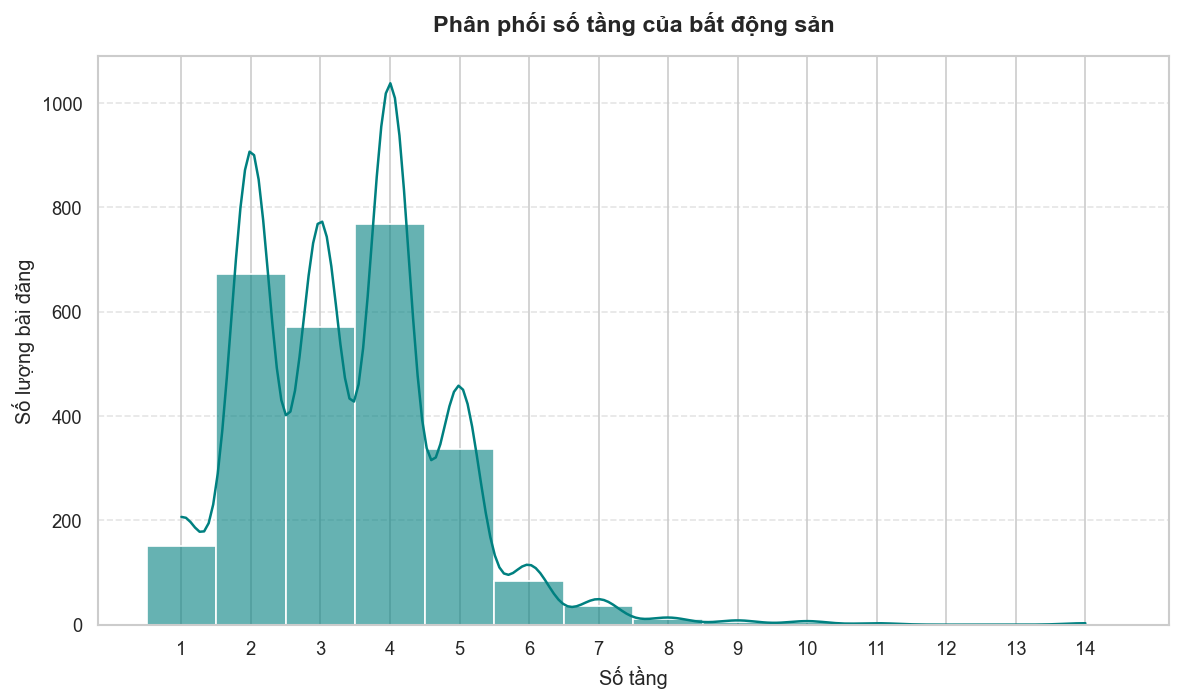

In [ ]:
# 1. Chuẩn bị dữ liệu: Loại bỏ NaN để biểu đồ không bị lỗi hiển thị
so_tang_clean = X_train['Số tầng'].dropna()  # FIX: dùng X_train thay vì df sau split

# 2. Khởi tạo biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ histogram kết hợp đường KDE để xem xu hướng phân phối
sns.histplot(
    so_tang_clean, 
    discrete=True, 
    kde=True, 
    color='teal', 
    edgecolor='white',
    alpha=0.6
)

# Thêm tiêu đề và nhãn
plt.title('Phân phối số tầng của bất động sản', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số tầng', fontsize=12)
plt.ylabel('Số lượng bài đăng', fontsize=12)

# Tùy chỉnh trục x để hiển thị rõ các số nguyên
plt.xticks(range(int(so_tang_clean.min()), int(so_tang_clean.max()) + 1))

# Thêm lưới ngang để dễ quan sát giá trị
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
so_tang_clean = X_train['Số tầng'].dropna()

Q1 = so_tang_clean.quantile(0.25)
Q3 = so_tang_clean.quantile(0.75)
IQR = Q3 - Q1
upper_bound_iqr = Q3 + 1.5 * IQR
outliers_iqr = X_train[X_train['Số tầng'] > upper_bound_iqr]

print("--- PHÁT HIỆN BẰNG PHƯƠNG PHÁP IQR ---")
print(f"Giới hạn trên về số tầng: {upper_bound_iqr} tầng")
print(f"Số lượng bản ghi bị coi là outlier: {len(outliers_iqr)} / {len(X_train)}")

threshold_99 = so_tang_clean.quantile(0.99)
outliers_extreme = X_train[X_train['Số tầng'] > threshold_99]
print("\n--- PHÁT HIỆN BẰNG PHÂN VỊ 99% ---")
print(f"Ngưỡng 99%: {threshold_99} tầng")
print(f"Số lượng bản ghi vượt ngưỡng: {len(outliers_extreme)}")

print("\n=== TOP 10 BẢN GHI CÓ SỐ TẦNG CAO NHẤT ĐỂ KIỂM TRA ===")
check_data = X_train.copy()
check_data['Khoảng giá'] = y_train
cols_to_check = ['Link', 'Diện tích', 'Khoảng giá', 'Số tầng', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
cols_to_display = [col for col in cols_to_check if col in check_data.columns]
display(check_data.sort_values(by='Số tầng', ascending=False)[cols_to_display].head(10))


--- PHÁT HIỆN BẰNG PHƯƠNG PHÁP IQR ---
Giới hạn trên về số tầng: 7.0 tầng
Số lượng bản ghi bị coi là outlier: 25 / 2814

--- PHÁT HIỆN BẰNG PHÂN VỊ 99% ---
Ngưỡng 99%: 7.0 tầng
Số lượng bản ghi vượt ngưỡng: 25

=== TOP 10 BẢN GHI CÓ SỐ TẦNG CAO NHẤT ĐỂ KIỂM TRA ===


,Link,Diện tích,Khoảng giá,Số tầng,Số phòng ngủ,"Số phòng tắm, vệ sinh"
116,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,368.0,650.0,14.0,14,16
1349,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,368.0,700.0,14.0,14,16
115,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,337.0,600.0,11.0,60,64
2648,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,204.0,238.0,11.0,7,7
1617,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,217.0,115.0,10.0,30,30
1841,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,386.0,430.0,10.0,5,5
2362,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,238.0,85.0,10.0,15,15
3316,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,228.0,75.0,10.0,100,64
477,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,386.0,450.0,10.0,5,5
996,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,293.0,145.0,9.0,18,20


Outlier này là lỗi trong quá trình thu thập dữ liệu. Xoá.

In [ ]:
# ── FIX: Tìm outlier bằng Link trực tiếp trên X_train/X_test (không qua df sau split) ──
target_link = (
    "https://batdongsan.com.vn/ban-nha-biet-thu-lien-ke-vinhomes-green-paradise"
    "-xa-can-gio-tp-ho-chi-minh/50-dau-tien-suat-noi-bo-dac-ck-20-np-bt-mat-bien"
    "-gia-tu-4-ty-lh-pr44024453?vrs=1"
)

# Tìm trên X_train trước, rồi X_test
outlier_tr = X_train[X_train.get('Link', pd.Series(dtype=str)) == target_link].index
outlier_te = X_test[X_test.get('Link', pd.Series(dtype=str)) == target_link].index

if len(outlier_tr) + len(outlier_te) > 0:
    print(f"📍 Tìm thấy tại train={list(outlier_tr)}, test={list(outlier_te)}")
    X_train = X_train.drop(index=outlier_tr, errors='ignore')
    y_train = y_train.drop(index=outlier_tr, errors='ignore')
    X_test  = X_test.drop(index=outlier_te, errors='ignore')
    y_test  = y_test.drop(index=outlier_te, errors='ignore')
    print("✅ Đã xóa outlier!")
    print(f"-> X_train: {X_train.shape}  |  X_test: {X_test.shape}")
else:
    print("ℹ️  Không tìm thấy bản ghi này (có thể đã bị xóa ở bước trước).")


ℹ️  Không tìm thấy bản ghi này (có thể đã bị xóa ở bước trước).


In [ ]:
# Tìm outlier trực tiếp trên từng tập, không qua df
outlier_indices_tr = X_train[X_train['Số tầng'] > 20].index
outlier_indices_te = X_test[X_test['Số tầng'] > 20].index

total_found = len(outlier_indices_tr) + len(outlier_indices_te)

if total_found > 0:
    print(f"📍 Tìm thấy {len(outlier_indices_tr)} outlier trong train, {len(outlier_indices_te)} trong test.")

    X_train = X_train.drop(index=outlier_indices_tr)
    y_train = y_train.drop(index=outlier_indices_tr)

    X_test = X_test.drop(index=outlier_indices_te)
    y_test = y_test.drop(index=outlier_indices_te)

    print("✅ Đã xóa thành công!")
    print(f"-> Kích thước X_train hiện tại: {X_train.shape}")
    print(f"-> Kích thước X_test hiện tại: {X_test.shape}")
else:
    print("❌ Không tìm thấy bản ghi nào có số tầng lớn hơn 20 tầng!")

❌ Không tìm thấy bản ghi nào có số tầng lớn hơn 20 tầng!


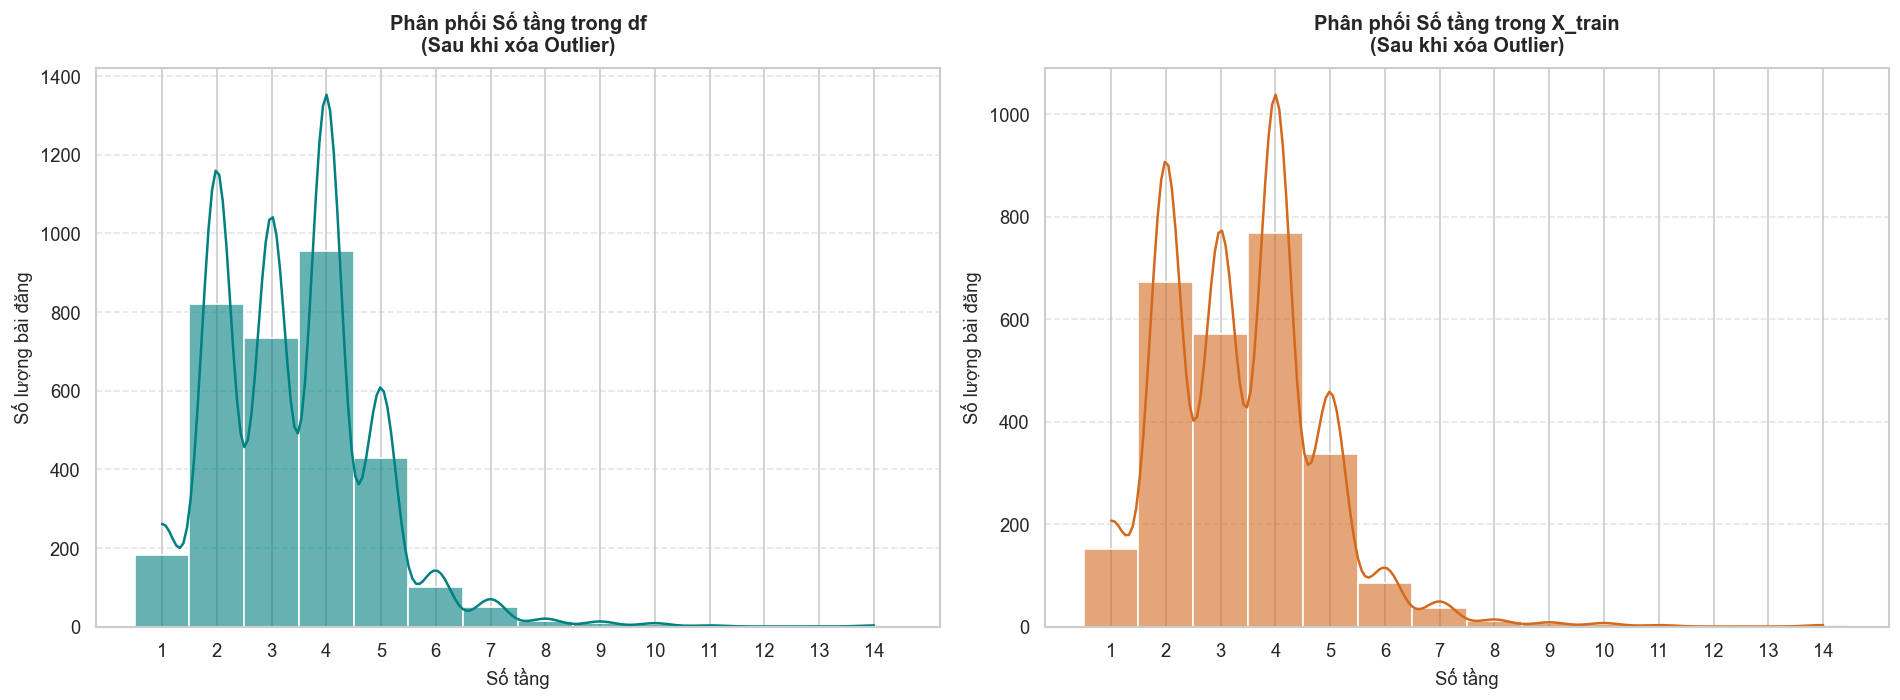

In [ ]:
# 1. Chuẩn bị dữ liệu sạch (Loại bỏ NaN để seaborn vẽ mượt mà hơn)
so_tang_df_clean = df['Số tầng'].dropna()
so_tang_train_clean = X_train['Số tầng'].dropna()

# 2. Khởi tạo khung nền gồm 2 biểu đồ nằm song song (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: PHÂN PHỐI TRÊN DF GỐC ---
sns.histplot(
    so_tang_df_clean, 
    discrete=True, 
    kde=True, 
    color='teal', 
    edgecolor='white',
    alpha=0.6,
    ax=axes[0] # Chỉ định vẽ vào ô bên trái
)
axes[0].set_title('Phân phối Số tầng trong df\n(Sau khi xóa Outlier)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Số tầng', fontsize=11)
axes[0].set_ylabel('Số lượng bài đăng', fontsize=11)
axes[0].set_xticks(range(int(so_tang_df_clean.min()), int(so_tang_df_clean.max()) + 1))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


# --- BIỂU ĐỒ 2: PHÂN PHỐI TRÊN TẬP X_TRAIN ---
sns.histplot(
    so_tang_train_clean, 
    discrete=True, 
    kde=True, 
    color='chocolate', 
    edgecolor='white',
    alpha=0.6,
    ax=axes[1] # Chỉ định vẽ vào ô bên phải
)
axes[1].set_title('Phân phối Số tầng trong X_train\n(Sau khi xóa Outlier)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Số tầng', fontsize=11)
axes[1].set_ylabel('Số lượng bài đăng', fontsize=11)
axes[1].set_xticks(range(int(so_tang_train_clean.min()), int(so_tang_train_clean.max()) + 1))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu khoảng cách giữa các biểu đồ và hiển thị
plt.tight_layout()
plt.show()

- Trong thị trường nhà phố tại các đô thị lớn như TP.HCM, phân phối số tầng thường không phải là đường cong hình chuông đều mà luôn bị chia cắt bởi 2 nhóm khách hàng/đối tượng chính:
    - Nhóm "Nhà nhỏ / Nhà hẻm" (Đỉnh ở 2 - 3 tầng): Đây thường là các căn nhà xây dựng từ lâu, nhà diện tích nhỏ (dưới 40m²), hoặc nằm sâu trong các hẻm nhỏ. Quy định xây dựng tại các hẻm này thường hạn chế chiều cao (chỉ được phép xây 2-3 tầng).
    - Nhóm "Nhà phố hiện đại" (Đỉnh ở 4 - 5 tầng): Đây là "tiêu chuẩn vàng" của nhà phố hiện nay. Thiết kế phổ biến là: 1 trệt + 1 lửng + 2 lầu + 1 sân thượng (tương đương 4-5 tầng). Những căn nhà ở mặt tiền hoặc hẻm lớn thường được phép xây dựng tối đa đến mức này để tối ưu hóa không gian.


- Ma trận tương quan của các biến cũng là một bằng chứng cho thấy số tầng chịu tác động mạnh của giá nhà, số phòng tắm và số phòng ngủ.

- Dựa vào ma trận tương quan của số lượng missing thì "Số tầng" missing không tương quan mạnh với các cột khác nên khả năng cao "Số tầng" là MCAR.

- Số lượng bản ghi bị thiếu không quá thấp (>5%)

- Với phân phối này không thể điền mean hay median vì sẽ làm mất hình dạng phân phối của dữ liệu (phân phối 2 đỉnh). Các mối tương quan cho thấy dùng mô hình nội suy đa biến sẽ có thể suy luận chính xác hơn.

- Kết luận: Sử dụng các mô hình để nội suy đa biến. 

- Chọn mô hình:
    - Dữ liệu rời rạc (số phòng tắm, số phòng ngủ), 
    - số phòng bị chia thành 2 nhóm. 
    - Dữ liệu lệch phải (do vẫn tồn tại các outlier 14 vốn là những outlier hợp lý).
- Các mô hình dựa trên nền tảng cây quyết định sẽ hiệu quả để dự đoán các mẫu này.


### 2.3.2 huấn luyện mô hình trên tập test và kiểm định 

📊 1. Trực quan hóa dữ liệu gốc bằng biểu đồ cột


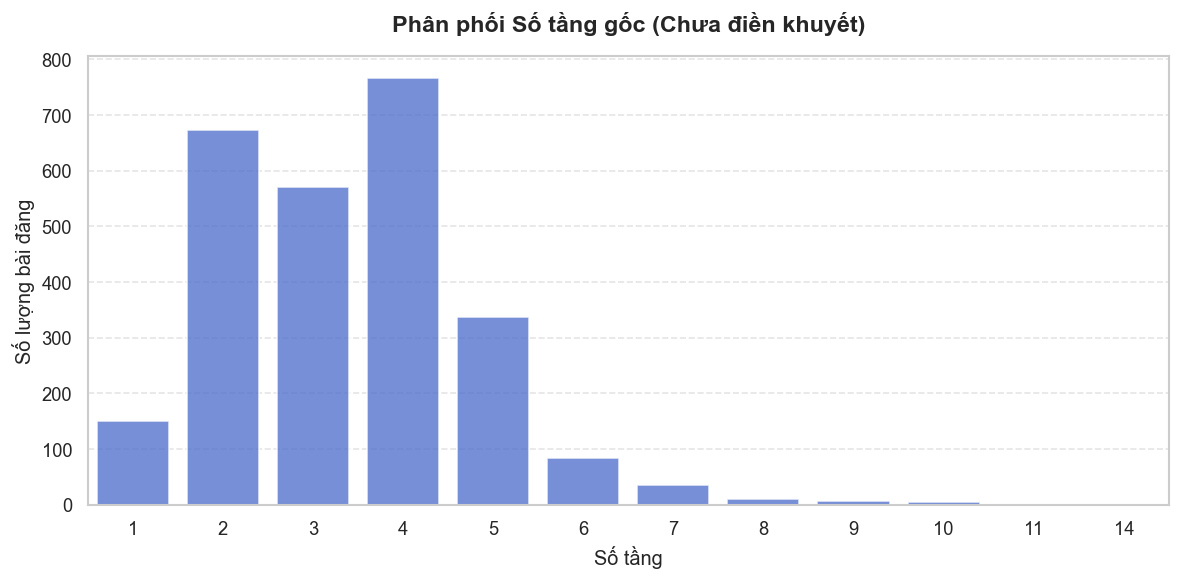


⏳ 2. Đang tiến hành chạy Random Forest Imputer. Vui lòng đợi...
✅ Hoàn tất điền khuyết! Số lượng NaN hiện tại: 0

📊 3. Đối chiếu phân phối Trước và Sau bằng Biểu đồ cột ghép (Grouped Bar Chart)


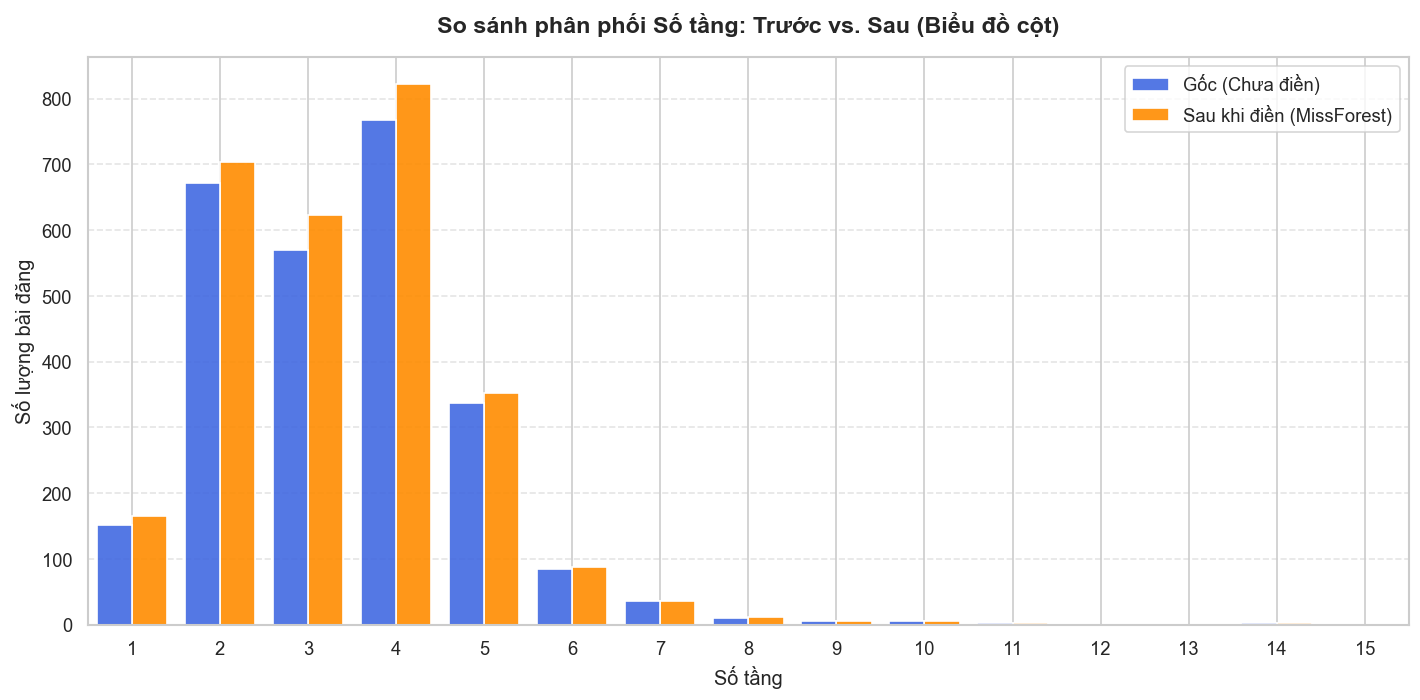

In [ ]:
# Import thư viện cần thiết cho MissForest

# =========================================================================
# BƯỚC 1: VẼ BIỂU ĐỒ CỘT DỮ LIỆU GỐC (TRƯỚC KHI ĐIỀN KHUYẾT)
# =========================================================================
print("📊 1. Trực quan hóa dữ liệu gốc bằng biểu đồ cột")
plt.figure(figsize=(10, 5))
sns.countplot(
    x=X_train['Số tầng'].dropna().astype(int), 
    color='royalblue', 
    alpha=0.8
)
plt.title('Phân phối Số tầng gốc (Chưa điền khuyết)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số tầng', fontsize=12)
plt.ylabel('Số lượng bài đăng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================================================================
# BƯỚC 2: CHUẨN BỊ DỮ LIỆU & ÁP DỤNG MISSFOREST
# =========================================================================
print("\n⏳ 2. Đang tiến hành chạy Random Forest Imputer. Vui lòng đợi...")

# Lựa chọn các đặc trưng có độ tương quan cao
features_for_rf = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']
X_train_rf = X_train[features_for_rf].copy()

# Khởi tạo mô hình
rf_estimator = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
missforest_imputer = IterativeImputer(estimator=rf_estimator, max_iter=10, random_state=42, min_value=1)

# Fit và Transform
X_train_imputed_array = missforest_imputer.fit_transform(X_train_rf)
X_train_imputed_df = pd.DataFrame(X_train_imputed_array, columns=features_for_rf, index=X_train.index)

# Làm tròn và lưu tạm vào cột mới để kiểm tra
X_train['Số tầng (MissForest)'] = np.round(X_train_imputed_df['Số tầng']).astype(int)

print("✅ Hoàn tất điền khuyết! Số lượng NaN hiện tại:", X_train['Số tầng (MissForest)'].isnull().sum())

# =========================================================================
# BƯỚC 3: VẼ BIỂU ĐỒ CỘT KÉP SO SÁNH (SAU KHI ĐIỀN KHUYẾT)
# =========================================================================
print("\n📊 3. Đối chiếu phân phối Trước và Sau bằng Biểu đồ cột ghép (Grouped Bar Chart)")
plt.figure(figsize=(12, 6))

# Gom 2 cột dữ liệu lại thành một DataFrame nhỏ để Seaborn dễ dàng vẽ cột kép
plot_data = pd.DataFrame({
    'Gốc (Chưa điền)': X_train['Số tầng'],
    'Sau khi điền (MissForest)': X_train['Số tầng (MissForest)']
})

# Vẽ biểu đồ cột ghép (dodge)
sns.histplot(
    data=plot_data,
    discrete=True,
    multiple="dodge",   # Tham số quan trọng: Tách 2 cột đứng song song
    shrink=0.8,         # Thu nhỏ chiều rộng cột để tạo khoảng trống cho dễ nhìn
    palette=['royalblue', 'darkorange'],
    alpha=0.9
)

plt.title('So sánh phân phối Số tầng: Trước vs. Sau (Biểu đồ cột)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số tầng', fontsize=12)
plt.ylabel('Số lượng bài đăng', fontsize=12)
plt.xlim(0.5, 15.5)
plt.xticks(range(1, 16))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================================================================
# CHỐT KẾT QUẢ (Chỉ chạy khi bạn đã hài lòng với biểu đồ trên)
# X_train['Số tầng'] = X_train['Số tầng (MissForest)']
# X_train = X_train.drop(columns=['Số tầng (MissForest)'])
# =========================================================================

Do mô hình tốt và số mẫu nhỏ nên phân phối khô bị lệch nhiều khi điền khuyết.

### 2.3.3 Áp dụng lên tập train và test

diền X_train

In [ ]:
X_train['Số tầng'] = X_train['Số tầng (MissForest)']
X_train = X_train.drop(columns=['Số tầng (MissForest)'])

điền X_test

In [ ]:
# 1. Trích xuất đúng danh sách các cột đã dùng để huấn luyện mô hình trước đó
features_for_rf = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']
X_test_rf = X_test[features_for_rf].copy()

# 2. ÁP DỤNG QUY TẮC VÀNG: Chỉ dùng transform(), KHÔNG dùng fit_transform()
X_test_imputed_array = missforest_imputer.transform(X_test_rf)

# 3. Chuyển kết quả mảng numpy về lại dạng DataFrame để dễ xử lý
X_test_imputed_df = pd.DataFrame(
    X_test_imputed_array, 
    columns=features_for_rf, 
    index=X_test.index
)

# 4. Làm tròn thành số nguyên và ghi đè trực tiếp lên cột 'Số tầng' của X_test
X_test['Số tầng'] = np.round(X_test_imputed_df['Số tầng']).astype(int)

# 5. Kiểm tra lại kết quả nghiệm thu
print("✅ Hoàn tất điền khuyết cho X_test!")
print("-> Số lượng NaN của cột 'Số tầng' trong X_test hiện tại:", X_test['Số tầng'].isnull().sum())

# (Tùy chọn) Chốt kết quả cho tập X_train nếu bạn chưa chạy ở bước trước
if 'Số tầng (MissForest)' in X_train.columns:
    X_train['Số tầng'] = X_train['Số tầng (MissForest)']
    X_train = X_train.drop(columns=['Số tầng (MissForest)'])
    print("-> Đã chốt và làm sạch cột 'Số tầng' cho tập X_train.")

✅ Hoàn tất điền khuyết cho X_test!
-> Số lượng NaN của cột 'Số tầng' trong X_test hiện tại: 0


## 2.5 Xử lý cột 'Đường vào'

### 2.4.1 Phân phối và xử lý outlier

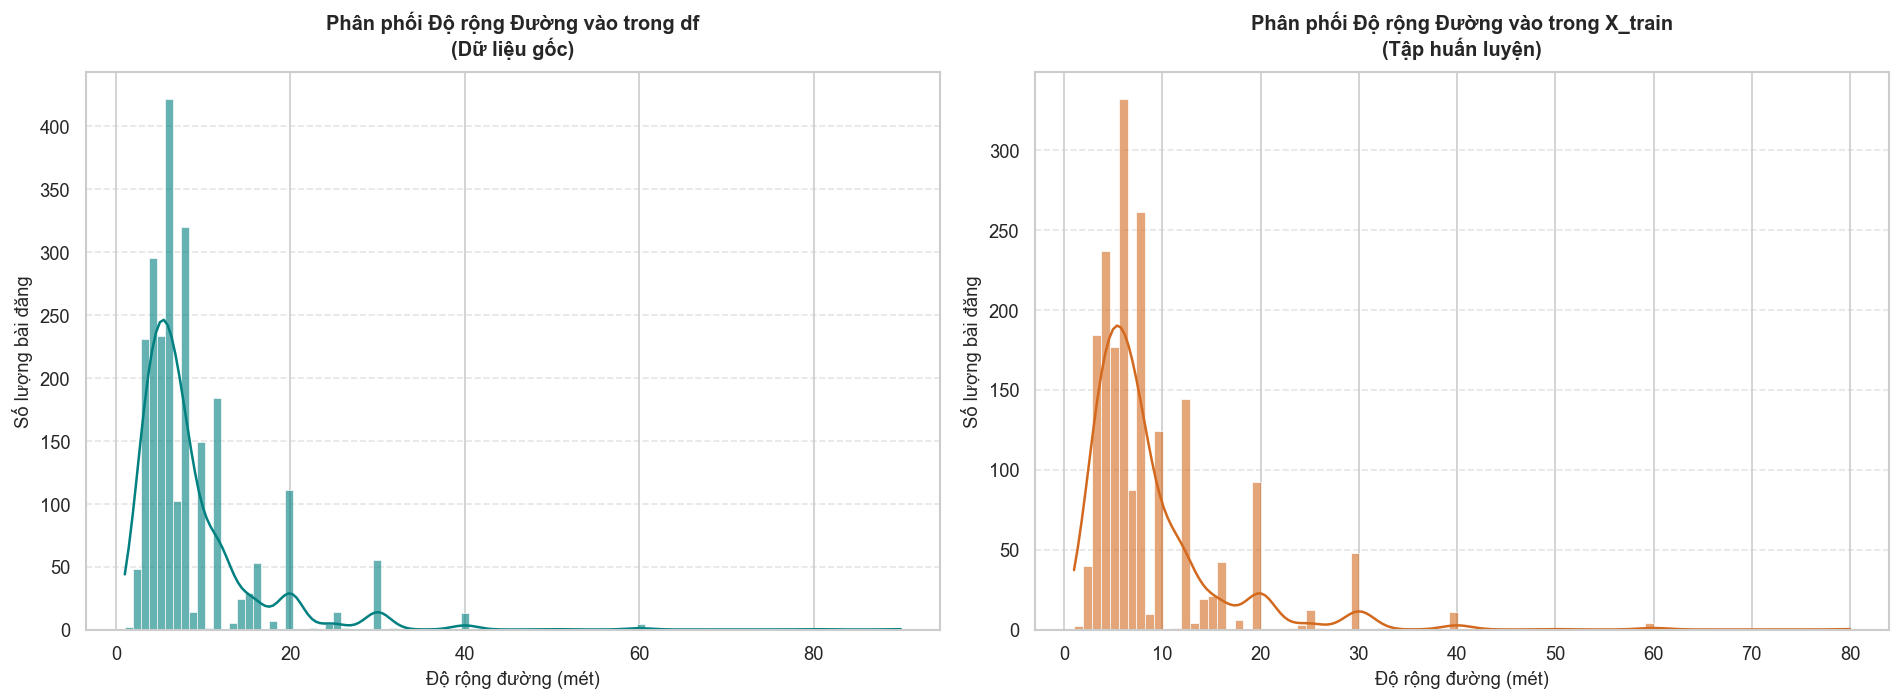

In [ ]:
# 1. Làm sạch dữ liệu NaN cho cột 'Đường vào'
duong_vao_df = df['Đường vào'].dropna()
duong_vao_train = X_train['Đường vào'].dropna()

# 2. Khởi tạo khung nền gồm 2 biểu đồ nằm song song
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: PHÂN PHỐI ĐƯỜNG VÀO TRÊN DF GỐC ---
sns.histplot(
    duong_vao_df, 
    kde=True, 
    color='teal', 
    edgecolor='white',
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Phân phối Độ rộng Đường vào trong df\n(Dữ liệu gốc)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Độ rộng đường (mét)', fontsize=11)
axes[0].set_ylabel('Số lượng bài đăng', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


# --- BIỂU ĐỒ 2: PHÂN PHỐI ĐƯỜNG VÀO TRÊN TẬP X_TRAIN ---
sns.histplot(
    duong_vao_train, 
    kde=True, 
    color='chocolate', 
    edgecolor='white',
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Phân phối Độ rộng Đường vào trong X_train\n(Tập huấn luyện)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Độ rộng đường (mét)', fontsize=11)
axes[1].set_ylabel('Số lượng bài đăng', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu khoảng cách và hiển thị
plt.tight_layout()
plt.show()

In [ ]:
# ── Kiểm tra outlier Đường vào trên tập train (sau split) ──
outliers_duong_vao = X_train[X_train['Đường vào'] > 50]

print(f"📊 Tìm thấy {len(outliers_duong_vao)} bản ghi có Đường vào > 50m trong X_train")

if not outliers_duong_vao.empty:
    cols_to_display = [c for c in ['Đường vào', 'Diện tích', 'Số tầng'] if c in X_train.columns]
    display(outliers_duong_vao[cols_to_display].sort_values(by='Đường vào', ascending=False))


📊 Tìm thấy 5 bản ghi có Đường vào > 50m trong X_train


,Đường vào,Diện tích,Số tầng
2574,80.0,161.0,2
464,60.0,70.0,3
3244,60.0,20.0,3
2118,60.0,47.0,4
3272,60.0,95.0,4


Các Outlier này là vô lý: Tại đô thị lớn như TP.HCM, đường phố rộng nhất (như đại lộ Võ Văn Kiệt, Nguyễn Văn Linh) cũng chỉ khoảng 40m - 60m.
Các outlier này là hậu quả cảu:
- lỗi khi crawldata
- Lỗi khi nhập liệu
- Xoá

In [ ]:
# ── FIX: Xóa outlier Đường vào trực tiếp trên X_train / X_test ──────────────
# Lý do: split đã thực hiện ở cell 61; thao tác trên df sau split là thừa
# và gây không nhất quán index giữa df, X_train, X_test.

DUONG_VAO_MAX = 50  # mét – ngưỡng bất thường

outlier_tr = X_train[X_train['Đường vào'] > DUONG_VAO_MAX].index
outlier_te = X_test[X_test['Đường vào']  > DUONG_VAO_MAX].index
total_found = len(outlier_tr) + len(outlier_te)

if total_found > 0:
    print(f"📍 Tìm thấy {len(outlier_tr)} outlier trong train, {len(outlier_te)} trong test.")

    X_train = X_train.drop(index=outlier_tr)
    y_train = y_train.drop(index=outlier_tr)
    X_test  = X_test.drop(index=outlier_te)
    y_test  = y_test.drop(index=outlier_te)

    print("✅ Đã xóa thành công!")
    print(f"-> X_train: {X_train.shape}  |  X_test: {X_test.shape}")
else:
    print("✅ Không tìm thấy outlier Đường vào > 50m.")

📍 Tìm thấy 5 outlier trong train, 1 trong test.
✅ Đã xóa thành công!
-> X_train: (2809, 16)  |  X_test: (703, 16)


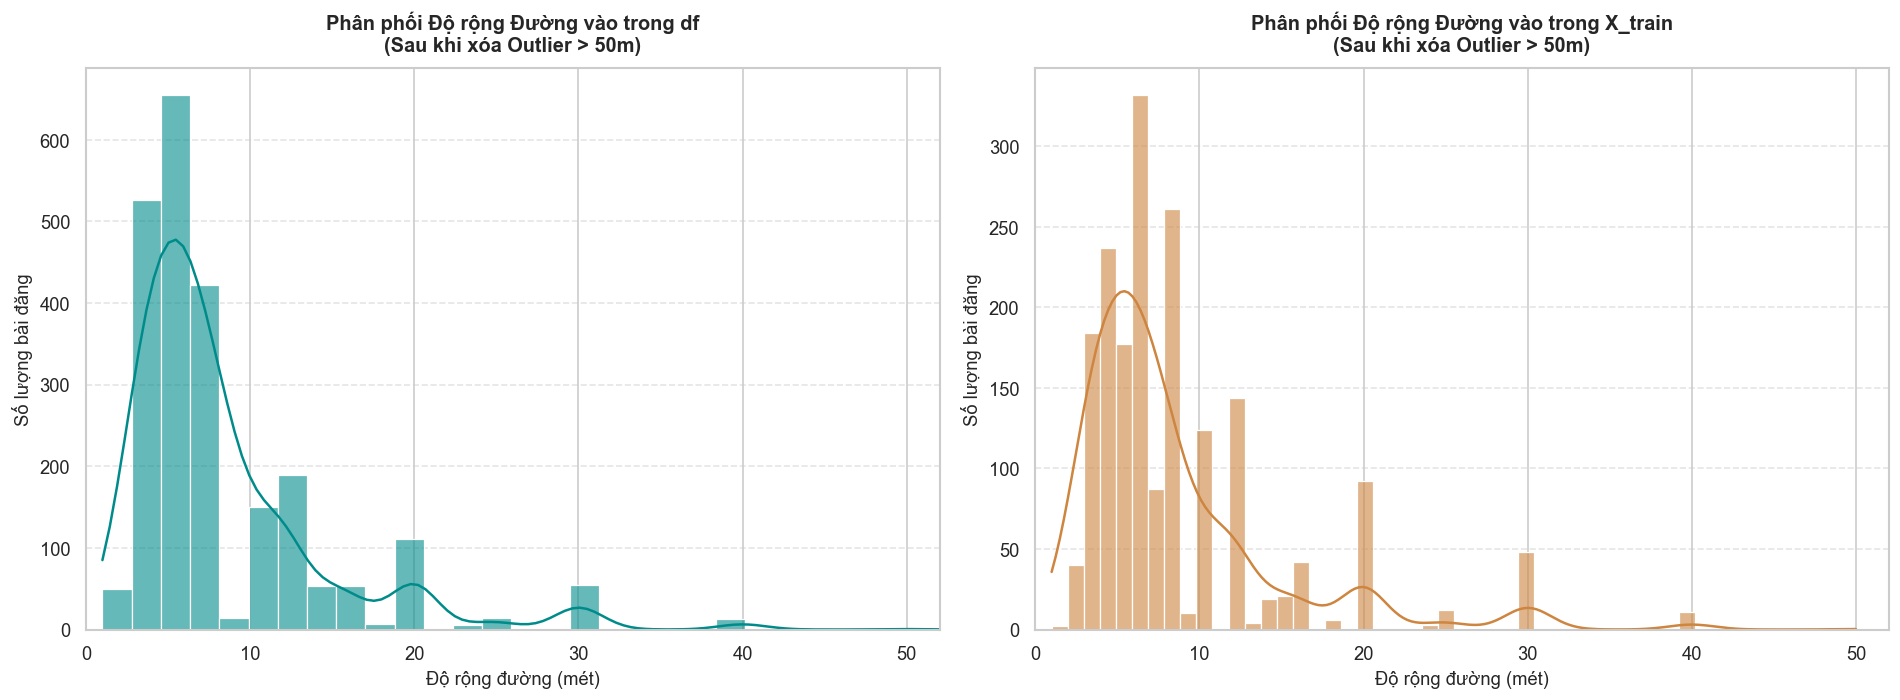

In [ ]:
# 1. Làm sạch tạm thời các giá trị NaN để tránh lỗi khi vẽ đường KDE
clean_df_dv = df['Đường vào'].dropna()
clean_train_dv = X_train['Đường vào'].dropna()

# 2. Khởi tạo khung nền gồm 2 biểu đồ nằm song song (16x6)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: TẬP DF GỐC SAU KHI SẠCH OUTLIER ---
sns.histplot(
    clean_df_dv, 
    bins=50,              # Chia dữ liệu thành 25 cột để nhìn rõ mật độ
    kde=True, 
    color='darkcyan', 
    edgecolor='white', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('Phân phối Độ rộng Đường vào trong df\n(Sau khi xóa Outlier > 50m)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Độ rộng đường (mét)', fontsize=11)
axes[0].set_ylabel('Số lượng bài đăng', fontsize=11)
axes[0].set_xlim(0, 52)   # Giới hạn trục X sát mức 50m để biểu đồ không bị loãng
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


# --- BIỂU ĐỒ 2: TẬP X_TRAIN SAU KHI SẠCH OUTLIER ---
sns.histplot(
    clean_train_dv, 
    bins=50, 
    kde=True, 
    color='peru', 
    edgecolor='white', 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Phân phối Độ rộng Đường vào trong X_train\n(Sau khi xóa Outlier > 50m)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Độ rộng đường (mét)', fontsize=11)
axes[1].set_ylabel('Số lượng bài đăng', fontsize=11)
axes[1].set_xlim(0, 52)   # Giới hạn trục X đồng bộ với biểu đồ bên trái
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu khoảng cách hiển thị giữa các đồ thị
plt.tight_layout()
plt.show()

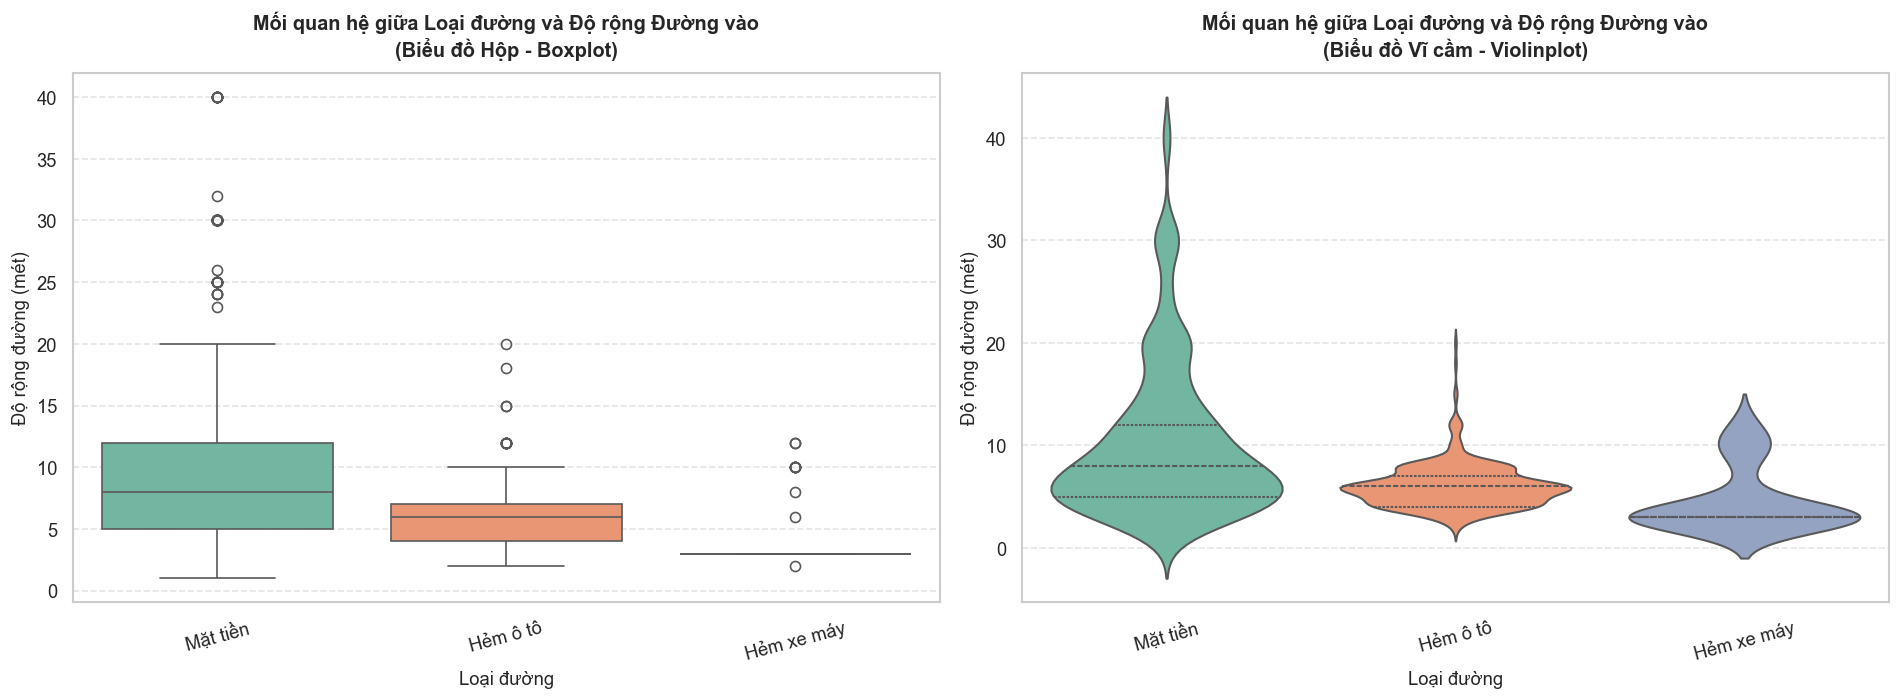

In [ ]:
# 1. Lọc bỏ các hàng bị khuyết thiếu (NaN) ở cả 2 cột để biểu đồ vẽ chuẩn xác hơn
plot_data = X_train[['Loại đường vào', 'Đường vào']].dropna()

# 2. Khởi tạo khung nền gồm 2 biểu đồ nằm song song
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: BOXPLOT (Nhìn rõ Trung vị và các khoảng Tứ phân vị) ---
sns.boxplot(
    data=plot_data,
    x='Loại đường vào',
    y='Đường vào',
    hue='Loại đường vào',
    palette='Set2',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Mối quan hệ giữa Loại đường và Độ rộng Đường vào\n(Biểu đồ Hộp - Boxplot)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Loại đường', fontsize=11)
axes[0].set_ylabel('Độ rộng đường (mét)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Xoay nhãn trục X nếu tên các loại đường quá dài, tránh bị dính chữ
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)


# --- BIỂU ĐỒ 2: VIOLINPLOT (Nhìn rõ hình dáng phân phối mật độ dữ liệu) ---
sns.violinplot(
    data=plot_data,
    x='Loại đường vào',
    y='Đường vào',
    hue='Loại đường vào',
    palette='Set2',
    legend=False,
    inner='quartile',
    ax=axes[1]
)
axes[1].set_title('Mối quan hệ giữa Loại đường và Độ rộng Đường vào\n(Biểu đồ Vĩ cầm - Violinplot)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Loại đường', fontsize=11)
axes[1].set_ylabel('Độ rộng đường (mét)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

# Tối ưu khoảng cách hiển thị giữa các đồ thị
plt.tight_layout()
plt.show()

🔍 ĐANG PHÂN TÍCH HÀNH VI GIẤU THÔNG TIN THEO KHOẢNG GIÁ LIÊN TỤC...



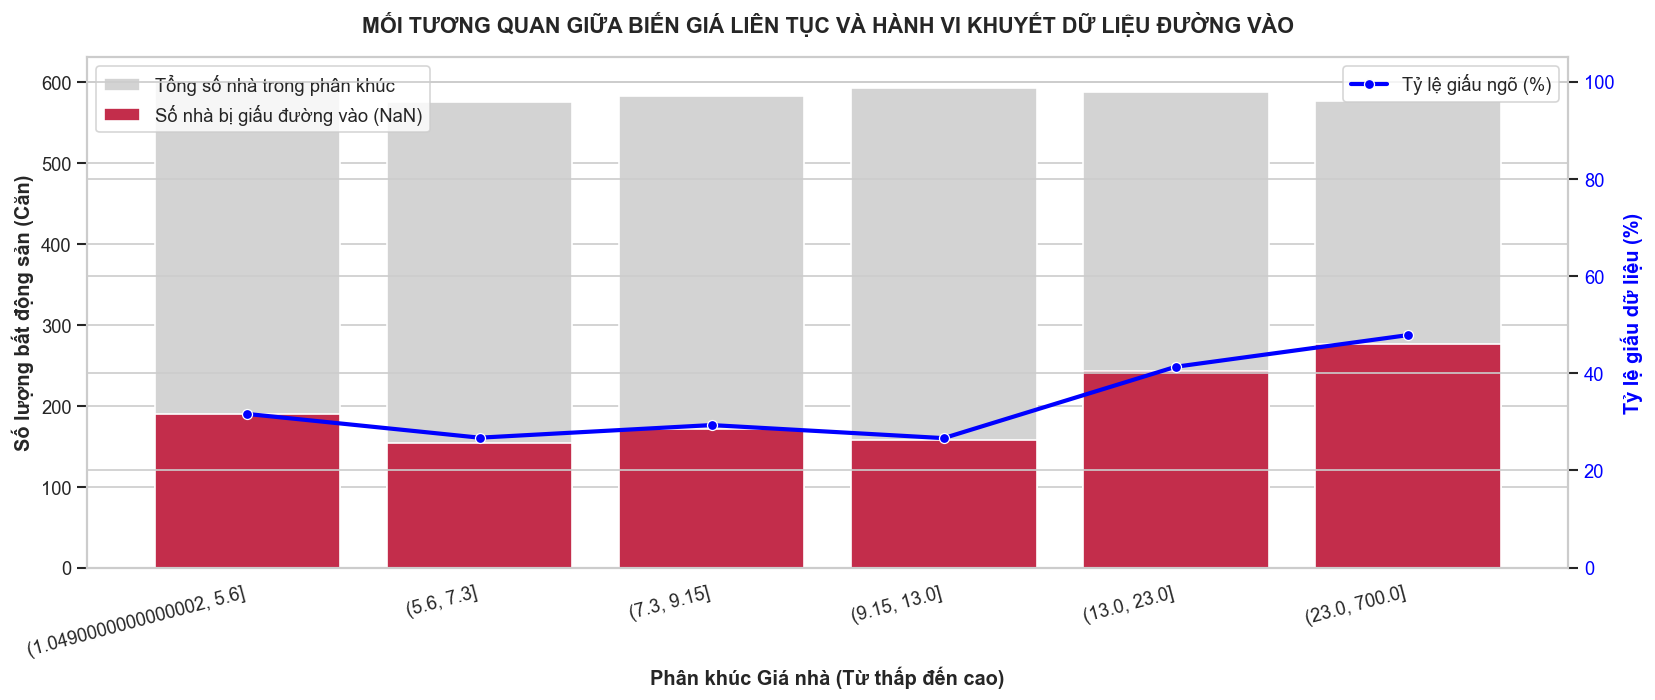

,Phân khúc giá,Tổng_số_nhà,Số_nhà_giấu_ngõ,Tỷ_lệ_giấu_%
0,"(1.0490000000000002, 5.6]",601,190,31.613977
1,"(5.6, 7.3]",576,154,26.736111
2,"(7.3, 9.15]",583,171,29.331046
3,"(9.15, 13.0]",593,158,26.644182
4,"(13.0, 23.0]",588,243,41.326531
5,"(23.0, 700.0]",577,276,47.833622


✅ Đầu vào OK — X_train: 2,809 dòng
   Null Đường vào ban đầu     : 948
   Null Loại đường vào ban đầu: 1,026

🚀 Bước 1 — Tạo Flag MNAR thành công:
   [Train] Số lượng dòng giấu thông tin ngõ: 948

📝 Bước 2 — Xử lý nhãn Loại đường vào:
Loại đường vào
Mặt tiền         1233
Chưa xác định    1026
Hẻm ô tô          511
Hẻm xe máy         39
Name: count, dtype: int64

💎 Bước 3 — Thực thi Native Missing Handling:
   -> Đã giữ nguyên 948 dòng NaN trong X_train
   -> Đã giữ nguyên 244 dòng NaN trong X_test
✅ KẾT QUẢ: Phương sai (Variance) thực tế được bảo toàn 100%, loại bỏ hoàn toàn đỉnh ảo!


In [ ]:
print("🔍 ĐANG PHÂN TÍCH HÀNH VI GIẤU THÔNG TIN THEO KHOẢNG GIÁ LIÊN TỤC...\n")

# 1. Tạo một bản sao để xử lý đồ thị (giả sử dữ liệu gốc của bạn là df)
df_plot = df.copy()

# Tự động chia khoảng giá liên tục thành 6 phân khúc có số lượng mẫu bằng nhau (Quantiles)
# Điều này giúp loại bỏ hiện tượng lệch mẫu giữa các phân khúc
df_plot['Phân khúc giá'] = pd.qcut(df_plot['Khoảng giá'], q=6, duplicates='drop')

# 2. Tính toán thống kê theo từng phân khúc giá vừa chia
# Sử dụng observed=False để tối ưu cho biến Categorical trong Pandas
missing_stats = df_plot.groupby('Phân khúc giá', observed=False)['Đường vào'].agg(
    Tổng_số_nhà='size',
    Số_nhà_giấu_ngõ=lambda x: x.isna().sum()
).reset_index()

# Tính tỷ lệ phần trăm bị khuyết dữ liệu
missing_stats['Tỷ_lệ_giấu_%'] = (missing_stats['Số_nhà_giấu_ngõ'] / missing_stats['Tổng_số_nhà']) * 100

# Vì 'Phân khúc giá' là dạng Categorical nên Pandas đã tự sắp xếp thứ tự từ thấp đến cao chuẩn xác

# 3. Tiến hành vẽ biểu đồ hai trục (Dual Axis)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục 1 (Cột): Thể hiện số lượng nhà
sns.barplot(data=missing_stats, x='Phân khúc giá', y='Tổng_số_nhà', color='lightgrey', ax=ax1, label='Tổng số nhà trong phân khúc')
sns.barplot(data=missing_stats, x='Phân khúc giá', y='Số_nhà_giấu_ngõ', color='crimson', ax=ax1, label='Số nhà bị giấu đường vào (NaN)')

ax1.set_ylabel('Số lượng bất động sản (Căn)', fontweight='bold')
ax1.set_xlabel('Phân khúc Giá nhà (Từ thấp đến cao)', fontweight='bold')
ax1.set_xticklabels(missing_stats['Phân khúc giá'].astype(str), rotation=15, ha='right')
ax1.legend(loc='upper left')

# Trục 2 (Đường): Thể hiện xu hướng tỷ lệ (%) khuyết dòng
ax2 = ax1.twinx()
sns.lineplot(data=missing_stats, x=np.arange(len(missing_stats)), y='Tỷ_lệ_giấu_%', color='blue', marker='o', linewidth=2.5, ax=ax2, label='Tỷ lệ giấu ngõ (%)')
ax2.set_ylabel('Tỷ lệ giấu dữ liệu (%)', color='blue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 105)
ax2.legend(loc='upper right')

plt.title('MỐI TƯƠNG QUAN GIỮA BIẾN GIÁ LIÊN TỤC VÀ HÀNH VI KHUYẾT DỮ LIỆU ĐƯỜNG VÀO', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu chi tiết phía dưới
display(missing_stats)
# =========================================================================
# CELL 1: PIPELINE NATIVE MISSING HANDLING (PHƯƠNG PHÁP 1 - TỐI ƯU CHO MÔ HÌNH CÂY)
# Thay thế hoàn toàn cell Median/MICE cũ
# Chạy SAU khi đã có X_train, X_test, y_train, y_test
# =========================================================================

# ── KIỂM TRA ĐẦU VÀO ────────────────────────────────────────────
assert 'Đường vào' in X_train.columns, "❌ Thiếu cột Đường vào"
assert 'Loại đường vào' in X_train.columns, "❌ Thiếu cột Loại đường vào"
print(f"✅ Đầu vào OK — X_train: {len(X_train):,} dòng")
print(f"   Null Đường vào ban đầu     : {X_train['Đường vào'].isna().sum():,}")
print(f"   Null Loại đường vào ban đầu: {X_train['Loại đường vào'].isna().sum():,}")

# ── SNAPSHOT TRƯỚC XỬ LÝ ────────────────────────────────────────
X_train_backup = X_train.copy()

# ── BƯỚC 1: TẠO FLAG MNAR (TÍN HIỆU ĐẶT NHÁNH CHO XGBOOST/LIGHTGBM) ──
# Giữ nguyên tư duy xuất sắc của bạn: Ép hành vi giấu số liệu thành 1 tính năng dự đoán
for dataset in [X_train, X_test]:
    dataset['loai_duong_null_flag'] = dataset['Loại đường vào'].isna().astype(int)
    dataset['duong_vao_null_flag']  = dataset['Đường vào'].isna().astype(int)

print(f"\n🚀 Bước 1 — Tạo Flag MNAR thành công:")
print(f"   [Train] Số lượng dòng giấu thông tin ngõ: {X_train['duong_vao_null_flag'].sum():,}")

# ── BƯỚC 2: XỬ LÝ BIẾN PHÂN LOẠI (CATEGORICAL) ──────────────────
# Điền nhãn 'Chưa xác định' để các bộ mã hóa (One-Hot / Target Encoding) không bị lỗi
for dataset in [X_train, X_test]:
    dataset['Loại đường vào'] = dataset['Loại đường vào'].fillna('Chưa xác định')

print(f"\n📝 Bước 2 — Xử lý nhãn Loại đường vào:")
print(X_train['Loại đường vào'].value_counts())

# ── BƯỚC 3: NATIVE HANDLING CHO BIẾN SỐ (ĐƯỜNG VÀO) ─────────────
# PHÁN QUYẾT: TUYỆT ĐỐI KHÔNG điền khuyết toán học (MICE/Median) vào đây.
# Giữ nguyên bản chất np.nan để XGBoost/LightGBM kích hoạt thuật toán tự rẽ nhánh tối ưu.
print(f"\n💎 Bước 3 — Thực thi Native Missing Handling:")
print(f"   -> Đã giữ nguyên {X_train['Đường vào'].isna().sum():,} dòng NaN trong X_train")
print(f"   -> Đã giữ nguyên {X_test['Đường vào'].isna().sum():,} dòng NaN trong X_test")
print(f"✅ KẾT QUẢ: Phương sai (Variance) thực tế được bảo toàn 100%, loại bỏ hoàn toàn đỉnh ảo!")



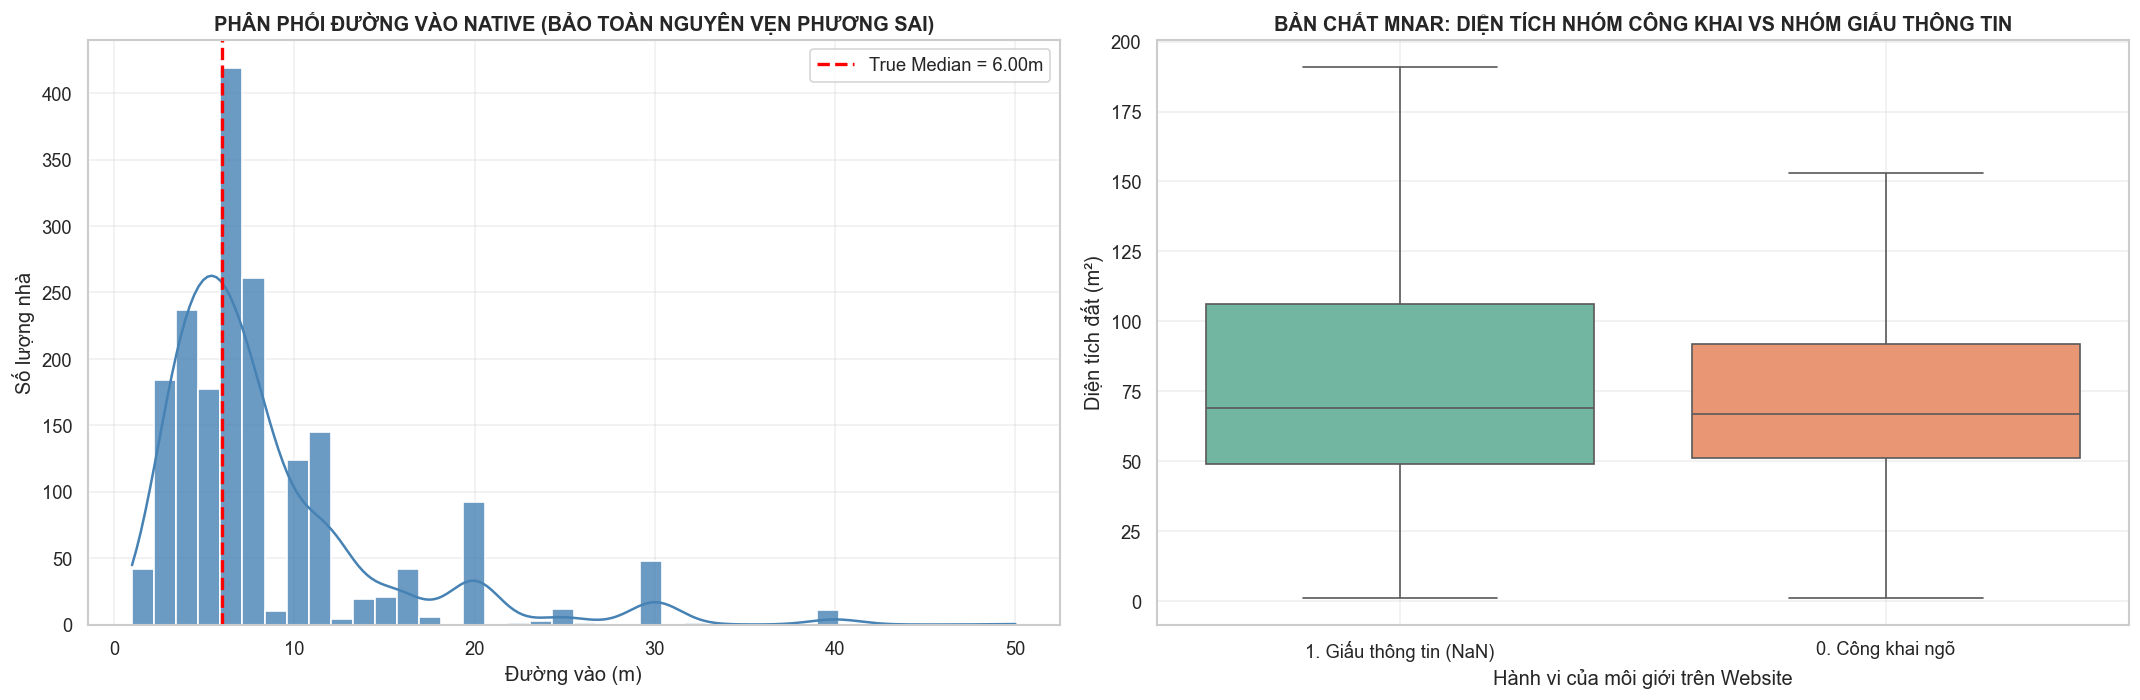

In [ ]:
# =========================================================================
# VISUALIZE: KIỂM ĐỊNH TÍNH CHẤT PHÂN PHỐI VÀ BẢN CHẤT CỦA KHUYẾT DỮ LIỆU
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Phân phối thực tế được bảo toàn nguyên vẹn (Không còn cú Spike đột biến)
sns.histplot(
    data=X_train['Đường vào'].dropna(),
    bins=40,
    kde=True,
    color='steelblue',
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)
global_median = X_train['Đường vào'].median()
axes[0].axvline(global_median, color='red', linestyle='--', linewidth=2, label=f'True Median = {global_median:.2f}m')
axes[0].set_title('PHÂN PHỐI ĐƯỜNG VÀO NATIVE (BẢO TOÀN NGUYÊN VẸN PHƯƠNG SAI)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Đường vào (m)')
axes[0].set_ylabel('Số lượng nhà')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Biểu đồ 2: Chứng minh hành vi MNAR qua mối tương quan với "Tầm cỡ diện tích" của BĐS
# Tạo cột tạm thời phục vụ vẽ đồ thị an toàn, tránh warning của matplotlib
df_plot = X_train.copy()
df_plot['Trạng thái dữ liệu'] = df_plot['duong_vao_null_flag'].map({0: '0. Công khai ngõ', 1: '1. Giấu thông tin (NaN)'})

sns.boxplot(
    data=df_plot,
    x='Trạng thái dữ liệu',
    y='Diện tích',
    palette='Set2',
    ax=axes[1],
    showfliers=False  # Ẩn các điểm cực đoan quá lớn để nhìn rõ hộp phân phối chính
)
axes[1].set_title('BẢN CHẤT MNAR: DIỆN TÍCH NHÓM CÔNG KHAI VS NHÓM GIẤU THÔNG TIN', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hành vi của môi giới trên Website')
axes[1].set_ylabel('Diện tích đất (m²)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Save File lại phục vụ cho EDA sau tiền xử lí

## Kiểm tra nghiệm thu cuối pipeline

Cell này in bảng tổng kết số null còn lại trên toàn bộ `X_train` và `X_test` sau tất cả các bước làm sạch. Mọi cột có null cần được xem xét trước khi lưu.

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# KIỂM TRA NGHIỆM THU: TỔNG KẾT TRẠNG THÁI NULL SAU TOÀN BỘ PIPELINE
# ────────────────────────────────────────────────────────────────────────────
def null_summary(name, df_):
    s = df_.isnull().sum()
    s = s[s > 0]
    if s.empty:
        print(f"✅ {name}: Không còn null nào!")
    else:
        pct = (s / len(df_) * 100).round(2)
        tbl = pd.DataFrame({'Null Count': s, 'Null %': pct})
        print(f"\n⚠️  {name} – còn {len(s)} cột có null:")
        print(tbl.to_string())

print("=" * 55)
print("TỔNG KẾT TRẠNG THÁI MISSING SAU PIPELINE CLEANING")
print("=" * 55)
null_summary("X_train", X_train)
null_summary("X_test",  X_test)
print("\n" + "=" * 55)
print(f"Kích thước cuối: X_train={X_train.shape}  X_test={X_test.shape}")
print("=" * 55)

TỔNG KẾT TRẠNG THÁI MISSING SAU PIPELINE CLEANING

⚠️  X_train – còn 2 cột có null:
           Null Count  Null %
Đường vào         948   33.75
Đường             149    5.30

⚠️  X_test – còn 2 cột có null:
           Null Count  Null %
Đường vào         244   34.71
Đường              37    5.26

Kích thước cuối: X_train=(2809, 18)  X_test=(703, 18)


In [ ]:
# =========================================================================
# BƯỚC 3: LƯU CÁC TẬP DỮ LIỆU ĐÃ XỬ LÝ RA FILE CSV
# =========================================================================

output_dir = Path.cwd().parent.parent / "data" / "Processed" / "Cleaned_data"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"⏳ Đang tiến hành lưu các tập dữ liệu vào: {output_dir} ...")

datasets = {
    'X_train_cleaned.csv': X_train,
    'y_train_cleaned.csv': y_train,
    'X_test_cleaned.csv': X_test,
    'y_test_cleaned.csv': y_test
}

for file_name, data in datasets.items():
    try:
        if isinstance(data, pd.Series):
            data_to_save = data.to_frame()
        else:
            data_to_save = data

        full_path = output_dir / file_name
        data_to_save.to_csv(full_path, index=True)
        print(f"✅ Đã lưu: {file_name:<23} | Kích thước: {data_to_save.shape}")
    except Exception as e:
        print(f"❌ Gặp lỗi khi lưu file {file_name}: {e}")

print(f"\n🎉 Hoàn tất! Tất cả các file đã được lưu tại: {output_dir}")

⏳ Đang tiến hành lưu các tập dữ liệu vào: c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Processed\Cleaned_data ...
✅ Đã lưu: X_train_cleaned.csv     | Kích thước: (2809, 18)
✅ Đã lưu: y_train_cleaned.csv     | Kích thước: (2809, 1)
✅ Đã lưu: X_test_cleaned.csv      | Kích thước: (703, 18)
✅ Đã lưu: y_test_cleaned.csv      | Kích thước: (703, 1)

🎉 Hoàn tất! Tất cả các file đã được lưu tại: c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Processed\Cleaned_data


In [ ]:
if isinstance(y_train, pd.Series): y_train = y_train.to_frame()
if isinstance(y_test, pd.Series): y_test = y_test.to_frame()

# =========================================================================
# BƯỚC 1: GHÉP X VÀ Y, ĐỒNG THỜI GẮN NHÃN ĐỂ CHỐNG "HUMAN LEAKAGE"
# =========================================================================

train_full = pd.concat([X_train, y_train], axis=1)
train_full['Loại_Dữ_Liệu'] = 'Train'

test_full = pd.concat([X_test, y_test], axis=1)
test_full['Loại_Dữ_Liệu'] = 'Test'

# =========================================================================
# BƯỚC 2: GỘP THÀNH 1 DATASET DUY NHẤT CHO EDA
# =========================================================================

df_eda_master = pd.concat([train_full, test_full], axis=0).reset_index(drop=True)

# =========================================================================
# BƯỚC 3: LƯU FILE VỚI TÊN GỌI CẢNH BÁO RÕ RÀNG
# =========================================================================

output_dir = Path.cwd().parent.parent / "data" / "Processed" / "Cleaned_data"
output_dir.mkdir(parents=True, exist_ok=True)

eda_file_name = "Cleaned_data.csv"
eda_full_path = output_dir / eda_file_name

df_eda_master.to_csv(eda_full_path, index=False)

print(f"✅ Đã tạo thành công file chuyên dụng cho EDA: {eda_file_name}")
print(f"📊 Kích thước tổng: {df_eda_master.shape}")

✅ Đã tạo thành công file chuyên dụng cho EDA: Cleaned_data.csv
📊 Kích thước tổng: (3512, 20)
